# INSTALLING AND CONNECTING

In [ ]:
# Connect to Your Drive (You can donwload the content from https://mir.dei.uc.pt/downloads.html or from Kaggle: https://www.kaggle.com/datasets/imsparsh/4q-audio-emotion-dataset-russell  )
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Installing libs
!apt-get update -qq
!apt-get install -y libav-tools
!pip install essentia
!pip install matplotlib

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Package libav-tools is not available, but is referred to by another package.
This may mean that the package is missing, has been obsoleted, or
is only available from another source

E: Package 'libav-tools' has no installation candidate
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 88.6 MB/s eta 0:00:00


# DATABASE     4Q Emotional



In [ ]:
from zipfile import ZipFile
import os
import pandas as pd

# 4Q audio emotion dataset (Russell's model) (2018)
# Specify the path to your zip file
zip_file_path = "/content/drive/MyDrive/Semantic Music Generation/MER_audio_taffc_dataset.zip"

# Specify the directory where you want to extract the contents
extracted_folder_path = "/content"

# Create a ZipFile object
with ZipFile(zip_file_path, 'r') as zip_ref:
    # Extract all the contents of zip file in the specified directory
    zip_ref.extractall(extracted_folder_path)

# List the files in the extracted folder
extracted_files = os.listdir(extracted_folder_path)

# Specify the path to the CSV file
annotations_file_path = "/content/panda_dataset_taffc_annotations.csv"
# Read the CSV file into a pandas DataFrame
annotations_df = pd.read_csv(annotations_file_path)

# Specify the path to the CSV file
metadata_file_path = "/content/panda_dataset_taffc_metadata.csv"
# Read the CSV file into a pandas DataFrame
metadata_df = pd.read_csv(metadata_file_path)

# Specify the root directory
root_directory = "/content"

# List of quadrants
quadrants = ["Q1", "Q2", "Q3", "Q4"]

# Dictionary to store audio files for each quadrant
audio_files_by_quadrant = {}

# Iterate over each quadrant
for quadrant in quadrants:
    # Specify the directory for the current quadrant
    quadrant_directory = os.path.join(root_directory, quadrant)

    # List all files in the quadrant directory
    files_in_quadrant = os.listdir(quadrant_directory)

    # Filter only audio files (assuming they have a .mp3 extension)
    audio_files = [file for file in files_in_quadrant if file.endswith(".mp3")]

    # Store the list of audio files in the dictionary
    audio_files_by_quadrant[quadrant] = audio_files

# Keep only the specified columns
selected_columns = ["Song", "Quadrant", "MoodsStr", "GenresStr"]
metadata_df = metadata_df[selected_columns]

# Display the first few rows of the DataFrame
metadata_df.head(5)



,Song,Quadrant,MoodsStr,GenresStr
0,MT0000004637,Q3,Circular; Greasy; Messy,Country; International
1,MT0000011357,Q2,Negative; Nervous/Jittery,Electronic; International; Pop/Rock
2,MT0000011975,Q2,Fierce; Harsh; Hostile; Menacing; Outrageous; ...,Electronic
3,MT0000040632,Q1,Cathartic; Fiery; Sexy; Spicy,International; Jazz
4,MT0000044741,Q3,Greasy; Gritty; Gutsy; Lazy,Blues


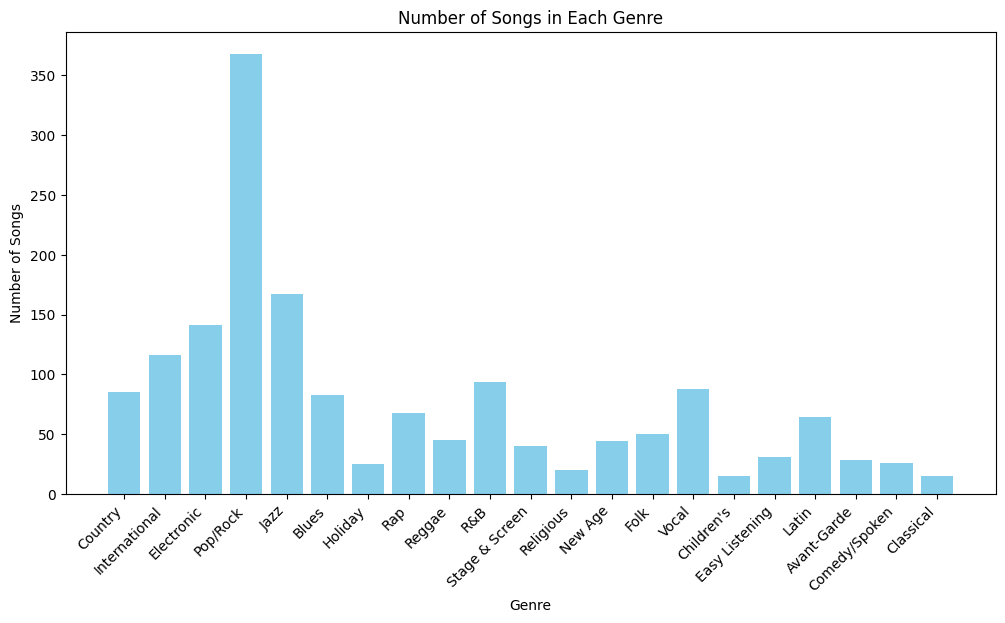

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter

# Split the GenresStr column into a list of genres
metadata_df['GenresList'] = metadata_df['GenresStr'].str.split(';')

# Flatten the list of genres and clean up genre names
all_genres = [genre.strip() for genres_list in metadata_df['GenresList'] for genre in genres_list]

# Count the frequency of each genre
genre_counts = Counter(all_genres)

# Plot the number of genres
plt.figure(figsize=(12, 6))
plt.bar(genre_counts.keys(), genre_counts.values(), color='skyblue')
plt.title('Number of Songs in Each Genre')
plt.xlabel('Genre')
plt.ylabel('Number of Songs')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better visibility
plt.show()

In [ ]:
# Filter conditions for each quadrant with Rock/Pop genre
q1_happy_rockpop = metadata_df[
    (metadata_df['Quadrant'] == 'Q1') &
    (metadata_df['MoodsStr'].str.contains('Happy', case=False, na=False)) &
    (metadata_df['GenresStr'].str.contains('Rock|Pop', case=False, na=False))
]

q2_angry_rockpop = metadata_df[
    (metadata_df['Quadrant'] == 'Q2') &
    (metadata_df['MoodsStr'].str.contains('Angry', case=False, na=False)) &
    (metadata_df['GenresStr'].str.contains('Rock|Pop', case=False, na=False))
]

q3_sad_rockpop = metadata_df[
    (metadata_df['Quadrant'] == 'Q3') &
    (metadata_df['MoodsStr'].str.contains('Sad', case=False, na=False)) &
    (metadata_df['GenresStr'].str.contains('Rock|Pop', case=False, na=False))
]

q4_tender_rockpop = metadata_df[
    (metadata_df['Quadrant'] == 'Q4') &
    (metadata_df['MoodsStr'].str.contains('Gentle', case=False, na=False)) &
    (metadata_df['GenresStr'].str.contains('Rock|Pop', case=False, na=False))
]

# Display the results
print("Q1 - Happy Rock/Pop songs:")
print(f"Count: {len(q1_happy_rockpop)}")
print(q1_happy_rockpop.head())

print("\nQ2 - Angry Rock/Pop songs:")
print(f"Count: {len(q2_angry_rockpop)}")
print(q2_angry_rockpop.head())

print("\nQ3 - Sad Rock/Pop songs:")
print(f"Count: {len(q3_sad_rockpop)}")
print(q3_sad_rockpop.head())

print("\nQ4 - Tender Rock/Pop songs:")
print(f"Count: {len(q4_tender_rockpop)}")
print(q4_tender_rockpop.head())

Q1 - Happy Rock/Pop songs:
Count: 21
             Song Quadrant                                           MoodsStr  \
6    MT0000082187       Q1  Cheerful; Fun; Happy; Joyous; Light; Playful; ...   
62   MT0000992846       Q1  Amiable/Good-Natured; Cheerful; Energetic; Fun...   
165  MT0002698706       Q1                           Brooding; Happy; Rousing   
229  MT0003788939       Q1            Celebratory; Happy; Intense; Theatrical   
330  MT0005523766       Q1   Celebratory; Happy; Humorous; Joyous; Rollicking   

                GenresStr                GenresList  
6       Holiday; Pop/Rock      [Holiday,  Pop/Rock]  
62               Pop/Rock                [Pop/Rock]  
165       Vocal; Pop/Rock        [Vocal,  Pop/Rock]  
229  Electronic; Pop/Rock   [Electronic,  Pop/Rock]  
330  Pop/Rock; Blues; R&B  [Pop/Rock,  Blues,  R&B]  

Q2 - Angry Rock/Pop songs:
Count: 58
             Song Quadrant                                           MoodsStr  \
9    MT0000133200       Q2  Angry

In [ ]:
# Function to get audio files for filtered songs
def get_audio_files_for_filtered_songs(filtered_df, audio_files_by_quadrant):
    audio_files = []
    for _, row in filtered_df.iterrows():
        song_id = row['Song']
        quadrant = row['Quadrant']

        # Look for matching audio file in the quadrant directory
        quadrant_audio_files = audio_files_by_quadrant.get(quadrant, [])
        matching_files = [f for f in quadrant_audio_files if song_id in f]

        if matching_files:
            audio_files.extend(matching_files)

    return audio_files

# Get audio files for each filtered category
q1_audio_files = get_audio_files_for_filtered_songs(q1_happy_rockpop, audio_files_by_quadrant)
q2_audio_files = get_audio_files_for_filtered_songs(q2_angry_rockpop, audio_files_by_quadrant)
q3_audio_files = get_audio_files_for_filtered_songs(q3_sad_rockpop, audio_files_by_quadrant)
q4_audio_files = get_audio_files_for_filtered_songs(q4_tender_rockpop, audio_files_by_quadrant)

print(f"Q1 Happy Rock/Pop audio files: {len(q1_audio_files)}")
print(f"Q2 Angry Rock/Pop audio files: {len(q2_audio_files)}")
print(f"Q3 Sad Rock/Pop audio files: {len(q3_audio_files)}")
print(f"Q4 Tender Rock/Pop audio files: {len(q4_audio_files)}")

Q1 Happy Rock/Pop audio files: 21
Q2 Angry Rock/Pop audio files: 58
Q3 Sad Rock/Pop audio files: 20
Q4 Tender Rock/Pop audio files: 22


# FEATURES EXTRACTION

(This process will take time, so I recommend doing it only once and saving the files in .csv format with the extracted features for later analysis.)

In [ ]:
import os
import essentia.standard as es
import pandas as pd
import numpy as np

# First, let's create a combined dataframe of all our filtered Rock/Pop songs
filtered_rockpop_combined = pd.concat([
    q1_happy_rockpop,
    q2_angry_rockpop,
    q3_sad_rockpop,
    q4_tender_rockpop
], ignore_index=True)

# Get the list of selected song IDs from our filtered data
selected_files = filtered_rockpop_combined['Song'].tolist()

print(f"Total selected songs: {len(selected_files)}")

# Specify the directories containing the audio files (based on your quadrant structure)
directories = ['/content/Q1', '/content/Q2', '/content/Q3', '/content/Q4']

# Lists to store the results
file_names = []
features_list = []  # List to store extracted features
mood = []  # List to store the quadrant information
song_ids = []  # List to store song IDs

# Counter for tracking
processed_count = 0
error_count = 0

# Iterate through each directory
for directory in directories:
    print(f"Processing directory: {directory}")

    # Get quadrant from directory name
    current_quadrant = os.path.basename(directory)

    # Iterate through each file in the directory
    for filename in os.listdir(directory):
        if filename.lower().endswith((".wav", ".mp3")):
            # Extract song ID from the filename (remove extension)
            song_id = os.path.splitext(filename)[0]

            # Check if the song is in the selected_files list
            if song_id in selected_files:
                try:
                    # Form the complete file path
                    audio_file_path = os.path.join(directory, filename)

                    print(f"Processing: {filename}")

                    # Extract the features using MusicExtractor
                    features, _ = es.MusicExtractor(
                        lowlevelStats=['mean', 'stdev'],
                        rhythmStats=['mean', 'stdev'],
                        tonalStats=['mean', 'stdev']
                    )(audio_file_path)

                    # Store the results in lists
                    file_names.append(filename)
                    song_ids.append(song_id)
                    features_list.append(features)
                    mood.append(current_quadrant)

                    processed_count += 1
                    print(f"Successfully processed {processed_count} files")

                except Exception as e:
                    error_count += 1
                    print(f"Error processing {filename}: {str(e)}")
                    continue

print(f"Feature extraction completed. Processed: {processed_count}, Errors: {error_count}")

# Create a DataFrame from the collected results
if features_list:
    data = {'File': file_names, 'Song_ID': song_ids, 'Quadrant': mood}
    df = pd.DataFrame(data)

    # Add columns for each feature
    for feature_name in features_list[0].descriptorNames():
        df[feature_name] = [feature[feature_name] for feature in features_list]

    # Display basic information
    print(f"\nFinal dataset shape: {df.shape}")
    print(f"\nColumns: {df.columns.tolist()}")

    # Display the summary statistics
    print("\nSummary statistics:")
    print(df.describe())

    # Save the features to a CSV file
    df.to_csv('/content/essentia_features_rockpop.csv', index=False)
    print("\nFeatures saved to '/content/essentia_features_rockpop.csv'")

    # Show distribution by quadrant
    print("\nDistribution by quadrant:")
    print(df['Quadrant'].value_counts())

else:
    print("No features were extracted. Please check if the audio files exist and are accessible.")

Total selected songs: 121
Processing directory: /content/Q1
Processing: MT0015028144.mp3
Successfully processed 1 files
Processing: MT0011821215.mp3
Successfully processed 2 files
Processing: MT0018029465.mp3
Successfully processed 3 files
Processing: MT0002698706.mp3
Successfully processed 4 files
Processing: MT0018617125.mp3
Successfully processed 5 files
Processing: MT0033958450.mp3
Successfully processed 6 files
Processing: MT0017797643.mp3
Successfully processed 7 files
Processing: MT0033841575.mp3
Successfully processed 8 files
Processing: MT0003788939.mp3
Successfully processed 9 files
Processing: MT0016972827.mp3
Successfully processed 10 files
Processing: MT0008401073.mp3
Successfully processed 11 files
Processing: MT0018031959.mp3
Successfully processed 12 files
Processing: MT0000082187.mp3
Successfully processed 13 files
Processing: MT0005523766.mp3
Successfully processed 14 files
Processing: MT0010900969.mp3
Successfully processed 15 files
Processing: MT0000992846.mp3
Succe

/tmp/ipython-input-2701721523.py:83: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[feature_name] = [feature[feature_name] for feature in features_list]
/tmp/ipython-input-2701721523.py:83: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[feature_name] = [feature[feature_name] for feature in features_list]
/tmp/ipython-input-2701721523.py:83: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once usi


Final dataset shape: (121, 164)

Columns: ['File', 'Song_ID', 'Quadrant', 'lowlevel.average_loudness', 'lowlevel.barkbands_crest.mean', 'lowlevel.barkbands_crest.stdev', 'lowlevel.barkbands_flatness_db.mean', 'lowlevel.barkbands_flatness_db.stdev', 'lowlevel.barkbands_kurtosis.mean', 'lowlevel.barkbands_kurtosis.stdev', 'lowlevel.barkbands_skewness.mean', 'lowlevel.barkbands_skewness.stdev', 'lowlevel.barkbands_spread.mean', 'lowlevel.barkbands_spread.stdev', 'lowlevel.dissonance.mean', 'lowlevel.dissonance.stdev', 'lowlevel.dynamic_complexity', 'lowlevel.erbbands_crest.mean', 'lowlevel.erbbands_crest.stdev', 'lowlevel.erbbands_flatness_db.mean', 'lowlevel.erbbands_flatness_db.stdev', 'lowlevel.erbbands_kurtosis.mean', 'lowlevel.erbbands_kurtosis.stdev', 'lowlevel.erbbands_skewness.mean', 'lowlevel.erbbands_skewness.stdev', 'lowlevel.erbbands_spread.mean', 'lowlevel.erbbands_spread.stdev', 'lowlevel.hfc.mean', 'lowlevel.hfc.stdev', 'lowlevel.loudness_ebu128.integrated', 'lowlevel.loud

In [ ]:
import pandas as pd

# Load the CSV to see the data
df = pd.read_csv('/content/essentia_features_rockpop_thesis.csv')
print(f"Dataset shape: {df.shape}")
print("\nFirst few rows:")
print(df.head())
print("\nColumn names:")
print(df.columns.tolist())

Dataset shape: (121, 164)

First few rows:
               File       Song_ID Quadrant  lowlevel.average_loudness  \
0  MT0015028144.mp3  MT0015028144       Q1                   0.960160   
1  MT0011821215.mp3  MT0011821215       Q1                   0.967338   
2  MT0018029465.mp3  MT0018029465       Q1                   0.973273   
3  MT0002698706.mp3  MT0002698706       Q1                   0.952433   
4  MT0018617125.mp3  MT0018617125       Q1                   0.594459   

   lowlevel.barkbands_crest.mean  lowlevel.barkbands_crest.stdev  \
0                      12.125127                        5.128106   
1                       7.462546                        3.071012   
2                      10.825524                        3.709235   
3                       9.059075                        3.573959   
4                      12.167521                        4.251474   

   lowlevel.barkbands_flatness_db.mean  lowlevel.barkbands_flatness_db.stdev  \
0                            

# ANALYSIS

## Primeros Intentos

EMOTIONAL QUADRANT MUSICAL FEATURE ANALYSIS
Preparing balanced dataset...
Original sample sizes:
  Angry (Q2): 58
  Tender (Q4): 22
  Happy (Q1): 21
  Sad (Q3): 20

Balancing to 20 samples per quadrant

Balanced dataset sample sizes:
  Happy (Q1): 20
  Angry (Q2): 20
  Sad (Q3): 20
  Tender (Q4): 20
Available features for analysis:
✓ rhythm.bpm
✓ lowlevel.spectral_kurtosis.mean
✓ lowlevel.spectral_kurtosis.stdev
✓ tonal.chords_number_rate
✓ tonal.chords_changes_rate
✓ lowlevel.dissonance.mean
✓ lowlevel.dissonance.stdev
✓ lowlevel.average_loudness
✓ lowlevel.pitch_salience.mean
✓ lowlevel.pitch_salience.stdev
✓ rhythm.onset_rate
✓ lowlevel.spectral_centroid.mean
✓ lowlevel.spectral_centroid.stdev
✓ tonal.hpcp_entropy.mean
✓ tonal.hpcp_entropy.stdev
✓ tonal.key_krumhansl.scale
✓ tonal.chords_key

Total available: 17 out of 17

ANALYZING CONTINUOUS FEATURES:

Analyzing: rhythm.bpm


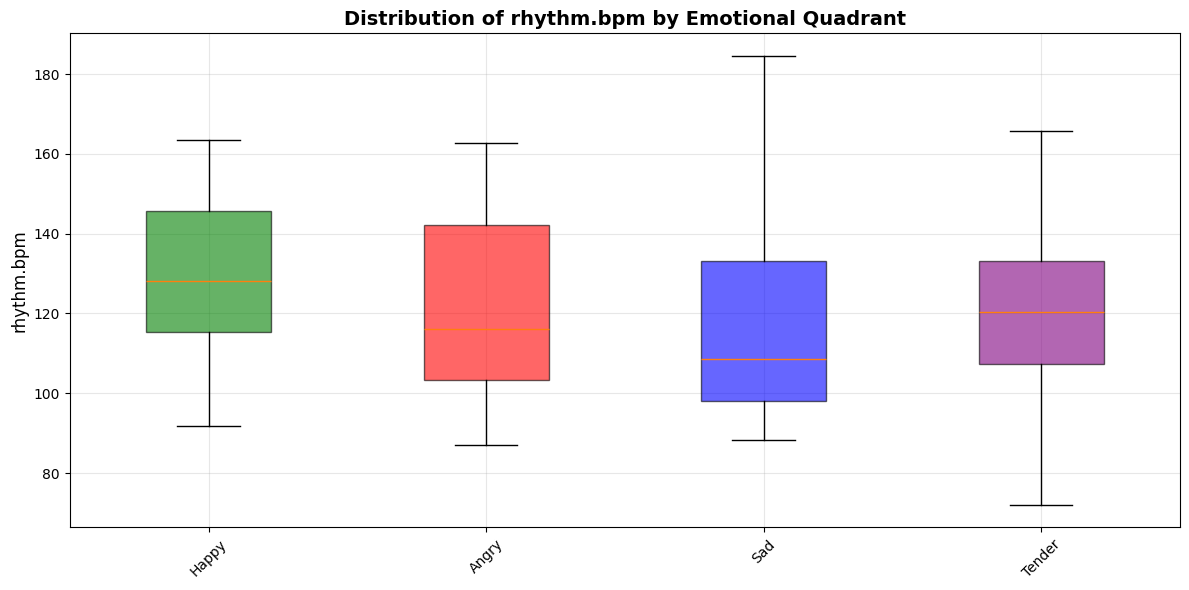


rhythm.bpm - Statistics:
--------------------------------------------------
Happy: n=20, mean=129.354, std=21.260
Angry: n=20, mean=122.033, std=23.937
Sad: n=20, mean=117.786, std=26.659
Tender: n=20, mean=123.131, std=24.474

ANOVA: F=0.743, p=0.5296
Effect size (η²): 0.029
→ No significant differences (p >= 0.05)

Analyzing: lowlevel.spectral_kurtosis.mean


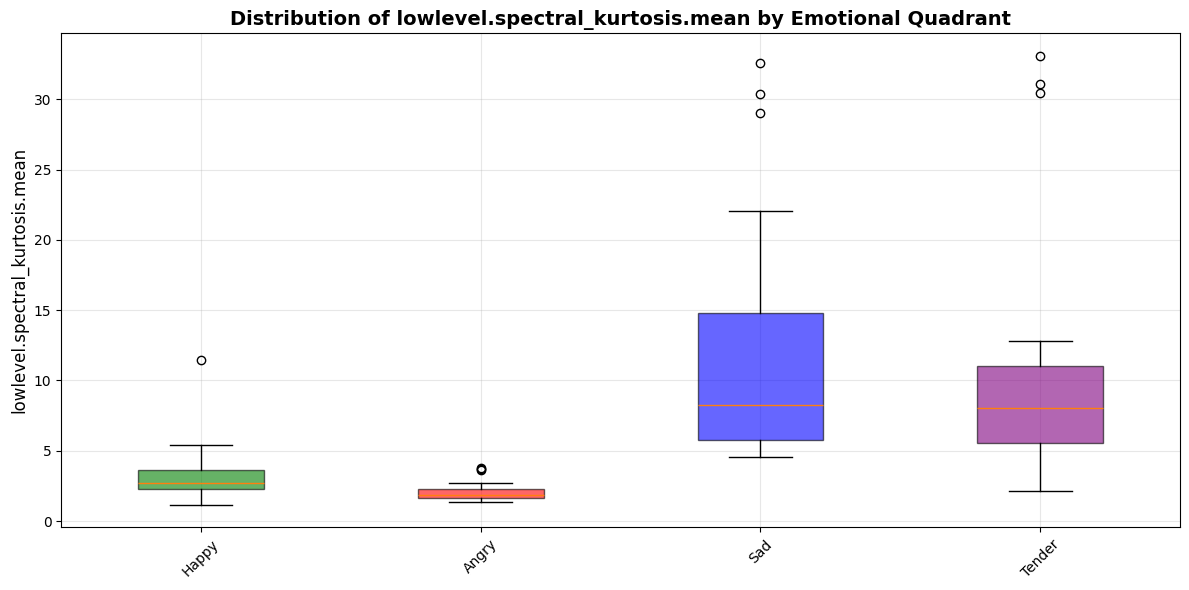


lowlevel.spectral_kurtosis.mean - Statistics:
--------------------------------------------------
Happy: n=20, mean=3.288, std=2.154
Angry: n=20, mean=2.122, std=0.758
Sad: n=20, mean=12.322, std=8.858
Tender: n=20, mean=11.192, std=8.929

ANOVA: F=12.908, p=0.0000
Effect size (η²): 0.338
→ SIGNIFICANT differences between quadrants! (p < 0.05)

Post-hoc Tukey HSD tests:
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
 Angry  Happy   1.1654  0.943 -4.2816  6.6125  False
 Angry    Sad  10.1997    0.0  4.7526 15.6468   True
 Angry Tender     9.07 0.0002  3.6229 14.5171   True
 Happy    Sad   9.0343 0.0002  3.5872 14.4813   True
 Happy Tender   7.9046 0.0016  2.4575 13.3517   True
   Sad Tender  -1.1297 0.9477 -6.5768  4.3174  False
----------------------------------------------------

Analyzing: lowlevel.spectral_kurtosis.stdev


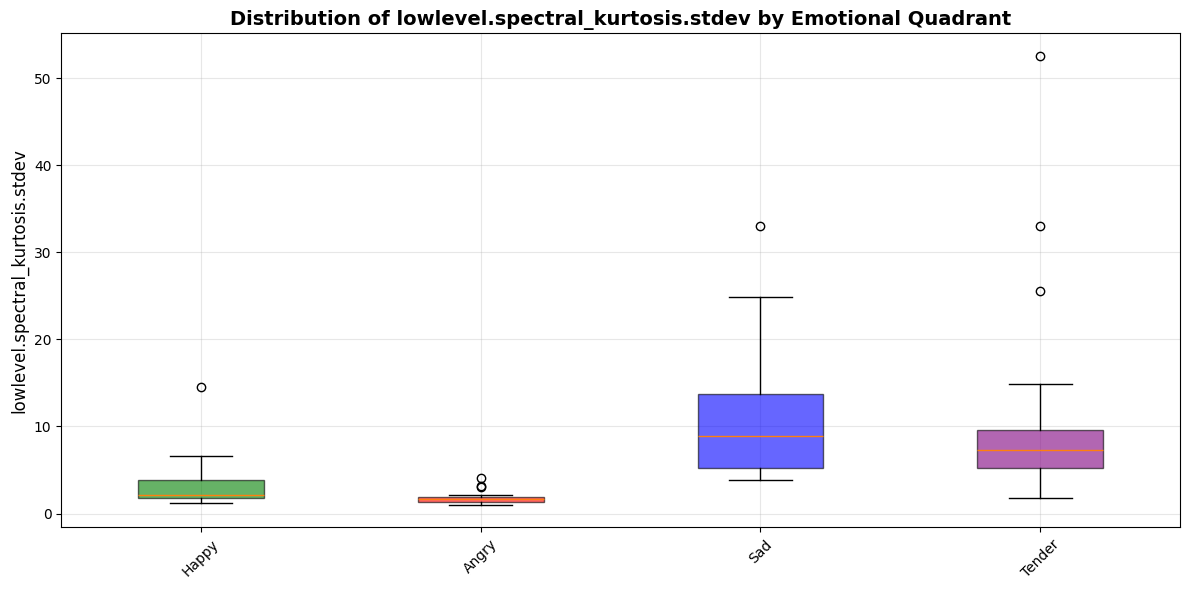


lowlevel.spectral_kurtosis.stdev - Statistics:
--------------------------------------------------
Happy: n=20, mean=3.200, std=2.914
Angry: n=20, mean=1.833, std=0.748
Sad: n=20, mean=11.472, std=7.824
Tender: n=20, mean=11.341, std=11.975

ANOVA: F=9.482, p=0.0000
Effect size (η²): 0.272
→ SIGNIFICANT differences between quadrants! (p < 0.05)

Post-hoc Tukey HSD tests:
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
 Angry  Happy   1.3668 0.9389  -4.862  7.5957  False
 Angry    Sad   9.6387 0.0007  3.4099 15.8676   True
 Angry Tender   9.5079 0.0008   3.279 15.7367   True
 Happy    Sad   8.2719 0.0044  2.0431 14.5008   True
 Happy Tender    8.141 0.0052  1.9122 14.3699   True
   Sad Tender  -0.1309 0.9999 -6.3597   6.098  False
----------------------------------------------------

Analyzing: tonal.chords_number_rate


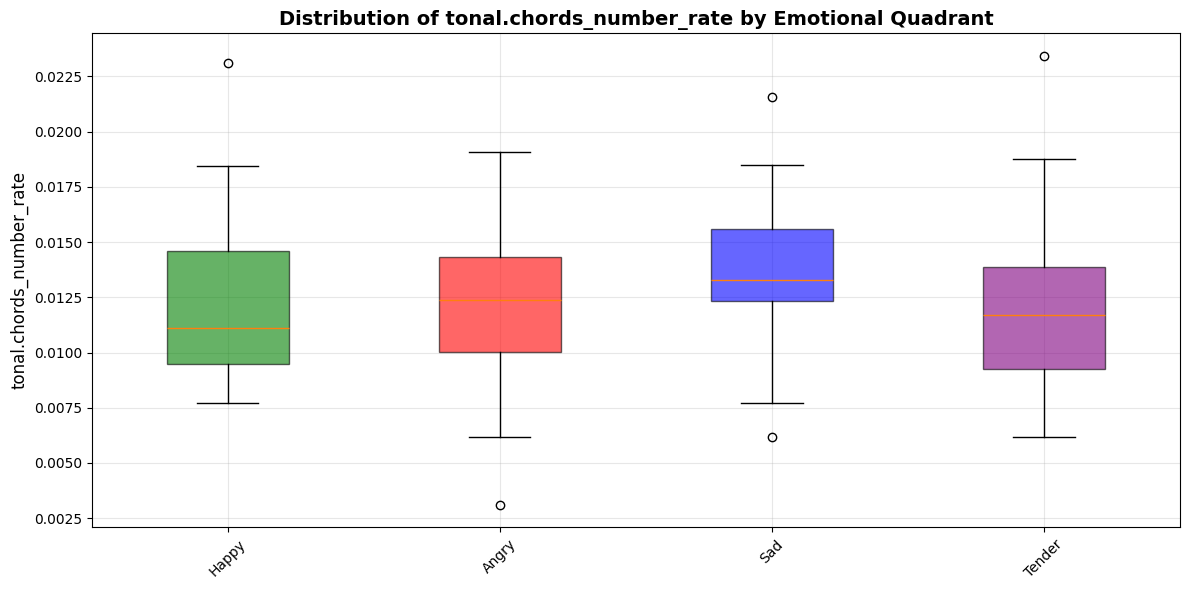


tonal.chords_number_rate - Statistics:
--------------------------------------------------
Happy: n=20, mean=0.013, std=0.004
Angry: n=20, mean=0.012, std=0.004
Sad: n=20, mean=0.013, std=0.004
Tender: n=20, mean=0.012, std=0.004

ANOVA: F=0.571, p=0.6361
Effect size (η²): 0.022
→ No significant differences (p >= 0.05)

Analyzing: tonal.chords_changes_rate


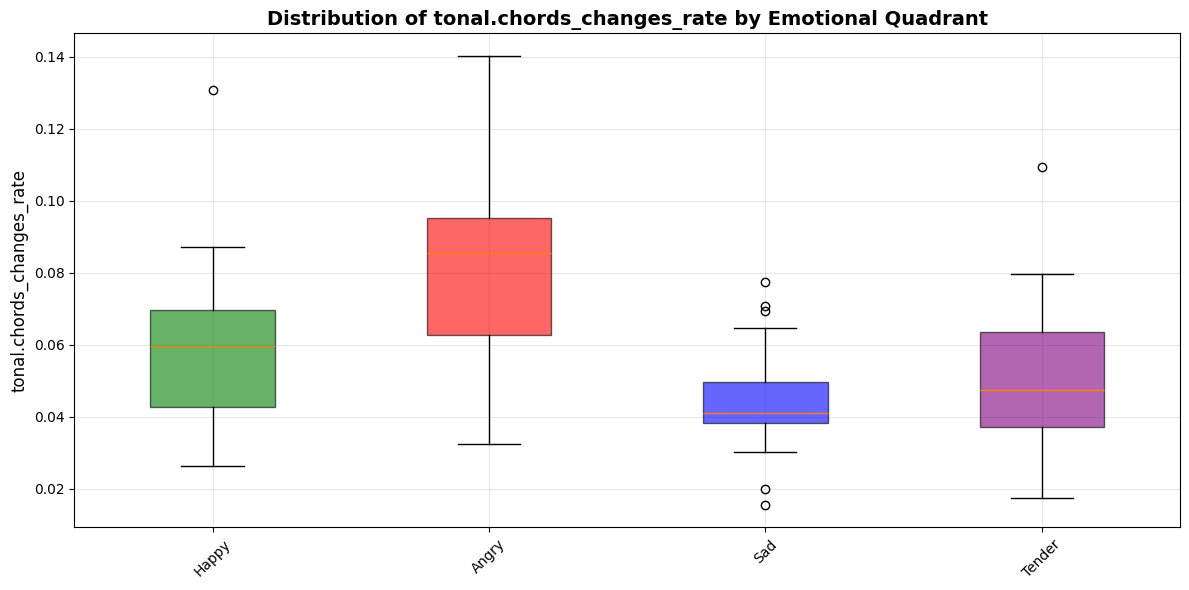


tonal.chords_changes_rate - Statistics:
--------------------------------------------------
Happy: n=20, mean=0.061, std=0.024
Angry: n=20, mean=0.085, std=0.027
Sad: n=20, mean=0.045, std=0.016
Tender: n=20, mean=0.050, std=0.021

ANOVA: F=12.062, p=0.0000
Effect size (η²): 0.323
→ SIGNIFICANT differences between quadrants! (p < 0.05)

Post-hoc Tukey HSD tests:
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
 Angry  Happy  -0.0243 0.0071 -0.0435 -0.0052   True
 Angry    Sad  -0.0405    0.0 -0.0597 -0.0214   True
 Angry Tender  -0.0348    0.0  -0.054 -0.0157   True
 Happy    Sad  -0.0162 0.1274 -0.0353   0.003  False
 Happy Tender  -0.0105 0.4793 -0.0297  0.0087  False
   Sad Tender   0.0057 0.8634 -0.0135  0.0248  False
----------------------------------------------------

Analyzing: lowlevel.dissonance.mean


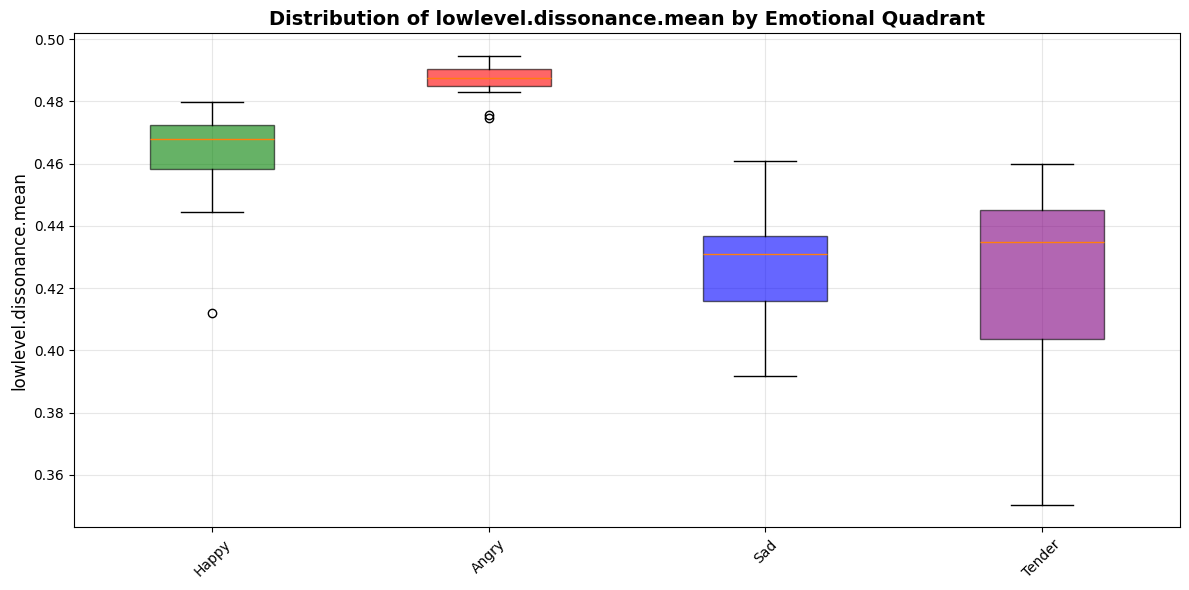


lowlevel.dissonance.mean - Statistics:
--------------------------------------------------
Happy: n=20, mean=0.463, std=0.015
Angry: n=20, mean=0.487, std=0.005
Sad: n=20, mean=0.427, std=0.018
Tender: n=20, mean=0.424, std=0.027

ANOVA: F=52.877, p=0.0000
Effect size (η²): 0.676
→ SIGNIFICANT differences between quadrants! (p < 0.05)

Post-hoc Tukey HSD tests:
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
 Angry  Happy  -0.0238 0.0007 -0.0392 -0.0084   True
 Angry    Sad  -0.0599    0.0 -0.0753 -0.0445   True
 Angry Tender  -0.0629    0.0 -0.0784 -0.0475   True
 Happy    Sad  -0.0361    0.0 -0.0515 -0.0207   True
 Happy Tender  -0.0391    0.0 -0.0546 -0.0237   True
   Sad Tender   -0.003 0.9556 -0.0185  0.0124  False
----------------------------------------------------

Analyzing: lowlevel.dissonance.stdev


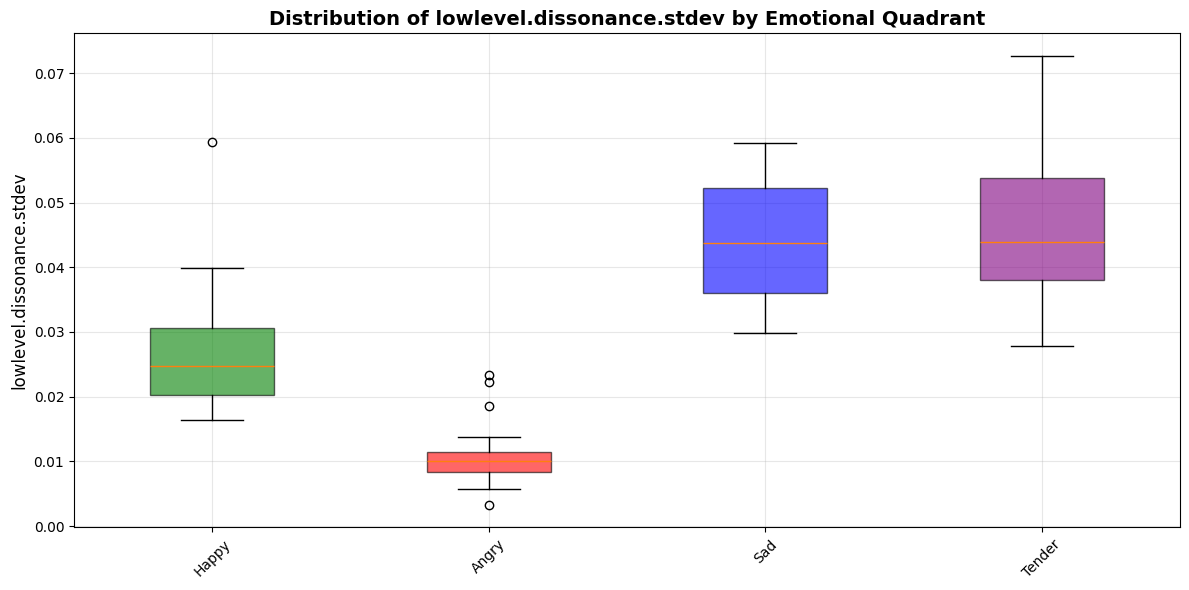


lowlevel.dissonance.stdev - Statistics:
--------------------------------------------------
Happy: n=20, mean=0.027, std=0.010
Angry: n=20, mean=0.011, std=0.005
Sad: n=20, mean=0.044, std=0.009
Tender: n=20, mean=0.046, std=0.012

ANOVA: F=56.195, p=0.0000
Effect size (η²): 0.689
→ SIGNIFICANT differences between quadrants! (p < 0.05)

Post-hoc Tukey HSD tests:
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
 Angry  Happy   0.0163    0.0  0.0082 0.0244   True
 Angry    Sad    0.033    0.0   0.025 0.0411   True
 Angry Tender   0.0348    0.0  0.0267 0.0429   True
 Happy    Sad   0.0168    0.0  0.0087 0.0248   True
 Happy Tender   0.0185    0.0  0.0104 0.0266   True
   Sad Tender   0.0018 0.9397 -0.0063 0.0099  False
---------------------------------------------------

Analyzing: lowlevel.average_loudness


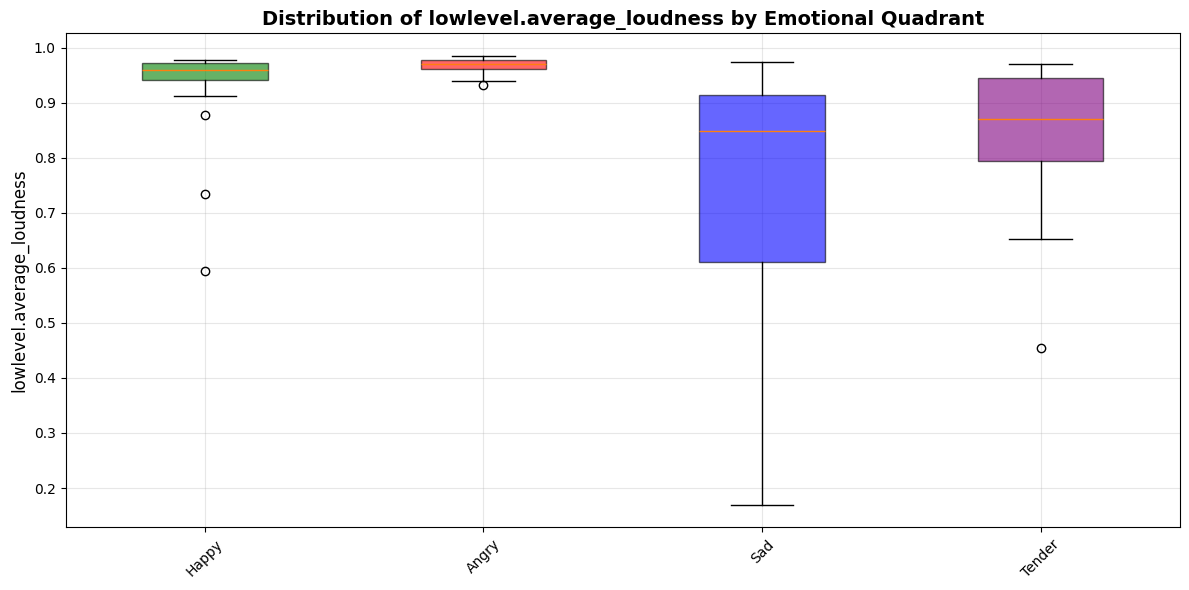


lowlevel.average_loudness - Statistics:
--------------------------------------------------
Happy: n=20, mean=0.925, std=0.093
Angry: n=20, mean=0.968, std=0.013
Sad: n=20, mean=0.747, std=0.227
Tender: n=20, mean=0.834, std=0.135

ANOVA: F=9.383, p=0.0000
Effect size (η²): 0.270
→ SIGNIFICANT differences between quadrants! (p < 0.05)

Post-hoc Tukey HSD tests:
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
 Angry  Happy  -0.0423 0.7887 -0.1617  0.0771  False
 Angry    Sad   -0.221    0.0 -0.3405 -0.1016   True
 Angry Tender  -0.1336 0.0223  -0.253 -0.0141   True
 Happy    Sad  -0.1787  0.001 -0.2982 -0.0593   True
 Happy Tender  -0.0913 0.1945 -0.2107  0.0282  False
   Sad Tender   0.0875 0.2269  -0.032  0.2069  False
----------------------------------------------------

Analyzing: lowlevel.pitch_salience.mean


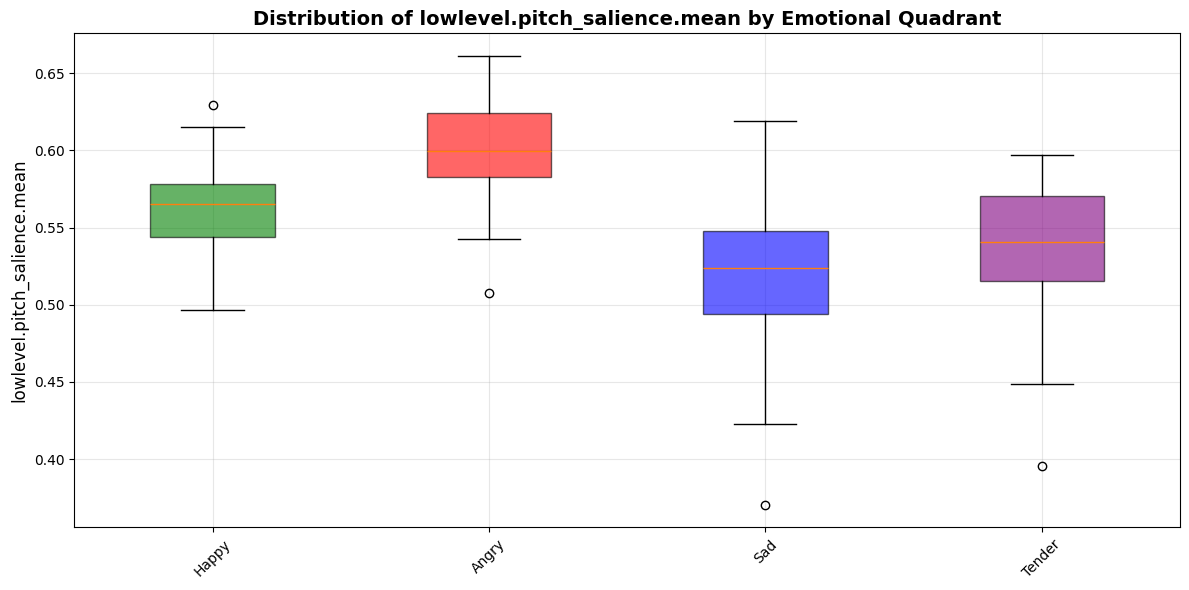


lowlevel.pitch_salience.mean - Statistics:
--------------------------------------------------
Happy: n=20, mean=0.561, std=0.033
Angry: n=20, mean=0.599, std=0.037
Sad: n=20, mean=0.514, std=0.055
Tender: n=20, mean=0.532, std=0.047

ANOVA: F=13.434, p=0.0000
Effect size (η²): 0.347
→ SIGNIFICANT differences between quadrants! (p < 0.05)

Post-hoc Tukey HSD tests:
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
 Angry  Happy  -0.0385 0.0425 -0.0761 -0.0009   True
 Angry    Sad  -0.0851    0.0 -0.1226 -0.0475   True
 Angry Tender  -0.0668 0.0001 -0.1044 -0.0293   True
 Happy    Sad  -0.0466  0.009 -0.0841  -0.009   True
 Happy Tender  -0.0283  0.204 -0.0659  0.0092  False
   Sad Tender   0.0182 0.5821 -0.0193  0.0558  False
----------------------------------------------------

Analyzing: lowlevel.pitch_salience.stdev


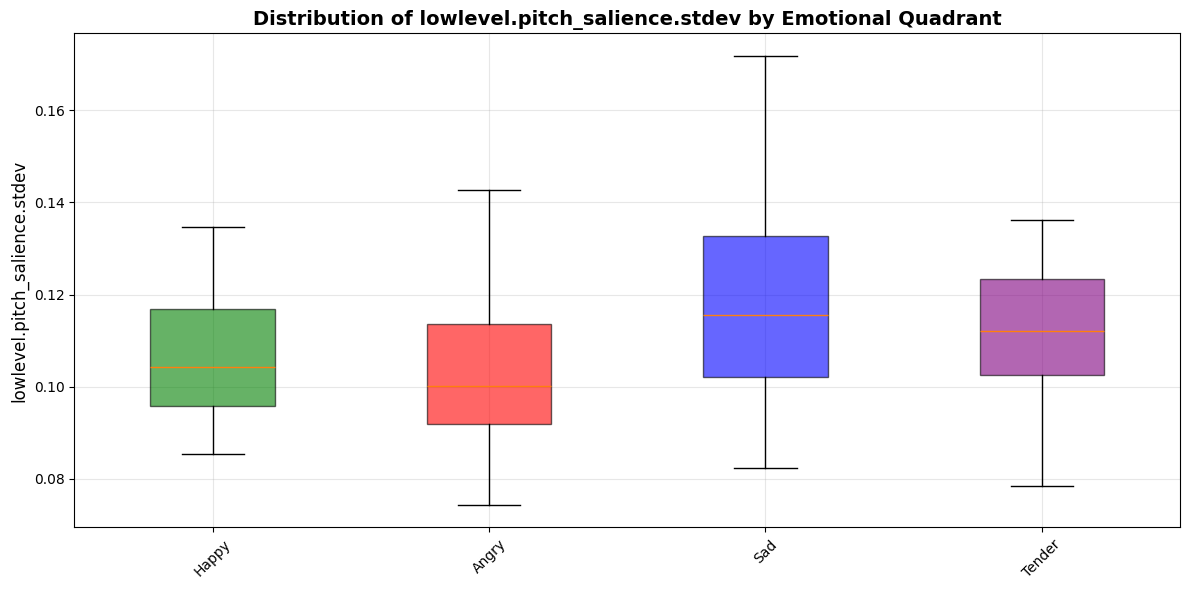


lowlevel.pitch_salience.stdev - Statistics:
--------------------------------------------------
Happy: n=20, mean=0.107, std=0.014
Angry: n=20, mean=0.103, std=0.017
Sad: n=20, mean=0.119, std=0.024
Tender: n=20, mean=0.111, std=0.017

ANOVA: F=2.560, p=0.0612
Effect size (η²): 0.092
→ No significant differences (p >= 0.05)

Analyzing: rhythm.onset_rate


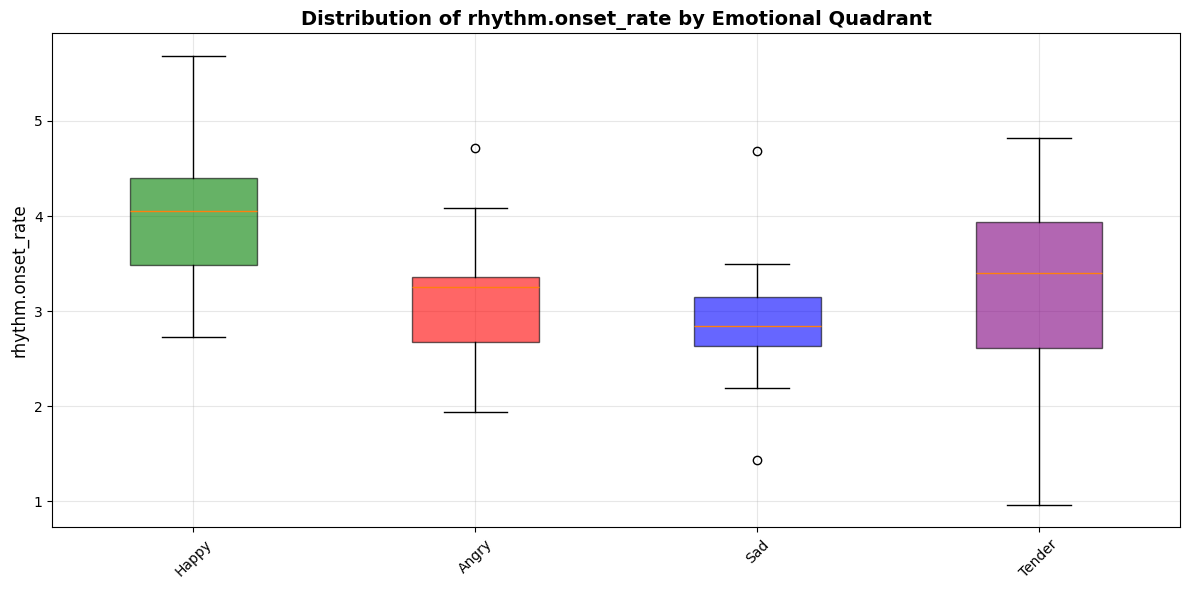


rhythm.onset_rate - Statistics:
--------------------------------------------------
Happy: n=20, mean=4.076, std=0.737
Angry: n=20, mean=3.164, std=0.643
Sad: n=20, mean=2.878, std=0.616
Tender: n=20, mean=3.312, std=0.929

ANOVA: F=9.052, p=0.0000
Effect size (η²): 0.263
→ SIGNIFICANT differences between quadrants! (p < 0.05)

Post-hoc Tukey HSD tests:
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
 Angry  Happy   0.9124 0.0017  0.2805  1.5443   True
 Angry    Sad  -0.2856 0.6368 -0.9175  0.3463  False
 Angry Tender   0.1488 0.9259 -0.4831  0.7807  False
 Happy    Sad   -1.198    0.0 -1.8299 -0.5661   True
 Happy Tender  -0.7636 0.0114 -1.3955 -0.1317   True
   Sad Tender   0.4343 0.2787 -0.1976  1.0662  False
----------------------------------------------------

Analyzing: lowlevel.spectral_centroid.mean


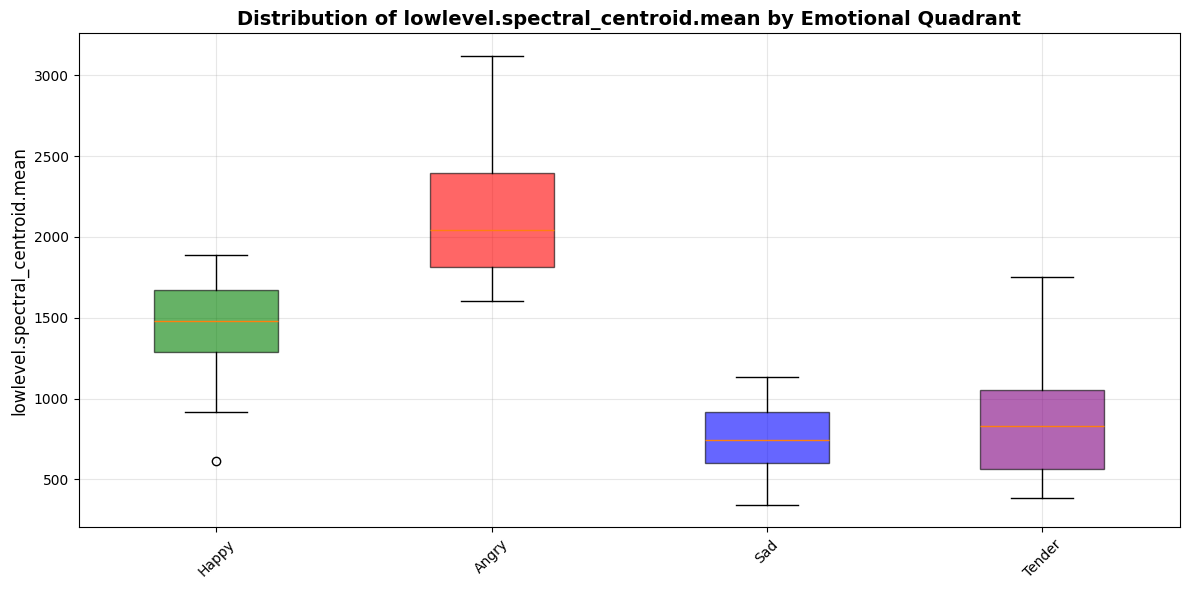


lowlevel.spectral_centroid.mean - Statistics:
--------------------------------------------------
Happy: n=20, mean=1432.682, std=346.145
Angry: n=20, mean=2141.694, std=416.992
Sad: n=20, mean=758.876, std=194.139
Tender: n=20, mean=844.917, std=343.757

ANOVA: F=69.079, p=0.0000
Effect size (η²): 0.732
→ SIGNIFICANT differences between quadrants! (p < 0.05)

Post-hoc Tukey HSD tests:
    Multiple Comparison of Means - Tukey HSD, FWER=0.05     
group1 group2  meandiff  p-adj    lower      upper    reject
------------------------------------------------------------
 Angry  Happy  -709.0125    0.0  -994.7237  -423.3012   True
 Angry    Sad -1382.8185    0.0 -1668.5297 -1097.1072   True
 Angry Tender -1296.7773    0.0 -1582.4885  -1011.066   True
 Happy    Sad   -673.806    0.0  -959.5172  -388.0948   True
 Happy Tender  -587.7648    0.0   -873.476  -302.0535   True
   Sad Tender    86.0412 0.8583    -199.67   371.7525  False
------------------------------------------------------------



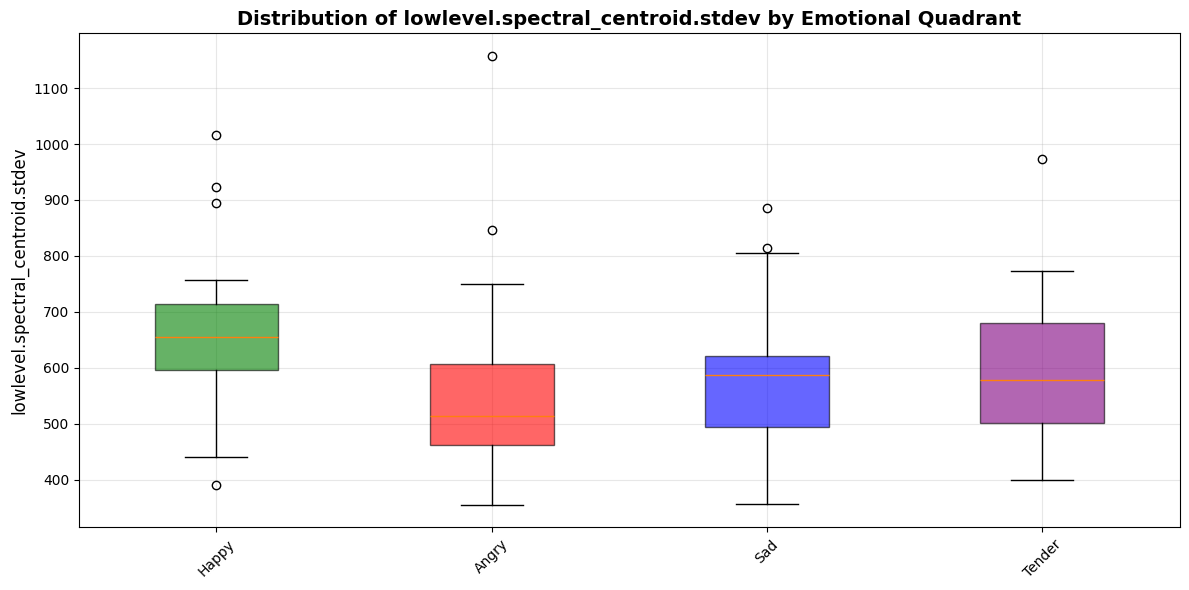


lowlevel.spectral_centroid.stdev - Statistics:
--------------------------------------------------
Happy: n=20, mean=667.238, std=149.818
Angry: n=20, mean=567.671, std=178.287
Sad: n=20, mean=579.867, std=139.949
Tender: n=20, mean=599.835, std=137.239

ANOVA: F=1.618, p=0.1922
Effect size (η²): 0.060
→ No significant differences (p >= 0.05)

Analyzing: tonal.hpcp_entropy.mean


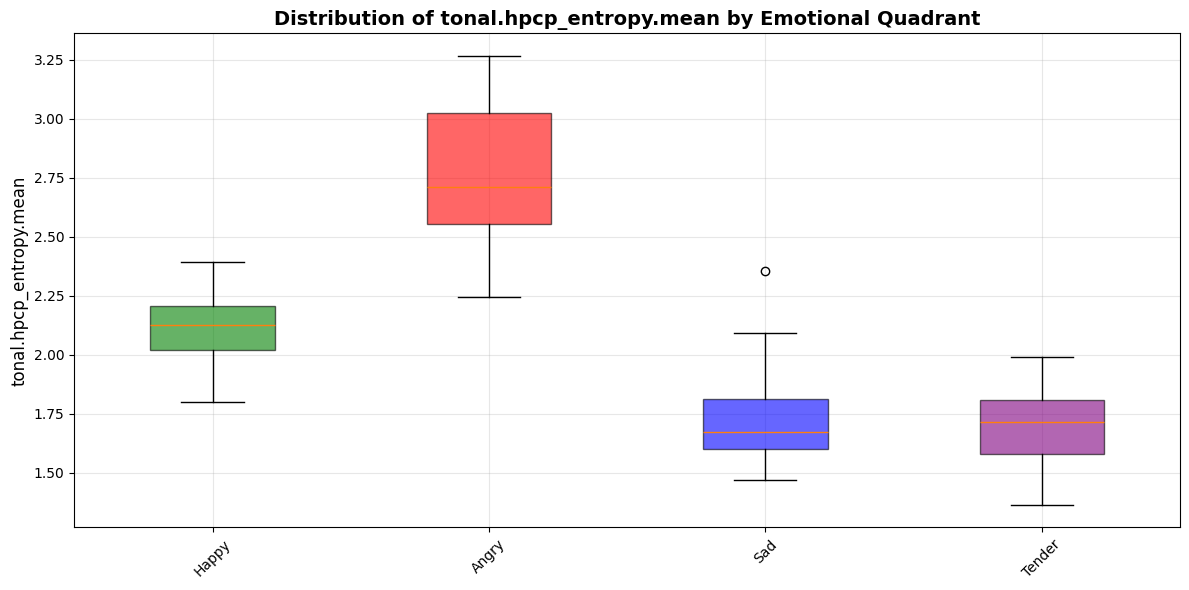


tonal.hpcp_entropy.mean - Statistics:
--------------------------------------------------
Happy: n=20, mean=2.098, std=0.158
Angry: n=20, mean=2.746, std=0.298
Sad: n=20, mean=1.742, std=0.220
Tender: n=20, mean=1.697, std=0.156

ANOVA: F=95.634, p=0.0000
Effect size (η²): 0.791
→ SIGNIFICANT differences between quadrants! (p < 0.05)

Post-hoc Tukey HSD tests:
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
 Angry  Happy  -0.6486    0.0 -0.8327 -0.4645   True
 Angry    Sad  -1.0043    0.0 -1.1884 -0.8202   True
 Angry Tender  -1.0491    0.0 -1.2332 -0.8649   True
 Happy    Sad  -0.3557    0.0 -0.5398 -0.1716   True
 Happy Tender  -0.4005    0.0 -0.5846 -0.2164   True
   Sad Tender  -0.0447 0.9192 -0.2289  0.1394  False
----------------------------------------------------

Analyzing: tonal.hpcp_entropy.stdev


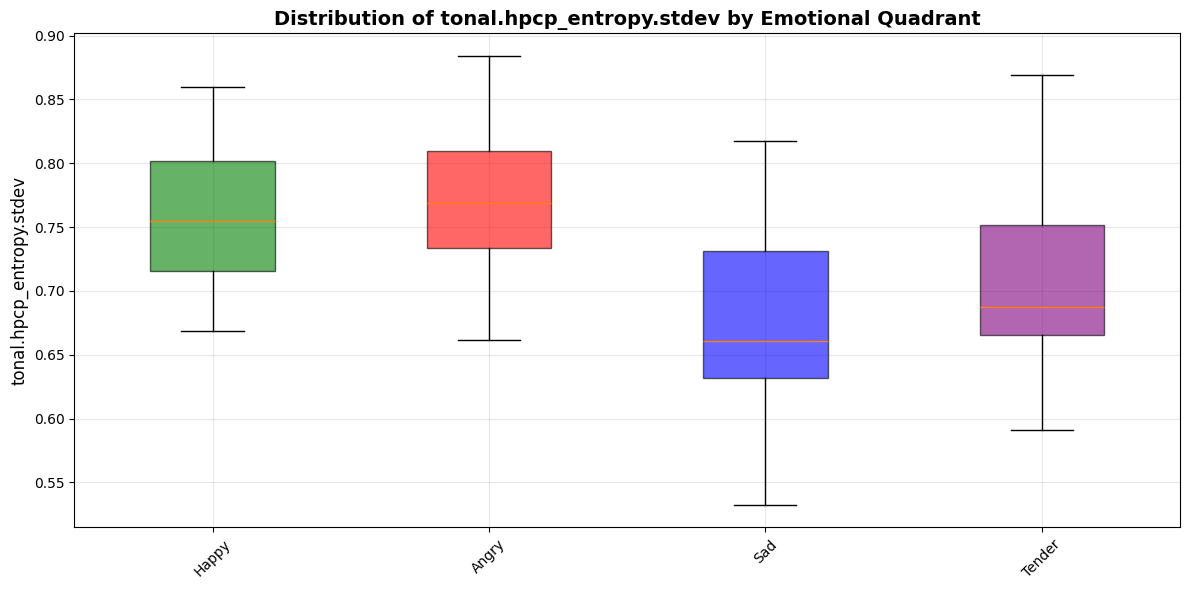


tonal.hpcp_entropy.stdev - Statistics:
--------------------------------------------------
Happy: n=20, mean=0.760, std=0.053
Angry: n=20, mean=0.769, std=0.054
Sad: n=20, mean=0.677, std=0.070
Tender: n=20, mean=0.703, std=0.067

ANOVA: F=9.846, p=0.0000
Effect size (η²): 0.280
→ SIGNIFICANT differences between quadrants! (p < 0.05)

Post-hoc Tukey HSD tests:
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
 Angry  Happy  -0.0092 0.9675 -0.0618  0.0434  False
 Angry    Sad   -0.092 0.0001 -0.1446 -0.0394   True
 Angry Tender  -0.0659  0.008 -0.1185 -0.0134   True
 Happy    Sad  -0.0828 0.0005 -0.1354 -0.0302   True
 Happy Tender  -0.0567 0.0293 -0.1093 -0.0042   True
   Sad Tender   0.0261 0.5642 -0.0265  0.0786  False
----------------------------------------------------

ANALYZING CATEGORICAL FEATURES:

Analyzing: tonal.key_krumhansl.scale


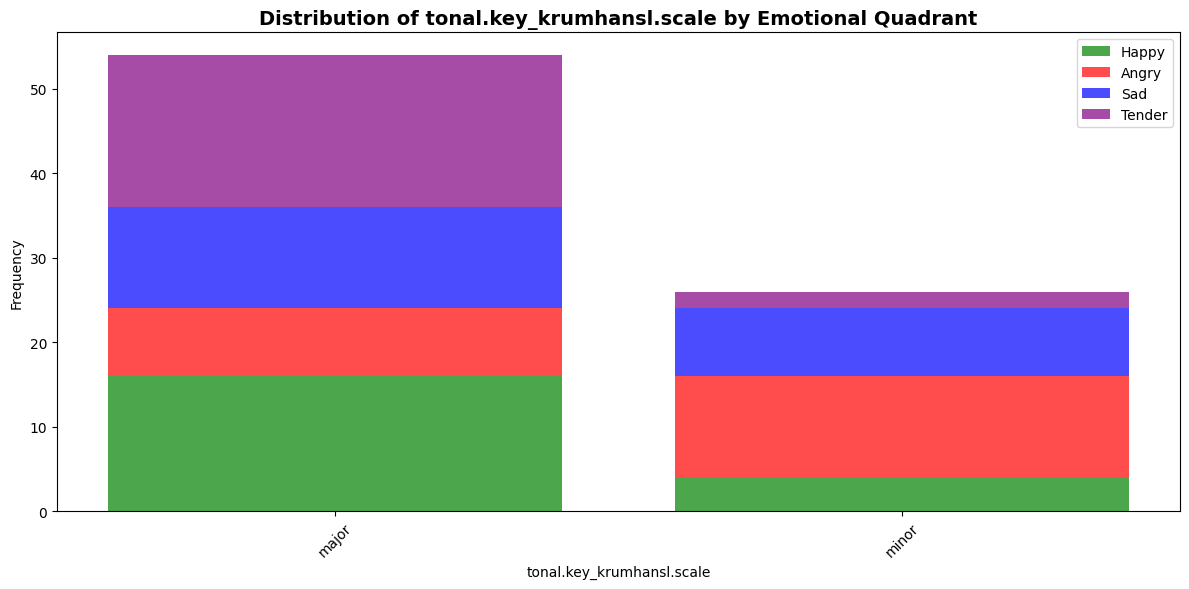


tonal.key_krumhansl.scale - Value counts:
----------------------------------------
Happy: {'major': 16, 'minor': 4}
Angry: {'minor': 12, 'major': 8}
Sad: {'major': 12, 'minor': 8}
Tender: {'major': 18, 'minor': 2}

Chi-squared test: χ²=13.447, p=0.0038, dof=3
→ SIGNIFICANT association between quadrant and category! (p < 0.05)

Analyzing: tonal.chords_key


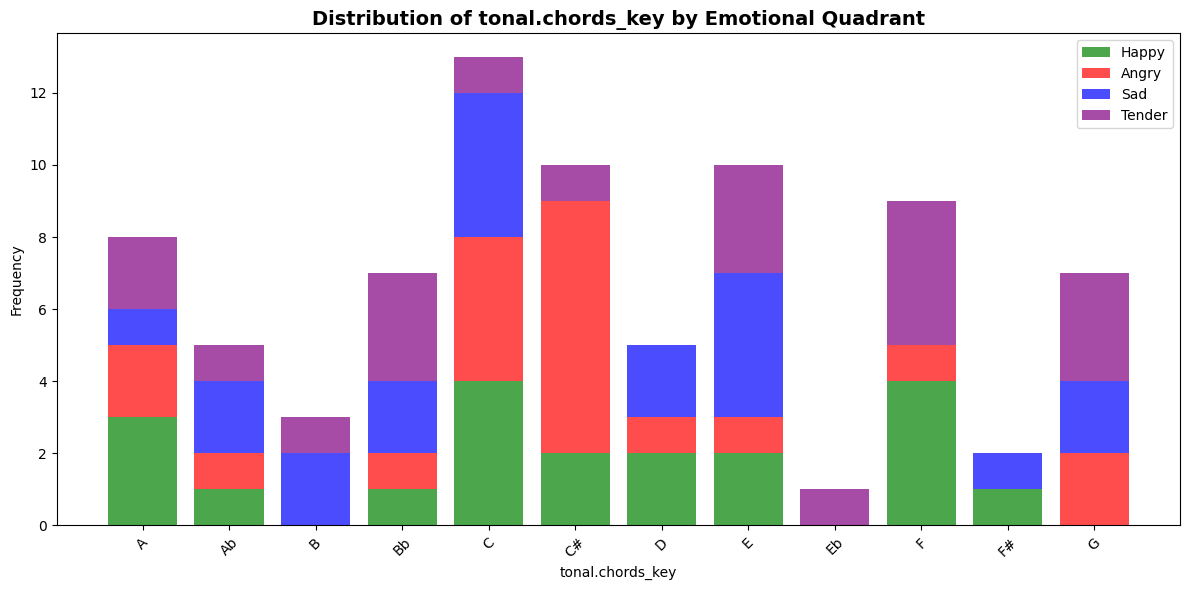


tonal.chords_key - Value counts:
----------------------------------------
Happy: {'F': 4, 'C': 4, 'A': 3, 'D': 2, 'E': 2, 'C#': 2, 'Bb': 1, 'F#': 1, 'Ab': 1}
Angry: {'C#': 7, 'C': 4, 'G': 2, 'A': 2, 'Ab': 1, 'Bb': 1, 'E': 1, 'F': 1, 'D': 1}
Sad: {'E': 4, 'C': 4, 'G': 2, 'Ab': 2, 'Bb': 2, 'D': 2, 'B': 2, 'F#': 1, 'A': 1}
Tender: {'F': 4, 'G': 3, 'Bb': 3, 'E': 3, 'A': 2, 'C#': 1, 'Ab': 1, 'B': 1, 'Eb': 1, 'C': 1}

Chi-squared test: χ²=38.096, p=0.2486, dof=33
→ No significant association (p >= 0.05)

SUMMARY OF FINDINGS
Total features analyzed: 17
Significant features (p < 0.05): 12

Significant features:
✓ lowlevel.spectral_kurtosis.mean
✓ lowlevel.spectral_kurtosis.stdev
✓ tonal.chords_changes_rate
✓ lowlevel.dissonance.mean
✓ lowlevel.dissonance.stdev
✓ lowlevel.average_loudness
✓ lowlevel.pitch_salience.mean
✓ rhythm.onset_rate
✓ lowlevel.spectral_centroid.mean
✓ tonal.hpcp_entropy.mean
✓ tonal.hpcp_entropy.stdev
✓ tonal.key_krumhansl.scale

Generating correlation heatmap of signifi

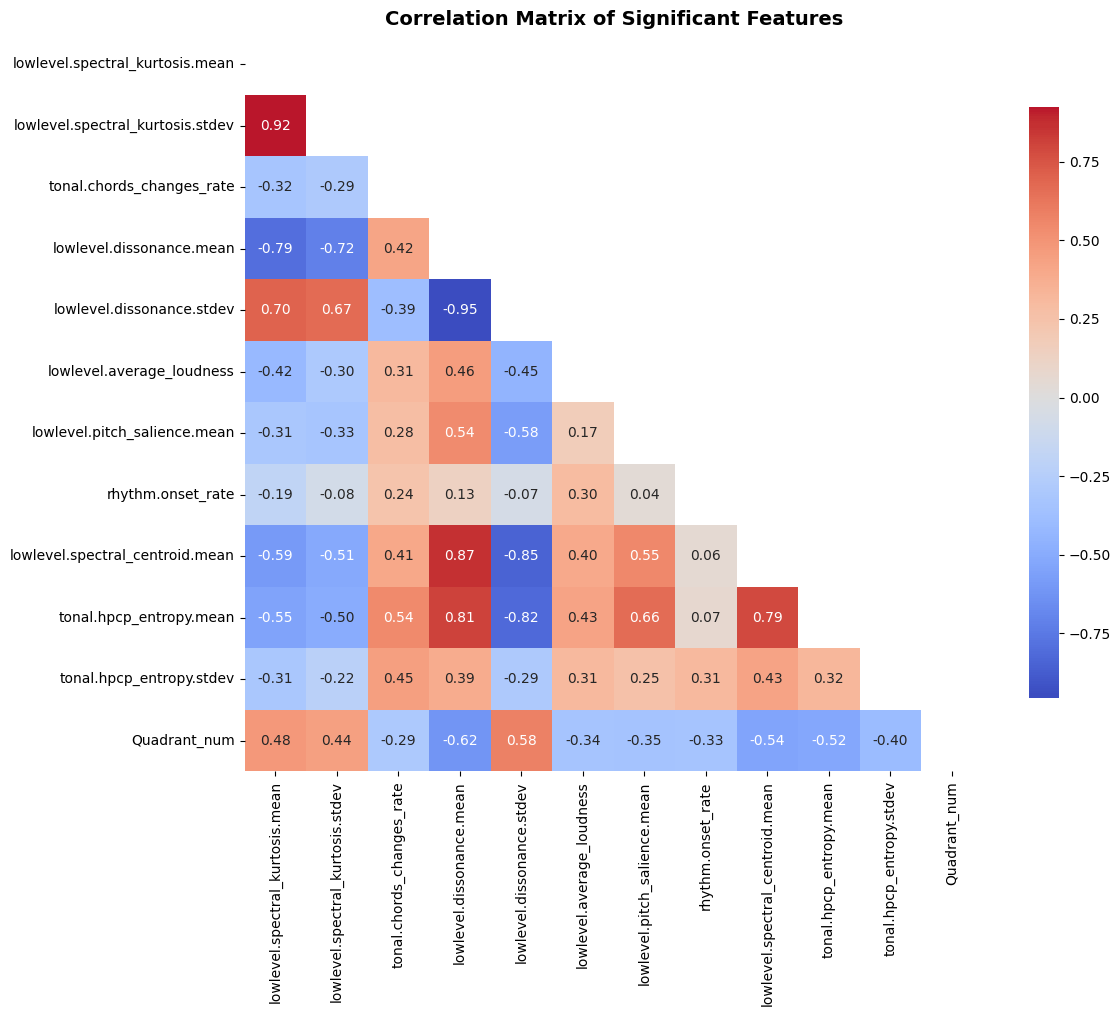


Top features correlated with emotional quadrant:
lowlevel.dissonance.mean: -0.623
lowlevel.dissonance.stdev: 0.582
lowlevel.spectral_centroid.mean: -0.543
tonal.hpcp_entropy.mean: -0.522
lowlevel.spectral_kurtosis.mean: 0.483
lowlevel.spectral_kurtosis.stdev: 0.444
tonal.hpcp_entropy.stdev: -0.403
lowlevel.pitch_salience.mean: -0.349
lowlevel.average_loudness: -0.337
rhythm.onset_rate: -0.333

EMOTIONAL PROFILES BASED ON MUSICAL FEATURES

Happy (Q1) Profile:
----------------------------------------
  rhythm.bpm: 129.354 ± 21.812
  lowlevel.average_loudness: 0.925 ± 0.095
  lowlevel.dissonance.mean: 0.463 ± 0.016
  lowlevel.spectral_centroid.mean: 1432.682 ± 355.137
  tonal.chords_changes_rate: 0.061 ± 0.024
  rhythm.onset_rate: 4.076 ± 0.756

Angry (Q2) Profile:
----------------------------------------
  rhythm.bpm: 122.033 ± 24.559
  lowlevel.average_loudness: 0.968 ± 0.014
  lowlevel.dissonance.mean: 0.487 ± 0.005
  lowlevel.spectral_centroid.mean: 2141.694 ± 427.825
  tonal.chords_

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.utils import resample
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')

class EmotionalQuadrantAnalyzer:
    def __init__(self, df, random_state=42):
        self.df = df
        self.random_state = random_state
        self.balanced_df = None
        self.available_features = []
        self.significant_features = []

        # Define feature categories
        self.relevant_features = [
            'rhythm.bpm',
            'lowlevel.spectral_kurtosis.mean',
            'lowlevel.spectral_kurtosis.stdev',
            'tonal.chords_number_rate',
            'tonal.chords_changes_rate',
            'lowlevel.dissonance.mean',
            'lowlevel.dissonance.stdev',
            'lowlevel.average_loudness',
            'lowlevel.pitch_salience.mean',
            'lowlevel.pitch_salience.stdev',
            'rhythm.onset_rate',
            'lowlevel.spectral_centroid.mean',
            'lowlevel.spectral_centroid.stdev',
            'tonal.hpcp_entropy.mean',
            'tonal.hpcp_entropy.stdev',
            'tonal.key_krumhansl.scale',
            'tonal.chords_key',
        ]

        self.categorical_features = ['tonal.key_krumhansl.scale', 'tonal.chords_key']
        self.quadrant_colors = {'Q1': 'green', 'Q2': 'red', 'Q3': 'blue', 'Q4': 'purple'}
        self.quadrant_labels = {'Q1': 'Happy', 'Q2': 'Angry', 'Q3': 'Sad', 'Q4': 'Tender'}

    def prepare_balanced_data(self):
        """Create balanced dataset with equal samples per quadrant"""
        print("Preparing balanced dataset...")

        # Get sample sizes per quadrant
        quadrant_counts = self.df['Quadrant'].value_counts()
        print("Original sample sizes:")
        for quadrant, count in quadrant_counts.items():
            print(f"  {self.quadrant_labels[quadrant]} ({quadrant}): {count}")

        # Find minimum sample size
        min_samples = min(quadrant_counts)
        print(f"\nBalancing to {min_samples} samples per quadrant")

        # Resample each quadrant to minimum size
        balanced_dfs = []
        for quadrant in ['Q1', 'Q2', 'Q3', 'Q4']:
            quadrant_data = self.df[self.df['Quadrant'] == quadrant]
            if len(quadrant_data) > min_samples:
                balanced_quadrant = resample(
                    quadrant_data,
                    replace=False,
                    n_samples=min_samples,
                    random_state=self.random_state
                )
            else:
                balanced_quadrant = quadrant_data
            balanced_dfs.append(balanced_quadrant)

        self.balanced_df = pd.concat(balanced_dfs, ignore_index=True)

        print("\nBalanced dataset sample sizes:")
        balanced_counts = self.balanced_df['Quadrant'].value_counts()
        for quadrant, count in balanced_counts.items():
            print(f"  {self.quadrant_labels[quadrant]} ({quadrant}): {count}")

        return self.balanced_df

    def check_available_features(self):
        """Check which features are available in the dataframe"""
        self.available_features = [f for f in self.relevant_features if f in self.df.columns]

        print("Available features for analysis:")
        for feature in self.available_features:
            print(f"✓ {feature}")

        print(f"\nTotal available: {len(self.available_features)} out of {len(self.relevant_features)}")
        return self.available_features

    def analyze_continuous_feature(self, feature_name, data):
        """Analyze distribution of a continuous feature across quadrants"""
        if feature_name not in data.columns:
            print(f"Feature {feature_name} not found in dataframe")
            return False

        plt.figure(figsize=(12, 6))

        quadrant_data = []
        labels = []

        for quadrant in ['Q1', 'Q2', 'Q3', 'Q4']:
            values = data[data['Quadrant'] == quadrant][feature_name].dropna()
            if len(values) > 0:
                quadrant_data.append(values)
                labels.append(self.quadrant_labels[quadrant])

        if len(quadrant_data) >= 2:
            # Create box plot
            box_plot = plt.boxplot(quadrant_data, labels=labels, patch_artist=True)

            # Add colors
            for patch, quadrant in zip(box_plot['boxes'], ['Q1', 'Q2', 'Q3', 'Q4'][:len(quadrant_data)]):
                patch.set_facecolor(self.quadrant_colors[quadrant])
                patch.set_alpha(0.6)

            plt.title(f'Distribution of {feature_name} by Emotional Quadrant', fontsize=14, fontweight='bold')
            plt.ylabel(feature_name, fontsize=12)
            plt.xticks(rotation=45)
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()

            # Print statistics
            print(f"\n{feature_name} - Statistics:")
            print("-" * 50)
            for i, label in enumerate(labels):
                values = quadrant_data[i]
                print(f"{label}: n={len(values)}, mean={np.mean(values):.3f}, std={np.std(values):.3f}")

            # ANOVA test
            f_stat, p_value = stats.f_oneway(*quadrant_data)
            print(f"\nANOVA: F={f_stat:.3f}, p={p_value:.4f}")

            # Calculate effect size (eta squared)
            grand_mean = np.concatenate(quadrant_data).mean()
            ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in quadrant_data)
            ss_total = sum(np.sum((g - grand_mean)**2) for g in quadrant_data)
            eta_squared = ss_between / ss_total if ss_total > 0 else 0
            print(f"Effect size (η²): {eta_squared:.3f}")

            if p_value < 0.05:
                print("→ SIGNIFICANT differences between quadrants! (p < 0.05)")

                # Post-hoc tests for significant features
                if len(quadrant_data) > 2:
                    print("\nPost-hoc Tukey HSD tests:")
                    tukey_data = []
                    tukey_labels = []
                    for i, label in enumerate(labels):
                        tukey_data.extend(quadrant_data[i])
                        tukey_labels.extend([label] * len(quadrant_data[i]))

                    tukey_result = pairwise_tukeyhsd(tukey_data, tukey_labels, alpha=0.05)
                    print(tukey_result)
            else:
                print("→ No significant differences (p >= 0.05)")

            print("=" * 60)

            return p_value < 0.05
        return False

    def analyze_categorical_feature(self, feature_name, data):
        """Analyze distribution of categorical features"""
        if feature_name not in data.columns:
            print(f"Feature {feature_name} not found in dataframe")
            return False

        plt.figure(figsize=(12, 6))

        # Get value counts for each quadrant
        quadrant_counts = {}
        for quadrant in ['Q1', 'Q2', 'Q3', 'Q4']:
            values = data[data['Quadrant'] == quadrant][feature_name].dropna()
            if len(values) > 0:
                counts = values.value_counts()
                quadrant_counts[self.quadrant_labels[quadrant]] = counts

        if quadrant_counts:
            # Create stacked bar plot
            all_categories = set()
            for counts in quadrant_counts.values():
                all_categories.update(counts.index)
            all_categories = sorted(all_categories)

            bottom = np.zeros(len(all_categories))

            for i, (label, counts) in enumerate(quadrant_counts.items()):
                quadrant = [k for k, v in self.quadrant_labels.items() if v == label][0]
                values = [counts.get(cat, 0) for cat in all_categories]
                plt.bar(all_categories, values, bottom=bottom, label=label,
                       color=self.quadrant_colors[quadrant], alpha=0.7)
                bottom += values

            plt.title(f'Distribution of {feature_name} by Emotional Quadrant', fontsize=14, fontweight='bold')
            plt.xlabel(feature_name)
            plt.ylabel('Frequency')
            plt.legend()
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()

            # Print statistics
            print(f"\n{feature_name} - Value counts:")
            print("-" * 40)
            for label, counts in quadrant_counts.items():
                print(f"{label}: {counts.to_dict()}")

            # Chi-squared test for independence
            contingency_data = []
            for label in ['Happy', 'Angry', 'Sad', 'Tender']:
                if label in quadrant_counts:
                    row = [quadrant_counts[label].get(cat, 0) for cat in all_categories]
                    contingency_data.append(row)

            if len(contingency_data) >= 2:
                chi2, p_value, dof, expected = chi2_contingency(contingency_data)
                print(f"\nChi-squared test: χ²={chi2:.3f}, p={p_value:.4f}, dof={dof}")
                if p_value < 0.05:
                    print("→ SIGNIFICANT association between quadrant and category! (p < 0.05)")
                else:
                    print("→ No significant association (p >= 0.05)")

            print("=" * 60)

            return p_value < 0.05 if 'p_value' in locals() else False
        return False

    def run_comprehensive_analysis(self):
        """Run complete analysis with balanced data"""
        print("EMOTIONAL QUADRANT MUSICAL FEATURE ANALYSIS")
        print("=" * 70)

        # Prepare balanced data
        balanced_data = self.prepare_balanced_data()

        # Check available features
        self.check_available_features()

        self.significant_features = []

        # Analyze continuous features
        print("\nANALYZING CONTINUOUS FEATURES:")
        print("=" * 50)

        for feature in self.available_features:
            if feature not in self.categorical_features:
                print(f"\nAnalyzing: {feature}")
                is_significant = self.analyze_continuous_feature(feature, balanced_data)
                if is_significant:
                    self.significant_features.append(feature)

        # Analyze categorical features
        print("\nANALYZING CATEGORICAL FEATURES:")
        print("=" * 50)

        for feature in self.categorical_features:
            if feature in self.available_features:
                print(f"\nAnalyzing: {feature}")
                is_significant = self.analyze_categorical_feature(feature, balanced_data)
                if is_significant:
                    self.significant_features.append(feature)

        self._generate_summary()
        self._generate_correlation_analysis()

        return self.significant_features

    def _generate_summary(self):
        """Generate summary of findings"""
        print("\n" + "="*70)
        print("SUMMARY OF FINDINGS")
        print("="*70)
        print(f"Total features analyzed: {len(self.available_features)}")
        print(f"Significant features (p < 0.05): {len(self.significant_features)}")
        print("\nSignificant features:")
        for feature in self.significant_features:
            print(f"✓ {feature}")

    def _generate_correlation_analysis(self):
        """Generate correlation analysis for significant features"""
        if self.significant_features and len(self.significant_features) > 1:
            print("\nGenerating correlation heatmap of significant features...")

            plt.figure(figsize=(12, 10))

            # Calculate correlations
            corr_data = self.balanced_df[self.significant_features + ['Quadrant']].copy()

            # Convert quadrant to numerical for correlation
            quadrant_map = {'Q1': 1, 'Q2': 2, 'Q3': 3, 'Q4': 4}
            corr_data['Quadrant_num'] = corr_data['Quadrant'].map(quadrant_map)
            corr_data = corr_data.select_dtypes(include=[np.number])

            correlation_matrix = corr_data.corr()

            # Plot heatmap
            mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
            sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm', center=0,
                        square=True, fmt='.2f', cbar_kws={"shrink": .8})
            plt.title('Correlation Matrix of Significant Features', fontsize=14, fontweight='bold')
            plt.tight_layout()
            plt.show()

            # Highlight correlations with quadrant
            if 'Quadrant_num' in correlation_matrix.columns:
                quadrant_correlations = correlation_matrix['Quadrant_num'].drop('Quadrant_num').sort_values(key=abs, ascending=False)
                print("\nTop features correlated with emotional quadrant:")
                for feature, corr in quadrant_correlations.head(10).items():
                    print(f"{feature}: {corr:.3f}")

    def generate_emotional_profiles(self):
        """Generate emotional profiles based on feature patterns"""
        if self.balanced_df is None:
            print("Please run comprehensive analysis first")
            return

        print("\nEMOTIONAL PROFILES BASED ON MUSICAL FEATURES")
        print("=" * 60)

        # Key features for emotional characterization
        key_features = [
            'rhythm.bpm',  # Tempo
            'lowlevel.average_loudness',  # Energy
            'lowlevel.dissonance.mean',  # Harmony
            'lowlevel.spectral_centroid.mean',  # Brightness
            'tonal.chords_changes_rate',  # Harmonic complexity
            'rhythm.onset_rate'  # Rhythmic density
        ]

        available_key_features = [f for f in key_features if f in self.available_features]

        for quadrant in ['Q1', 'Q2', 'Q3', 'Q4']:
            quadrant_data = self.balanced_df[self.balanced_df['Quadrant'] == quadrant]
            quadrant_name = self.quadrant_labels[quadrant]

            print(f"\n{quadrant_name} ({quadrant}) Profile:")
            print("-" * 40)

            for feature in available_key_features:
                if feature in quadrant_data.columns:
                    mean_val = quadrant_data[feature].mean()
                    std_val = quadrant_data[feature].std()
                    print(f"  {feature}: {mean_val:.3f} ± {std_val:.3f}")

# Usage example
if __name__ == "__main__":
    # Initialize analyzer with your dataframe
    analyzer = EmotionalQuadrantAnalyzer(df)

    # Run comprehensive analysis
    significant_features = analyzer.run_comprehensive_analysis()

    # Generate emotional profiles
    analyzer.generate_emotional_profiles()

## Working pipeline


EMOTIONAL QUADRANT MUSICAL FEATURE ANALYSIS
Preparing balanced dataset...
Detected keys in dataset: ['A', 'Ab', 'B', 'Bb', 'C', 'C#', 'D', 'E', 'Eb', 'F', 'F#', 'G']
Original sample sizes:
  Angry (Q2): 58
  Tender (Q4): 22
  Happy (Q1): 21
  Sad (Q3): 20

Balancing using method='downsample' to 20 samples per quadrant

Balanced dataset sample sizes:
  Happy (Q1): 20
  Angry (Q2): 20
  Sad (Q3): 20
  Tender (Q4): 20

Available features for analysis:
✓ rhythm.bpm
✓ lowlevel.spectral_kurtosis.mean
✓ lowlevel.spectral_kurtosis.stdev
✓ tonal.chords_number_rate
✓ tonal.chords_changes_rate
✓ lowlevel.dissonance.mean
✓ lowlevel.dissonance.stdev
✓ lowlevel.average_loudness
✓ lowlevel.pitch_salience.mean
✓ lowlevel.pitch_salience.stdev
✓ rhythm.onset_rate
✓ lowlevel.spectral_centroid.mean
✓ lowlevel.spectral_centroid.stdev
✓ tonal.hpcp_entropy.mean
✓ tonal.hpcp_entropy.stdev
✓ tonal.key_krumhansl.scale
✓ tonal.chords_key

Total available: 17 / 17

ANALYZING CONTINUOUS FEATURES

-> rhythm.bpm


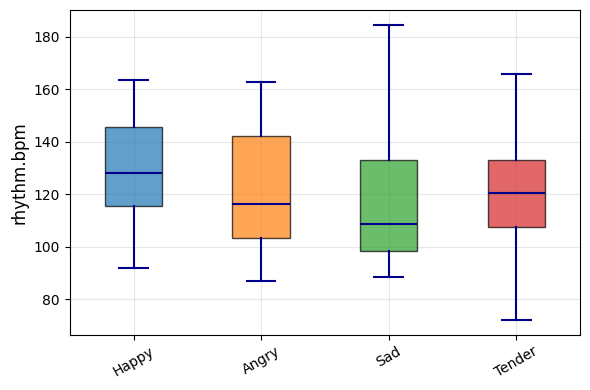


rhythm.bpm - group statistics (mean ± std) and bootstrap 95% CI:
  Happy: n=20, mean=129.3544, std=21.2597, 95%CI_mean=(120.5292, 138.7200)
  Angry: n=20, mean=122.0328, std=23.9372, 95%CI_mean=(112.1494, 132.5060)
  Sad: n=20, mean=117.7860, std=26.6585, 95%CI_mean=(106.5311, 130.0114)
  Tender: n=20, mean=123.1315, std=24.4742, 95%CI_mean=(113.1757, 133.6498)

Assumption checks:
  Shapiro Happy: p=0.6555
  Shapiro Angry: p=0.1092
  Shapiro Sad: p=0.0143
  Shapiro Tender: p=0.3187
  Levene (equal variances) p=0.9567

Kruskal-Wallis: H=3.3572, p=0.33976, (eta² (descr)=0.029)

-> lowlevel.spectral_kurtosis.mean


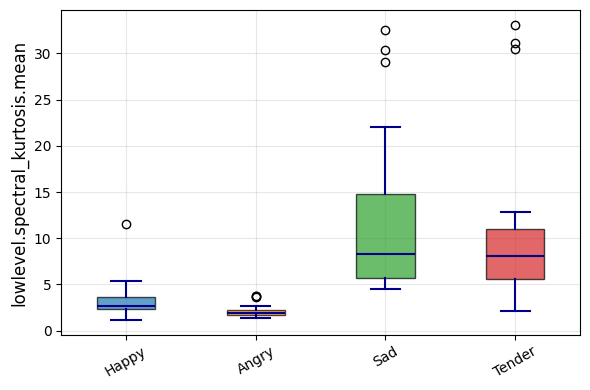


lowlevel.spectral_kurtosis.mean - group statistics (mean ± std) and bootstrap 95% CI:
  Happy: n=20, mean=3.2877, std=2.1535, 95%CI_mean=(2.5031, 4.3735)
  Angry: n=20, mean=2.1223, std=0.7584, 95%CI_mean=(1.7971, 2.4772)
  Sad: n=20, mean=12.3220, std=8.8584, 95%CI_mean=(8.6378, 16.5447)
  Tender: n=20, mean=11.1923, std=8.9286, 95%CI_mean=(7.6840, 15.4554)

Assumption checks:
  Shapiro Happy: p=0.0000
  Shapiro Angry: p=0.0014
  Shapiro Sad: p=0.0005
  Shapiro Tender: p=0.0001
  Levene (equal variances) p=0.0018

Kruskal-Wallis: H=53.2261, p=0.00000, (eta² (descr)=0.338)

-> lowlevel.spectral_kurtosis.stdev


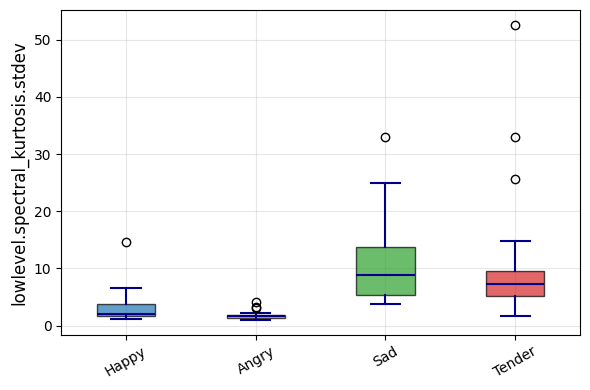


lowlevel.spectral_kurtosis.stdev - group statistics (mean ± std) and bootstrap 95% CI:
  Happy: n=20, mean=3.1999, std=2.9145, 95%CI_mean=(2.1598, 4.7053)
  Angry: n=20, mean=1.8331, std=0.7485, 95%CI_mean=(1.5393, 2.2137)
  Sad: n=20, mean=11.4719, std=7.8236, 95%CI_mean=(8.1729, 15.1847)
  Tender: n=20, mean=11.3410, std=11.9753, 95%CI_mean=(6.9038, 17.5294)

Assumption checks:
  Shapiro Happy: p=0.0000
  Shapiro Angry: p=0.0010
  Shapiro Sad: p=0.0025
  Shapiro Tender: p=0.0000
  Levene (equal variances) p=0.0083

Kruskal-Wallis: H=51.3935, p=0.00000, (eta² (descr)=0.272)

-> tonal.chords_number_rate


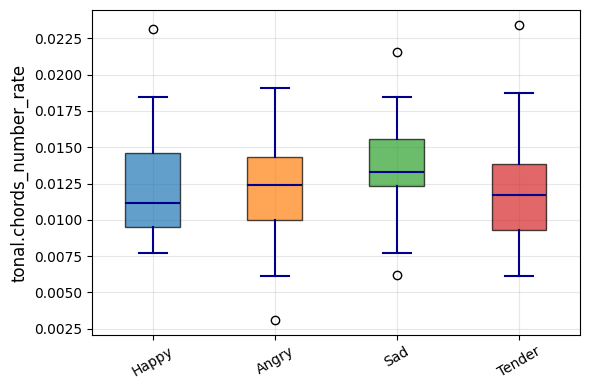


tonal.chords_number_rate - group statistics (mean ± std) and bootstrap 95% CI:
  Happy: n=20, mean=0.0126, std=0.0038, 95%CI_mean=(0.0110, 0.0143)
  Angry: n=20, mean=0.0120, std=0.0042, 95%CI_mean=(0.0102, 0.0138)
  Sad: n=20, mean=0.0134, std=0.0037, 95%CI_mean=(0.0118, 0.0151)
  Tender: n=20, mean=0.0119, std=0.0042, 95%CI_mean=(0.0101, 0.0139)

Assumption checks:
  Shapiro Happy: p=0.0162
  Shapiro Angry: p=0.6912
  Shapiro Sad: p=0.6559
  Shapiro Tender: p=0.1589
  Levene (equal variances) p=0.8854

Kruskal-Wallis: H=2.3342, p=0.50601, (eta² (descr)=0.022)

-> tonal.chords_changes_rate


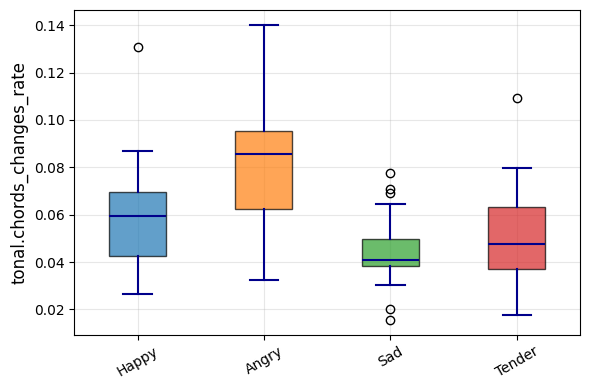


tonal.chords_changes_rate - group statistics (mean ± std) and bootstrap 95% CI:
  Happy: n=20, mean=0.0609, std=0.0237, 95%CI_mean=(0.0503, 0.0720)
  Angry: n=20, mean=0.0853, std=0.0274, 95%CI_mean=(0.0731, 0.0972)
  Sad: n=20, mean=0.0448, std=0.0158, 95%CI_mean=(0.0382, 0.0518)
  Tender: n=20, mean=0.0505, std=0.0214, 95%CI_mean=(0.0413, 0.0599)

Assumption checks:
  Shapiro Happy: p=0.1112
  Shapiro Angry: p=0.7741
  Shapiro Sad: p=0.1181
  Shapiro Tender: p=0.3754
  Levene (equal variances) p=0.2463

ANOVA: F=12.0623, p=0.00000, eta²=0.323

Tukey HSD post-hoc:
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
 Angry  Happy  -0.0243 0.0071 -0.0435 -0.0052   True
 Angry    Sad  -0.0405    0.0 -0.0597 -0.0214   True
 Angry Tender  -0.0348    0.0  -0.054 -0.0157   True
 Happy    Sad  -0.0162 0.1274 -0.0353   0.003  False
 Happy Tender  -0.0105 0.4793 -0.0297  0.0087  False
   

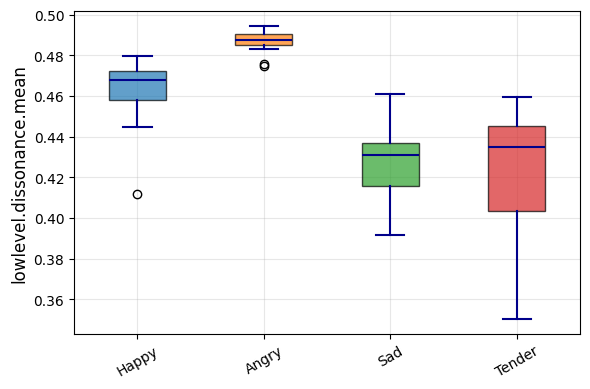


lowlevel.dissonance.mean - group statistics (mean ± std) and bootstrap 95% CI:
  Happy: n=20, mean=0.4631, std=0.0152, 95%CI_mean=(0.4558, 0.4695)
  Angry: n=20, mean=0.4869, std=0.0051, 95%CI_mean=(0.4845, 0.4890)
  Sad: n=20, mean=0.4270, std=0.0176, 95%CI_mean=(0.4190, 0.4344)
  Tender: n=20, mean=0.4240, std=0.0273, 95%CI_mean=(0.4113, 0.4351)

Assumption checks:
  Shapiro Happy: p=0.0012
  Shapiro Angry: p=0.1216
  Shapiro Sad: p=0.7686
  Shapiro Tender: p=0.0645
  Levene (equal variances) p=0.0008

Kruskal-Wallis: H=60.6678, p=0.00000, (eta² (descr)=0.676)

-> lowlevel.dissonance.stdev


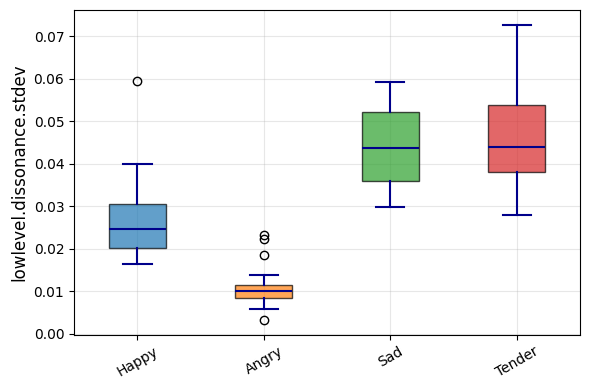


lowlevel.dissonance.stdev - group statistics (mean ± std) and bootstrap 95% CI:
  Happy: n=20, mean=0.0273, std=0.0101, 95%CI_mean=(0.0230, 0.0321)
  Angry: n=20, mean=0.0110, std=0.0050, 95%CI_mean=(0.0090, 0.0135)
  Sad: n=20, mean=0.0440, std=0.0093, 95%CI_mean=(0.0401, 0.0484)
  Tender: n=20, mean=0.0458, std=0.0121, 95%CI_mean=(0.0406, 0.0512)

Assumption checks:
  Shapiro Happy: p=0.0074
  Shapiro Angry: p=0.0071
  Shapiro Sad: p=0.2223
  Shapiro Tender: p=0.3094
  Levene (equal variances) p=0.0147

Kruskal-Wallis: H=56.5994, p=0.00000, (eta² (descr)=0.689)

-> lowlevel.average_loudness


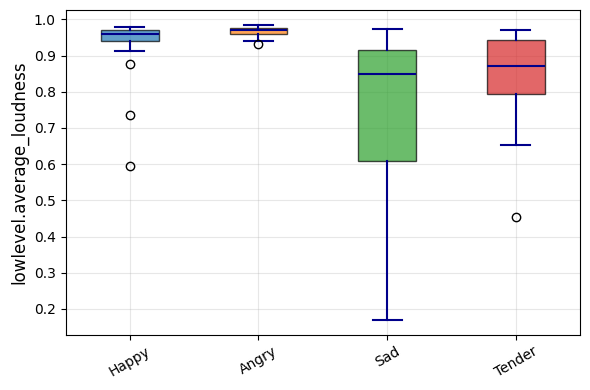


lowlevel.average_loudness - group statistics (mean ± std) and bootstrap 95% CI:
  Happy: n=20, mean=0.9253, std=0.0929, 95%CI_mean=(0.8793, 0.9586)
  Angry: n=20, mean=0.9676, std=0.0132, 95%CI_mean=(0.9613, 0.9729)
  Sad: n=20, mean=0.7466, std=0.2269, 95%CI_mean=(0.6424, 0.8400)
  Tender: n=20, mean=0.8340, std=0.1353, 95%CI_mean=(0.7712, 0.8934)

Assumption checks:
  Shapiro Happy: p=0.0000
  Shapiro Angry: p=0.0254
  Shapiro Sad: p=0.0057
  Shapiro Tender: p=0.0036
  Levene (equal variances) p=0.0001

Kruskal-Wallis: H=35.7246, p=0.00000, (eta² (descr)=0.270)

-> lowlevel.pitch_salience.mean


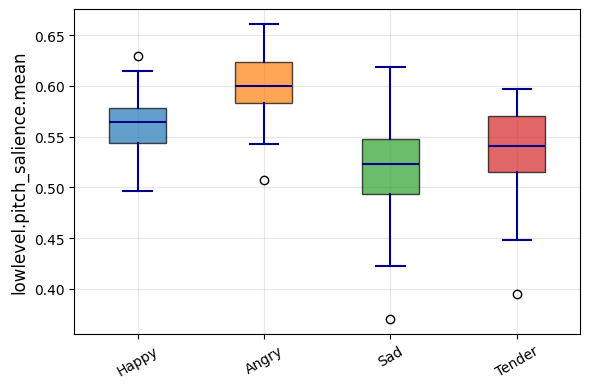


lowlevel.pitch_salience.mean - group statistics (mean ± std) and bootstrap 95% CI:
  Happy: n=20, mean=0.5606, std=0.0334, 95%CI_mean=(0.5461, 0.5752)
  Angry: n=20, mean=0.5991, std=0.0372, 95%CI_mean=(0.5823, 0.6145)
  Sad: n=20, mean=0.5141, std=0.0551, 95%CI_mean=(0.4895, 0.5374)
  Tender: n=20, mean=0.5323, std=0.0473, 95%CI_mean=(0.5093, 0.5503)

Assumption checks:
  Shapiro Happy: p=0.4737
  Shapiro Angry: p=0.7820
  Shapiro Sad: p=0.2158
  Shapiro Tender: p=0.0414
  Levene (equal variances) p=0.4230

Kruskal-Wallis: H=29.4180, p=0.00000, (eta² (descr)=0.347)

-> lowlevel.pitch_salience.stdev


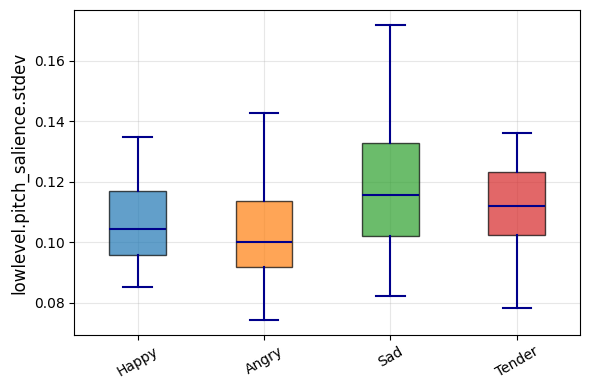


lowlevel.pitch_salience.stdev - group statistics (mean ± std) and bootstrap 95% CI:
  Happy: n=20, mean=0.1071, std=0.0143, 95%CI_mean=(0.1007, 0.1138)
  Angry: n=20, mean=0.1030, std=0.0168, 95%CI_mean=(0.0964, 0.1105)
  Sad: n=20, mean=0.1187, std=0.0240, 95%CI_mean=(0.1087, 0.1300)
  Tender: n=20, mean=0.1113, std=0.0168, 95%CI_mean=(0.1038, 0.1183)

Assumption checks:
  Shapiro Happy: p=0.2277
  Shapiro Angry: p=0.2361
  Shapiro Sad: p=0.2225
  Shapiro Tender: p=0.3112
  Levene (equal variances) p=0.1472

ANOVA: F=2.5596, p=0.06120, eta²=0.092

-> rhythm.onset_rate


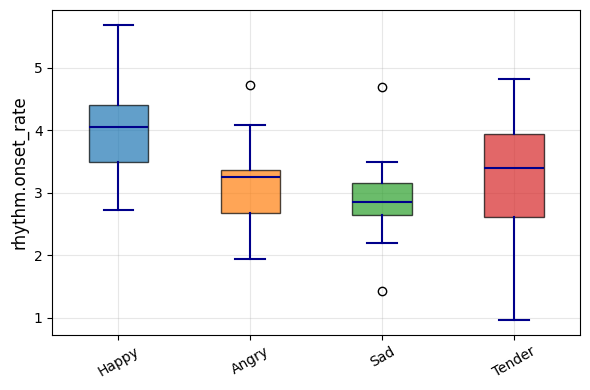


rhythm.onset_rate - group statistics (mean ± std) and bootstrap 95% CI:
  Happy: n=20, mean=4.0760, std=0.7371, 95%CI_mean=(3.7635, 4.3945)
  Angry: n=20, mean=3.1636, std=0.6428, 95%CI_mean=(2.8912, 3.4446)
  Sad: n=20, mean=2.8781, std=0.6159, 95%CI_mean=(2.6114, 3.1532)
  Tender: n=20, mean=3.3124, std=0.9290, 95%CI_mean=(2.8773, 3.7015)

Assumption checks:
  Shapiro Happy: p=0.7978
  Shapiro Angry: p=0.2598
  Shapiro Sad: p=0.0854
  Shapiro Tender: p=0.5523
  Levene (equal variances) p=0.1692

ANOVA: F=9.0523, p=0.00003, eta²=0.263

Tukey HSD post-hoc:
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
 Angry  Happy   0.9124 0.0017  0.2805  1.5443   True
 Angry    Sad  -0.2856 0.6368 -0.9175  0.3463  False
 Angry Tender   0.1488 0.9259 -0.4831  0.7807  False
 Happy    Sad   -1.198    0.0 -1.8299 -0.5661   True
 Happy Tender  -0.7636 0.0114 -1.3955 -0.1317   True
   Sad Tende

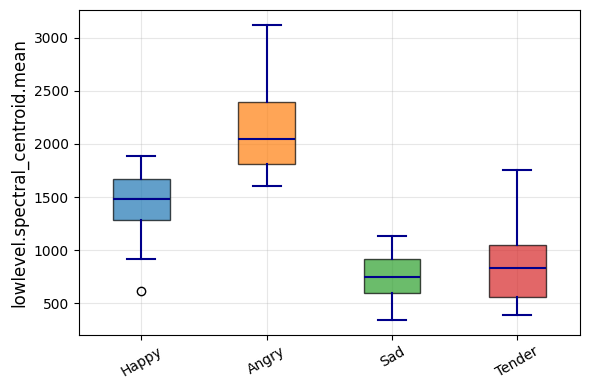


lowlevel.spectral_centroid.mean - group statistics (mean ± std) and bootstrap 95% CI:
  Happy: n=20, mean=1432.6819, std=346.1445, 95%CI_mean=(1272.4369, 1580.5883)
  Angry: n=20, mean=2141.6944, std=416.9924, 95%CI_mean=(1966.9063, 2325.3968)
  Sad: n=20, mean=758.8759, std=194.1389, 95%CI_mean=(667.3752, 844.2511)
  Tender: n=20, mean=844.9171, std=343.7572, 95%CI_mean=(702.8455, 1004.6602)

Assumption checks:
  Shapiro Happy: p=0.1975
  Shapiro Angry: p=0.2041
  Shapiro Sad: p=0.7667
  Shapiro Tender: p=0.2267
  Levene (equal variances) p=0.0686

ANOVA: F=69.0788, p=0.00000, eta²=0.732

Tukey HSD post-hoc:
    Multiple Comparison of Means - Tukey HSD, FWER=0.05     
group1 group2  meandiff  p-adj    lower      upper    reject
------------------------------------------------------------
 Angry  Happy  -709.0125    0.0  -994.7237  -423.3012   True
 Angry    Sad -1382.8185    0.0 -1668.5297 -1097.1072   True
 Angry Tender -1296.7773    0.0 -1582.4885  -1011.066   True
 Happy    Sad   

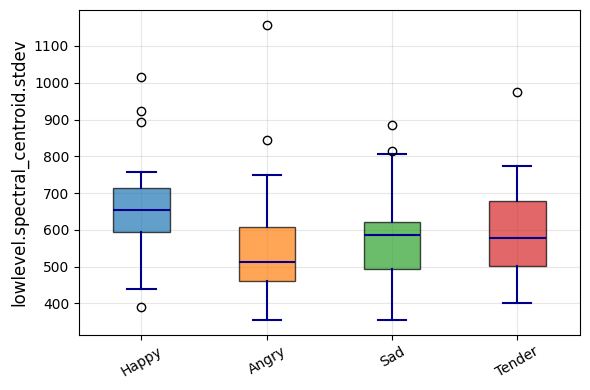


lowlevel.spectral_centroid.stdev - group statistics (mean ± std) and bootstrap 95% CI:
  Happy: n=20, mean=667.2381, std=149.8182, 95%CI_mean=(606.4749, 732.8724)
  Angry: n=20, mean=567.6715, std=178.2872, 95%CI_mean=(500.6592, 659.2371)
  Sad: n=20, mean=579.8673, std=139.9494, 95%CI_mean=(519.4513, 645.6070)
  Tender: n=20, mean=599.8349, std=137.2388, 95%CI_mean=(541.1895, 661.9144)

Assumption checks:
  Shapiro Happy: p=0.4017
  Shapiro Angry: p=0.0018
  Shapiro Sad: p=0.3832
  Shapiro Tender: p=0.3173
  Levene (equal variances) p=0.9807

Kruskal-Wallis: H=7.1237, p=0.06806, (eta² (descr)=0.060)

-> tonal.hpcp_entropy.mean


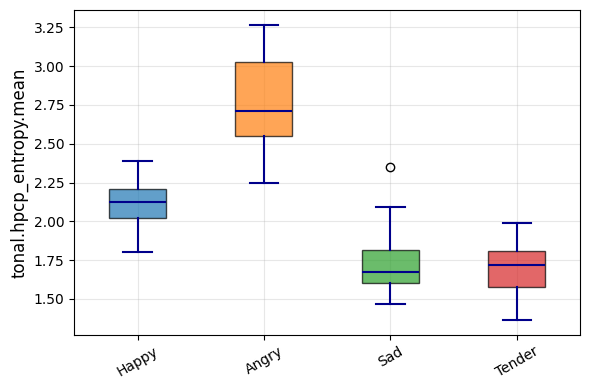


tonal.hpcp_entropy.mean - group statistics (mean ± std) and bootstrap 95% CI:
  Happy: n=20, mean=2.0976, std=0.1582, 95%CI_mean=(2.0273, 2.1653)
  Angry: n=20, mean=2.7461, std=0.2978, 95%CI_mean=(2.6097, 2.8773)
  Sad: n=20, mean=1.7418, std=0.2202, 95%CI_mean=(1.6486, 1.8407)
  Tender: n=20, mean=1.6971, std=0.1565, 95%CI_mean=(1.6292, 1.7626)

Assumption checks:
  Shapiro Happy: p=0.2129
  Shapiro Angry: p=0.3926
  Shapiro Sad: p=0.0111
  Shapiro Tender: p=0.9696
  Levene (equal variances) p=0.0100

Kruskal-Wallis: H=60.2150, p=0.00000, (eta² (descr)=0.791)

-> tonal.hpcp_entropy.stdev


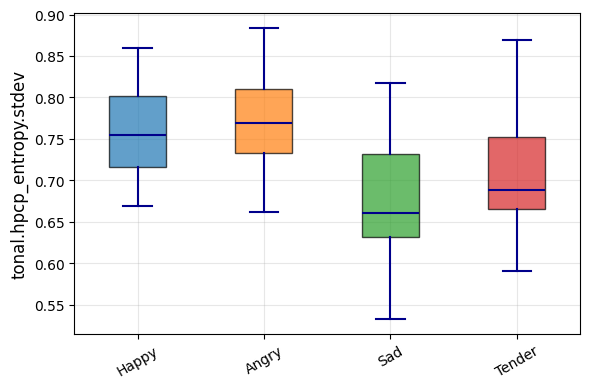


tonal.hpcp_entropy.stdev - group statistics (mean ± std) and bootstrap 95% CI:
  Happy: n=20, mean=0.7597, std=0.0531, 95%CI_mean=(0.7367, 0.7833)
  Angry: n=20, mean=0.7689, std=0.0544, 95%CI_mean=(0.7456, 0.7922)
  Sad: n=20, mean=0.6769, std=0.0700, 95%CI_mean=(0.6478, 0.7080)
  Tender: n=20, mean=0.7029, std=0.0674, 95%CI_mean=(0.6737, 0.7320)

Assumption checks:
  Shapiro Happy: p=0.8004
  Shapiro Angry: p=0.9715
  Shapiro Sad: p=0.7438
  Shapiro Tender: p=0.4444
  Levene (equal variances) p=0.6971

ANOVA: F=9.8465, p=0.00001, eta²=0.280

Tukey HSD post-hoc:
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
 Angry  Happy  -0.0092 0.9675 -0.0618  0.0434  False
 Angry    Sad   -0.092 0.0001 -0.1446 -0.0394   True
 Angry Tender  -0.0659  0.008 -0.1185 -0.0134   True
 Happy    Sad  -0.0828 0.0005 -0.1354 -0.0302   True
 Happy Tender  -0.0567 0.0293 -0.1093 -0.0042   True
   Sa

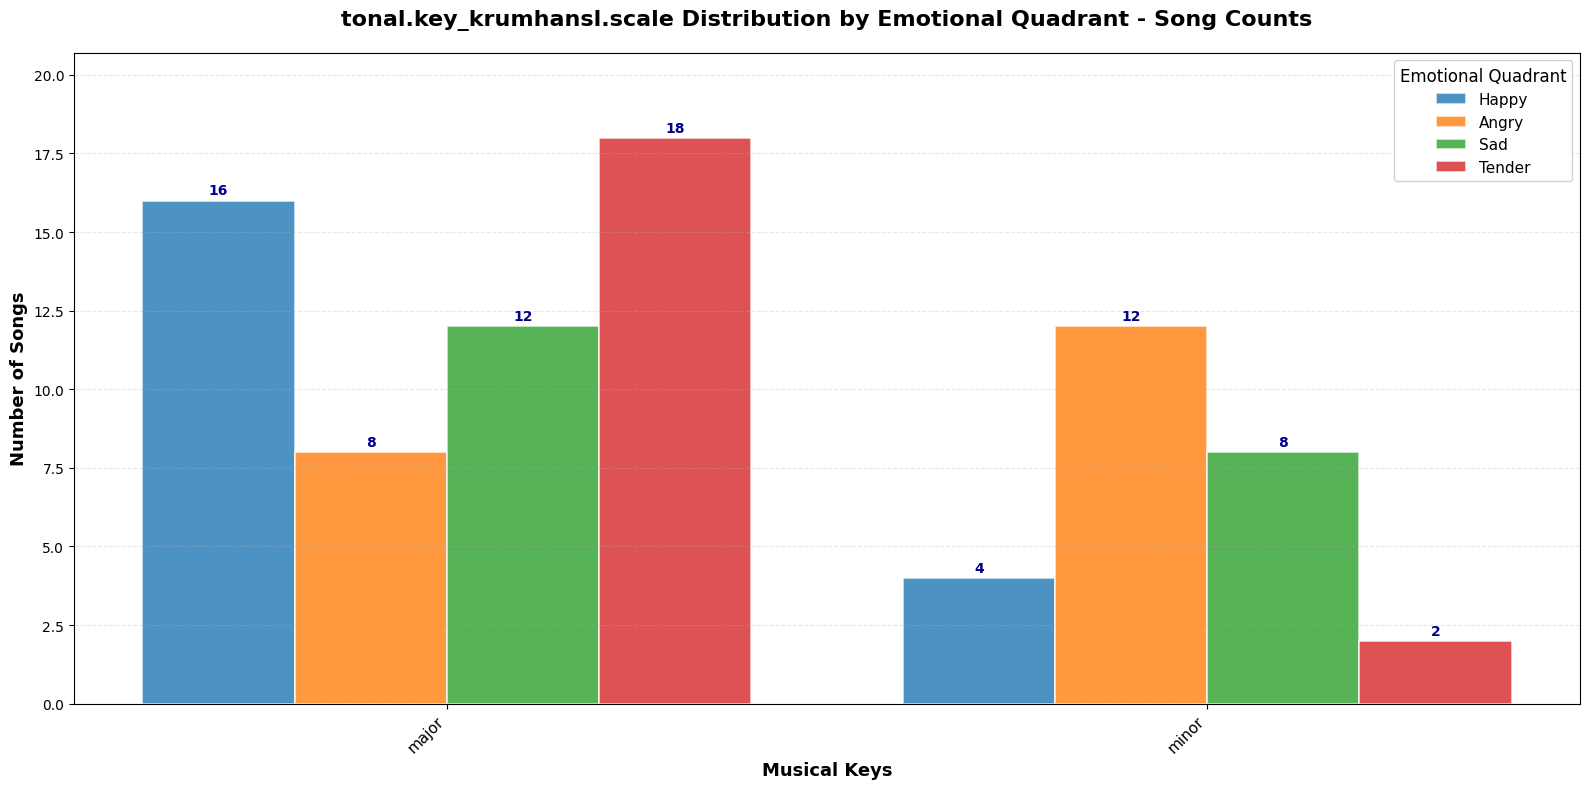

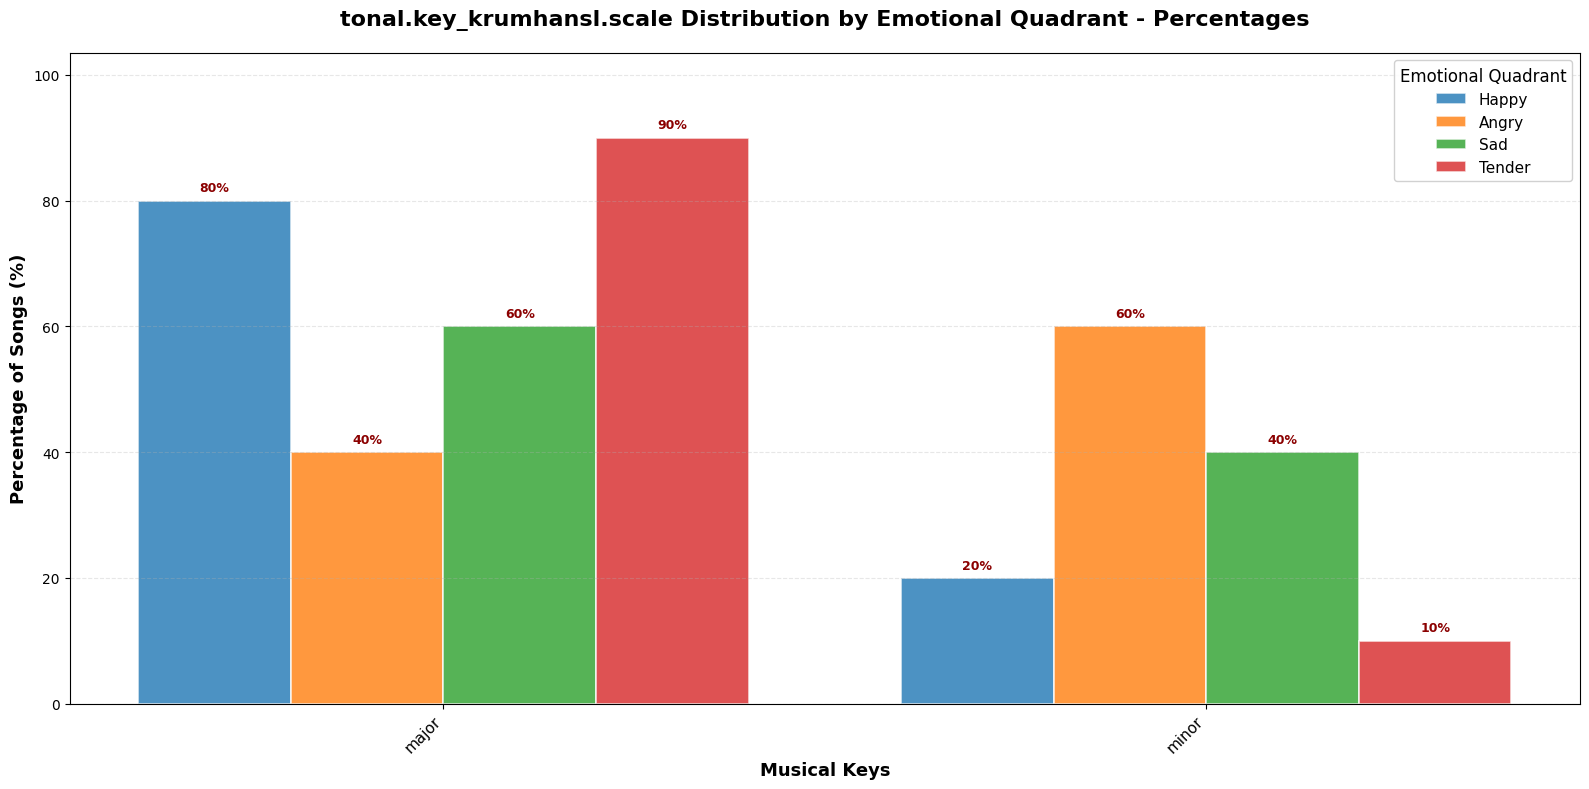

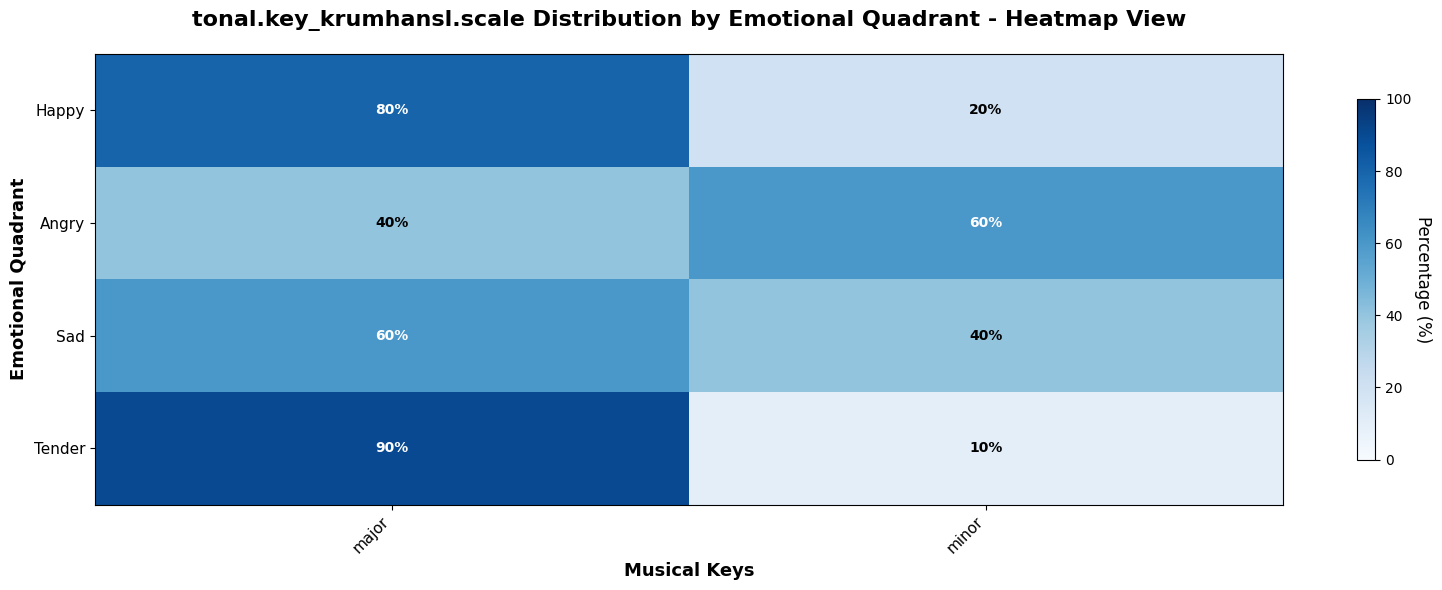

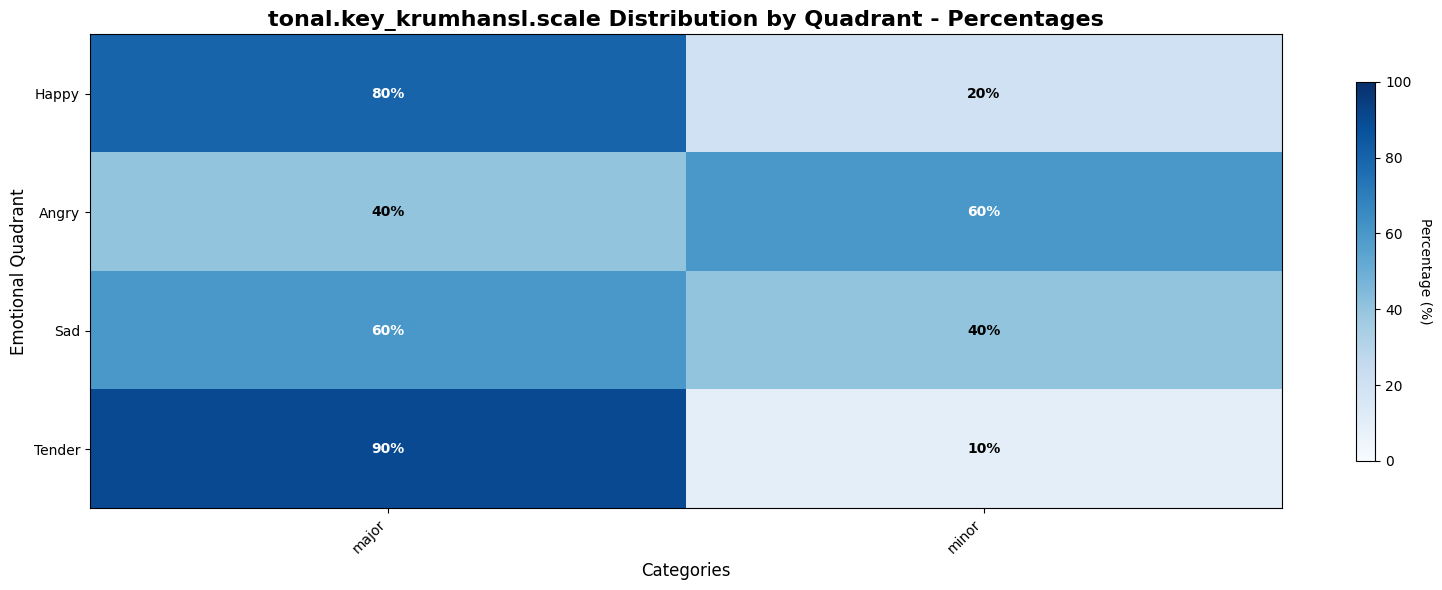

Chi2=13.447, p=0.00376, dof=3
→ Significant association (p < 0.05)

Detailed tonal.key_krumhansl.scale Distribution:
------------------------------------------------------------

Happy:
  major: 16 songs (80.0%)
  minor: 4 songs (20.0%)

Angry:
  minor: 12 songs (60.0%)
  major: 8 songs (40.0%)

Sad:
  major: 12 songs (60.0%)
  minor: 8 songs (40.0%)

Tender:
  major: 18 songs (90.0%)
  minor: 2 songs (10.0%)

-> tonal.chords_key
Using actual keys from dataset: ['A', 'Ab', 'B', 'Bb', 'C', 'C#', 'D', 'E', 'Eb', 'F', 'F#', 'G']


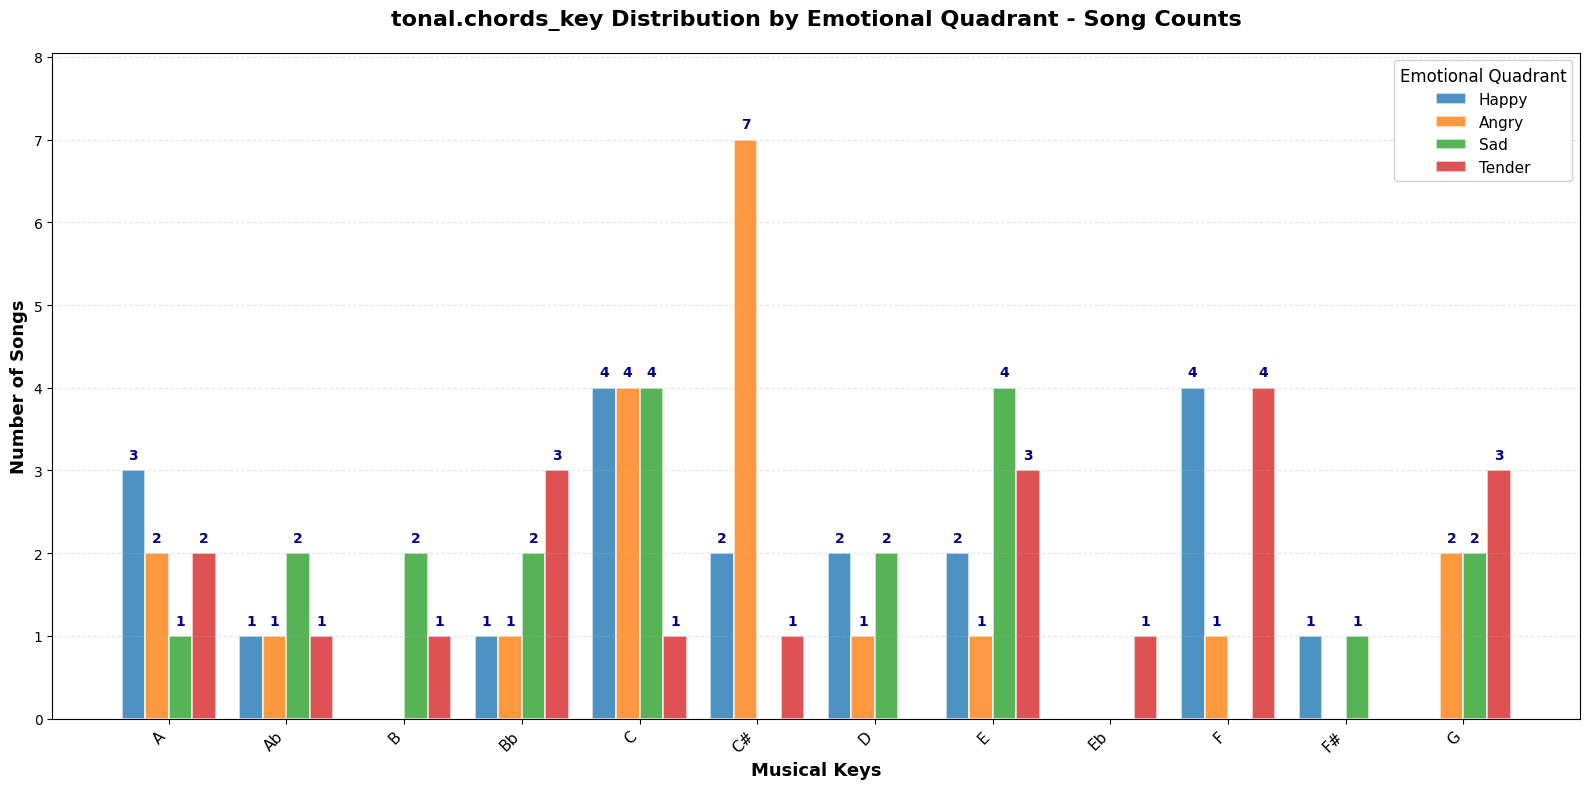

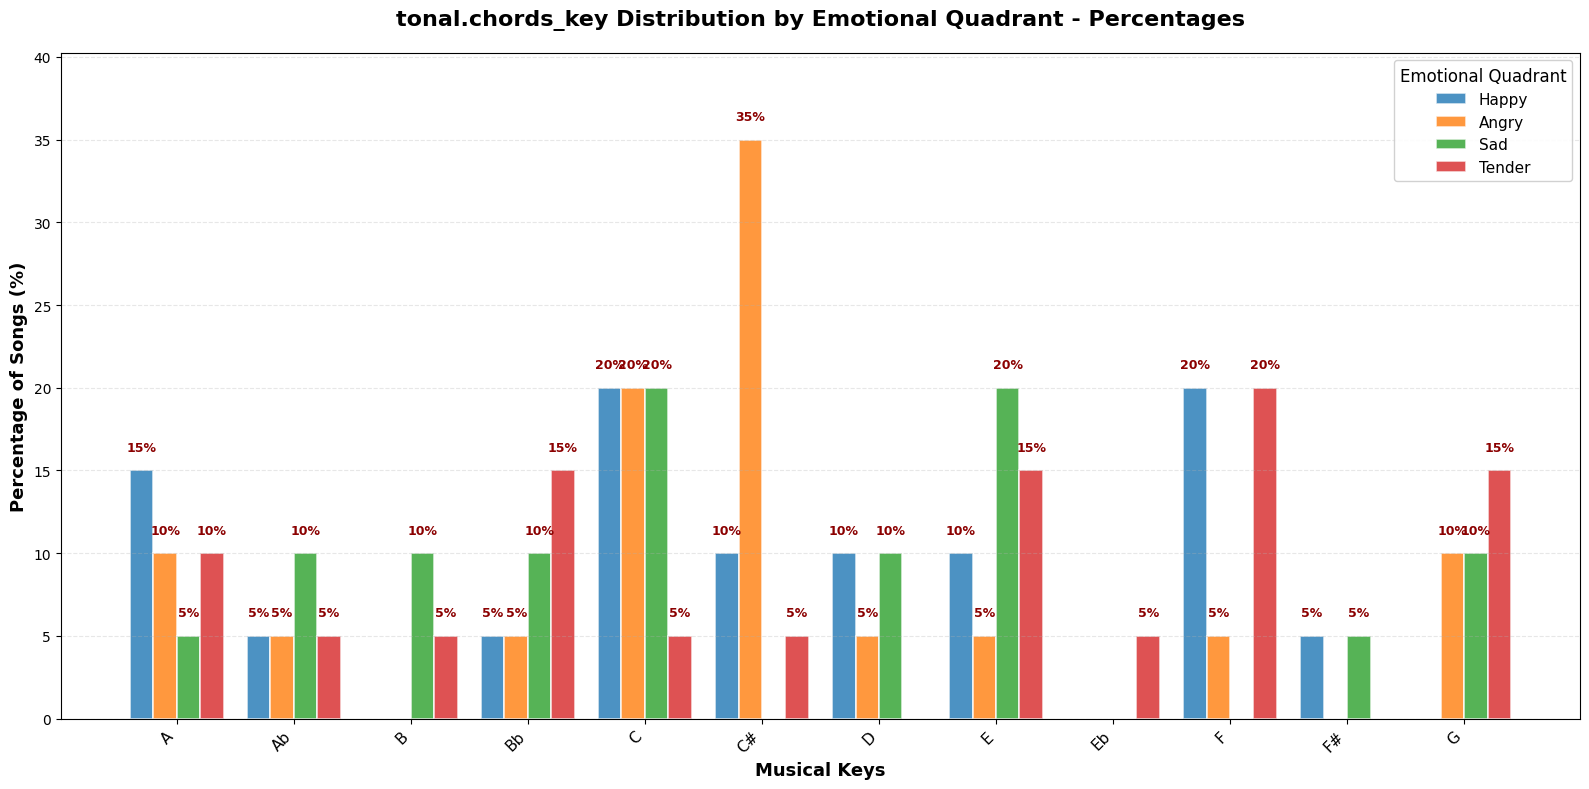

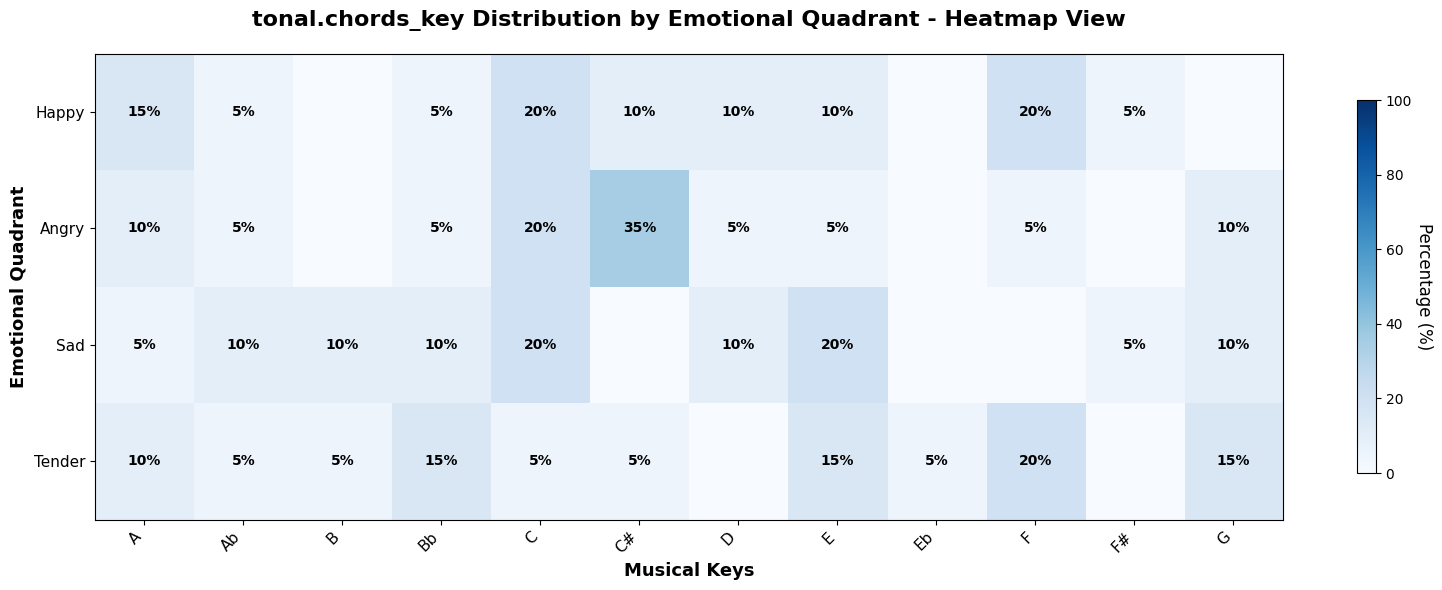

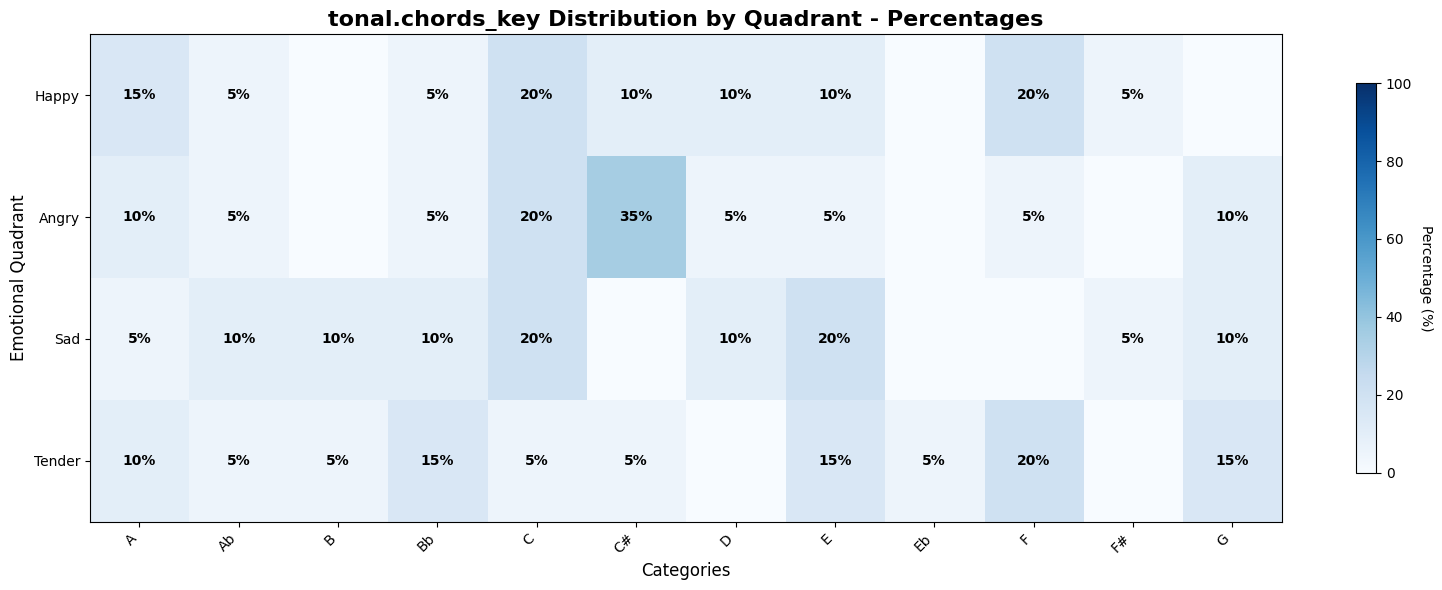

Chi2=38.096, p=0.24864, dof=33
→ No significant association (p >= 0.05)

Detailed tonal.chords_key Distribution:
------------------------------------------------------------

Happy:
  C: 4 songs (20.0%)
  F: 4 songs (20.0%)
  A: 3 songs (15.0%)
  C#: 2 songs (10.0%)
  D: 2 songs (10.0%)
  E: 2 songs (10.0%)
  Ab: 1 songs (5.0%)
  Bb: 1 songs (5.0%)
  F#: 1 songs (5.0%)

Angry:
  C#: 7 songs (35.0%)
  C: 4 songs (20.0%)
  A: 2 songs (10.0%)
  G: 2 songs (10.0%)
  Ab: 1 songs (5.0%)
  Bb: 1 songs (5.0%)
  D: 1 songs (5.0%)
  E: 1 songs (5.0%)
  F: 1 songs (5.0%)

Sad:
  C: 4 songs (20.0%)
  E: 4 songs (20.0%)
  Ab: 2 songs (10.0%)
  B: 2 songs (10.0%)
  Bb: 2 songs (10.0%)
  D: 2 songs (10.0%)
  G: 2 songs (10.0%)
  A: 1 songs (5.0%)
  F#: 1 songs (5.0%)

Tender:
  F: 4 songs (20.0%)
  Bb: 3 songs (15.0%)
  E: 3 songs (15.0%)
  G: 3 songs (15.0%)
  A: 2 songs (10.0%)
  Ab: 1 songs (5.0%)
  B: 1 songs (5.0%)
  C: 1 songs (5.0%)
  C#: 1 songs (5.0%)
  Eb: 1 songs (5.0%)

Applying Benjamini

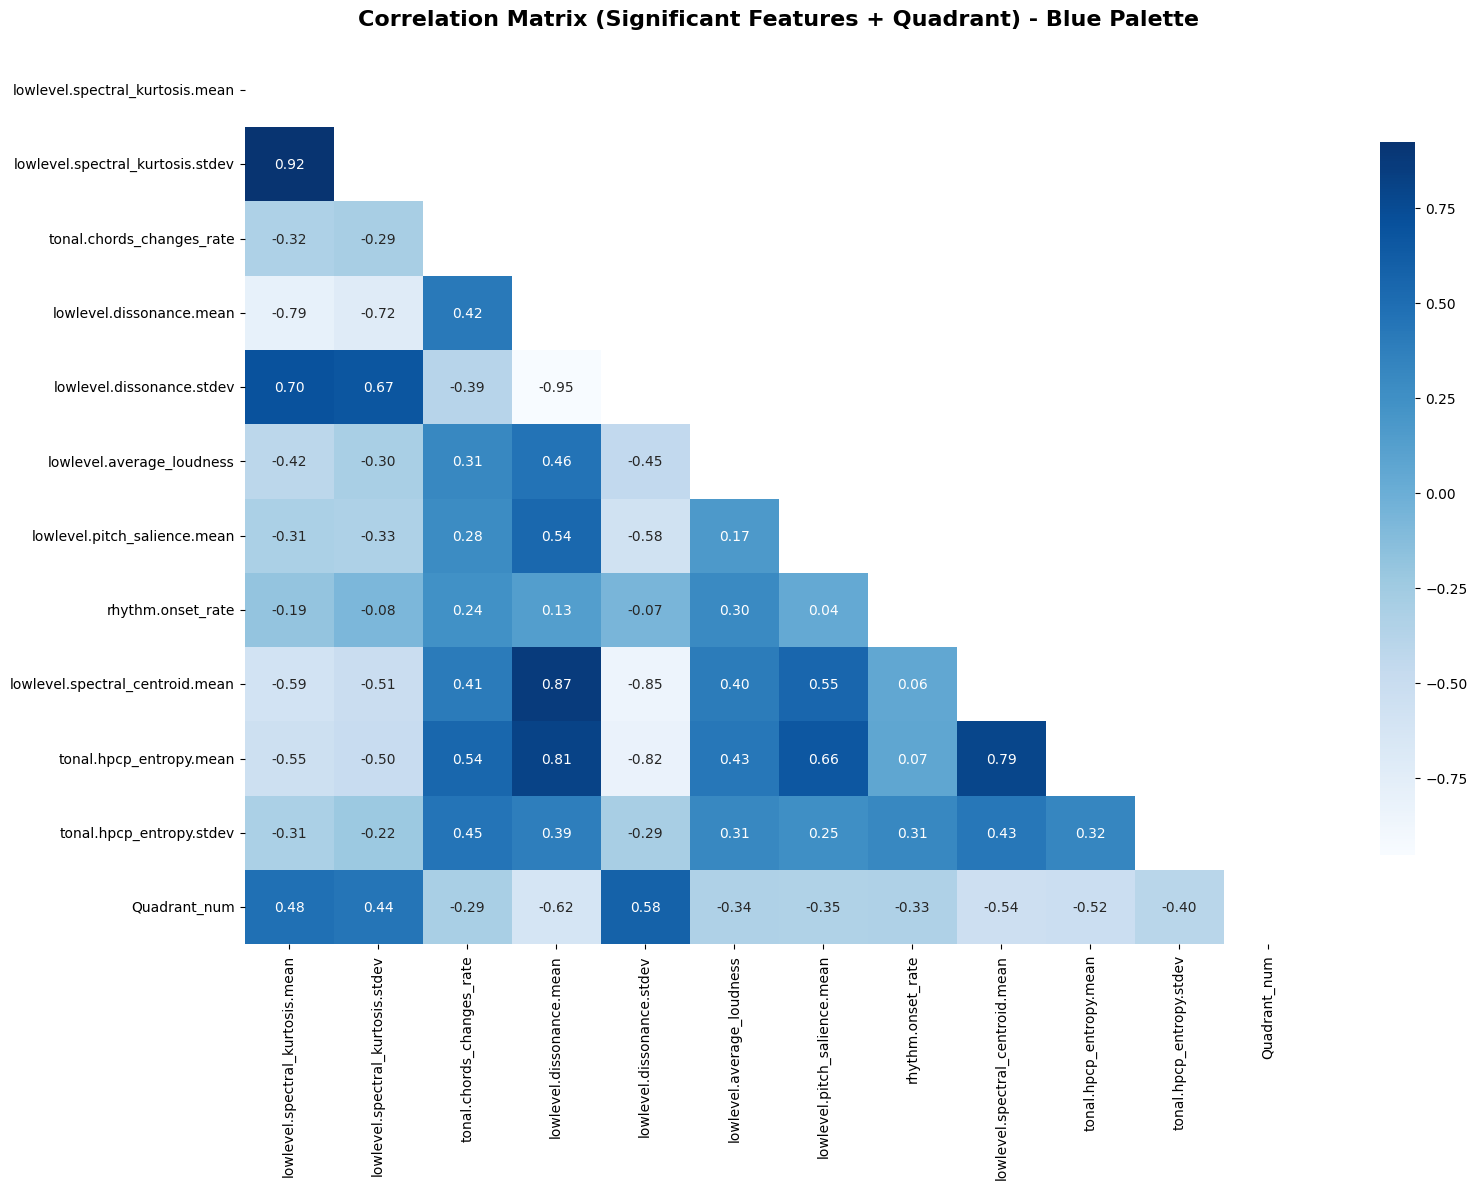


Top correlated features with Quadrant_num:
lowlevel.dissonance.mean            0.622743
lowlevel.dissonance.stdev           0.581922
lowlevel.spectral_centroid.mean     0.543499
tonal.hpcp_entropy.mean             0.522408
lowlevel.spectral_kurtosis.mean     0.482843
lowlevel.spectral_kurtosis.stdev    0.444470
tonal.hpcp_entropy.stdev            0.403399
lowlevel.pitch_salience.mean        0.348704
lowlevel.average_loudness           0.337197
rhythm.onset_rate                   0.333466

Running 4-fold cross-validation on features: ['lowlevel.spectral_kurtosis.mean', 'lowlevel.spectral_kurtosis.stdev', 'tonal.chords_changes_rate', 'lowlevel.dissonance.mean', 'lowlevel.dissonance.stdev', 'lowlevel.average_loudness', 'lowlevel.pitch_salience.mean', 'rhythm.onset_rate', 'lowlevel.spectral_centroid.mean', 'tonal.hpcp_entropy.mean', 'tonal.hpcp_entropy.stdev']
LogisticRegression accuracy: mean=0.650, std=0.050
RandomForest accuracy:       mean=0.700, std=0.071

Classifier results: {'logis

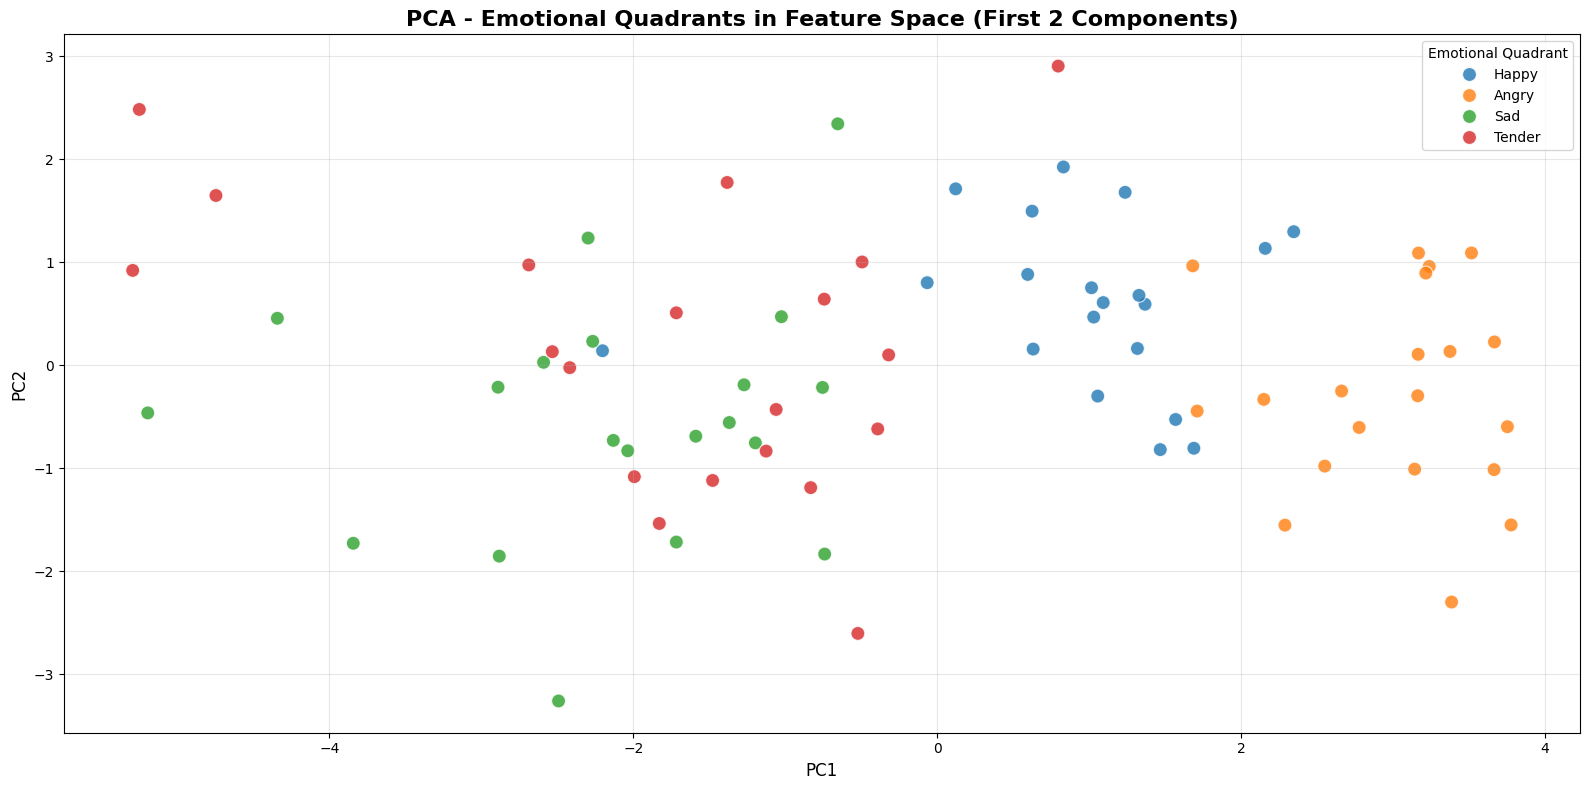

Explained variance ratio (first 2): [0.52645539 0.1262904 ]
Detected 8 outlier rows with |z| > 3.0.

Sample outliers (first 10):
   Quadrant  lowlevel.spectral_kurtosis.mean  lowlevel.spectral_kurtosis.stdev  tonal.chords_changes_rate  lowlevel.dissonance.mean  lowlevel.dissonance.stdev  lowlevel.average_loudness  lowlevel.pitch_salience.mean  rhythm.onset_rate  lowlevel.spectral_centroid.mean  tonal.hpcp_entropy.mean  tonal.hpcp_entropy.stdev
43       Q3                         6.561217                          4.912872                   0.040062                  0.415389                   0.052099                   0.919409                      0.370260           2.692689                       581.223022                 1.529314                  0.633706
45       Q3                        30.366400                         33.046497                   0.038640                  0.391664                   0.052628                   0.606747                      0.501545           2.86664

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import chi2_contingency, kruskal, levene, shapiro
from sklearn.utils import resample
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.multitest import multipletests

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.decomposition import PCA

from typing import List, Dict, Tuple


class EmotionalQuadrantAnalyzer:
    """
    Enhanced analyzer for musical features across emotional quadrants.
    Now with blue color palette and full-width individual plots.
    """

    def __init__(self, df: pd.DataFrame, random_state: int = 42):
        self.df = df.copy()
        self.random_state = random_state
        self.balanced_df: pd.DataFrame = None
        self.available_features: List[str] = []
        self.significant_features: List[str] = []
        self.anova_results: Dict[str, float] = {}
        self.kruskal_results: Dict[str, float] = {}
        self.pvals_for_fdr: Dict[str, float] = {}

        # Feature lists (same as your original)
        self.relevant_features = [
            "rhythm.bpm",
            "lowlevel.spectral_kurtosis.mean",
            "lowlevel.spectral_kurtosis.stdev",
            "tonal.chords_number_rate",
            "tonal.chords_changes_rate",
            "lowlevel.dissonance.mean",
            "lowlevel.dissonance.stdev",
            "lowlevel.average_loudness",
            "lowlevel.pitch_salience.mean",
            "lowlevel.pitch_salience.stdev",
            "rhythm.onset_rate",
            "lowlevel.spectral_centroid.mean",
            "lowlevel.spectral_centroid.stdev",
            "tonal.hpcp_entropy.mean",
            "tonal.hpcp_entropy.stdev",
            "tonal.key_krumhansl.scale",
            "tonal.chords_key",
        ]
        self.categorical_features = ["tonal.key_krumhansl.scale", "tonal.chords_key"]

        # Labels + BLUE plotting colors
        self.quadrant_labels = {"Q1": "Happy", "Q2": "Angry", "Q3": "Sad", "Q4": "Tender"}
        self.quadrant_colors = {
            "Q1": "#1f77b4",  # Blue
            "Q2": "#ff7f0e",  # Orange (kept for contrast, but you can change to blue shade)
            "Q3": "#2ca02c",  # Green (kept for contrast, but you can change to blue shade)
            "Q4": "#d62728"   # Red (kept for contrast, but you can change to blue shade)
        }

        # Blue palette for heatmaps
        self.blue_palettes = {
            "light": sns.light_palette("#1f77b4", as_cmap=True),
            "medium": sns.color_palette("Blues", as_cmap=True),
            "dark": sns.dark_palette("#1f77b4", as_cmap=True)
        }

        # Will be populated dynamically based on actual data
        self.actual_keys_in_data: List[str] = []

    def _detect_actual_keys(self):
        """Dynamically detect which keys actually exist in the dataset"""
        if 'tonal.chords_key' in self.df.columns:
            self.actual_keys_in_data = sorted(self.df['tonal.chords_key'].dropna().unique())
            print(f"Detected keys in dataset: {self.actual_keys_in_data}")
        else:
            self.actual_keys_in_data = []
            print("No 'tonal.chords_key' column found in dataset")

    # ---------------------------
    # Data preparation utilities
    # ---------------------------
    def prepare_balanced_data(self, method: str = "downsample") -> pd.DataFrame:
        """
        Balance the dataset across quadrants.
        method: 'downsample' (default) or 'upsample'
        """
        print("Preparing balanced dataset...")

        # First detect actual keys in the data
        self._detect_actual_keys()

        quadrant_counts = self.df["Quadrant"].value_counts()
        print("Original sample sizes:")
        for q, c in quadrant_counts.items():
            print(f"  {self.quadrant_labels.get(q, q)} ({q}): {c}")

        min_samples = int(quadrant_counts.min())
        max_samples = int(quadrant_counts.max())
        target = min_samples if method == "downsample" else max_samples
        print(f"\nBalancing using method='{method}' to {target} samples per quadrant")

        balanced_parts = []
        for q in ["Q1", "Q2", "Q3", "Q4"]:
            part = self.df[self.df["Quadrant"] == q]
            if part.empty:
                continue
            if method == "downsample":
                if len(part) > target:
                    part = resample(part, replace=False, n_samples=target, random_state=self.random_state)
            else:  # upsample
                if len(part) < target:
                    part = resample(part, replace=True, n_samples=target, random_state=self.random_state)
            balanced_parts.append(part)

        self.balanced_df = pd.concat(balanced_parts, ignore_index=True)
        print("\nBalanced dataset sample sizes:")
        for q, c in self.balanced_df["Quadrant"].value_counts().items():
            print(f"  {self.quadrant_labels.get(q, q)} ({q}): {c}")
        return self.balanced_df

    def check_available_features(self) -> List[str]:
        self.available_features = [f for f in self.relevant_features if f in self.df.columns]
        print("\nAvailable features for analysis:")
        for f in self.available_features:
            print(f"✓ {f}")
        print(f"\nTotal available: {len(self.available_features)} / {len(self.relevant_features)}")
        return self.available_features

    # ---------------------------
    # Enhanced Categorical Analysis with Blue Palette
    # ---------------------------
    def analyze_categorical_feature(self, feature_name: str, data: pd.DataFrame) -> bool:
        """Enhanced categorical analysis with blue color palette"""
        if feature_name not in data.columns:
            print(f"Feature '{feature_name}' not found.")
            return False

        quadrant_counts = {}
        for q in ["Q1", "Q2", "Q3", "Q4"]:
            vals = data[data["Quadrant"] == q][feature_name].dropna()
            if len(vals) > 0:
                quadrant_counts[self.quadrant_labels[q]] = vals.value_counts()

        if not quadrant_counts:
            print("No counts to analyze.")
            return False

        # For tonal.chords_key, use only keys that actually exist in the dataset
        if feature_name == "tonal.chords_key" and self.actual_keys_in_data:
            categories = self.actual_keys_in_data
            print(f"Using actual keys from dataset: {categories}")
        else:
            # For other categorical features (like scale), use all categories that appear
            categories = sorted({cat for counts in quadrant_counts.values() for cat in counts.index})

        # Build contingency table using only actual categories
        table = []
        for lab in ["Happy", "Angry", "Sad", "Tender"]:
            counts = quadrant_counts.get(lab, pd.Series(dtype=int))
            row = [int(counts.get(cat, 0)) for cat in categories]
            table.append(row)
        table = np.array(table)

        # Enhanced visualization with individual full-width plots
        self._plot_enhanced_categorical_individual(feature_name, categories, table, quadrant_counts)

        # Chi-square test
        try:
            chi2, p, dof, expected = chi2_contingency(table)
            print(f"Chi2={chi2:.3f}, p={p:.5f}, dof={dof}")
            self.pvals_for_fdr[feature_name] = p
            significant = p < 0.05
            if not significant:
                print("→ No significant association (p >= 0.05)")
            else:
                print("→ Significant association (p < 0.05)")

            # Print detailed key distribution
            self._print_detailed_key_distribution(feature_name, categories, table, quadrant_counts)

        except Exception as e:
            print("Chi-square failed:", e)
            significant = False

        print("=" * 70)
        return bool(significant)



    def _plot_enhanced_categorical_individual(self, feature_name: str, categories: List, table: np.ndarray, quadrant_counts: Dict):
        """Create enhanced visualizations for categorical features with grouped vertical bars"""

        # Plot 1: Grouped bar chart - FULL WIDTH
        plt.figure(figsize=(16, 8))

        # Set up the bar positions
        x = np.arange(len(categories))
        width = 0.2  # Width of each bar
        emotions = ["Happy", "Angry", "Sad", "Tender"]

        # Create bars for each emotion group
        for i, emotion in enumerate(emotions):
            row = table[i]
            positions = x + (i - 1.5) * width  # Center the groups
            plt.bar(positions, row, width, label=emotion, alpha=0.8,
                   color=self.quadrant_colors[f"Q{i+1}"],
                   edgecolor='white', linewidth=1.2)

        # Customize the plot
        plt.xticks(x, categories, rotation=45, ha='right', fontsize=11)
        plt.legend(title='Emotional Quadrant', title_fontsize=12, fontsize=11,
                  loc='upper right', framealpha=0.9)
        plt.title(f'{feature_name} Distribution by Emotional Quadrant - Song Counts',
                 fontsize=16, fontweight='bold', pad=20)
        plt.ylabel('Number of Songs', fontsize=13, fontweight='bold')
        plt.xlabel('Musical Keys', fontsize=13, fontweight='bold')
        plt.grid(axis='y', alpha=0.3, linestyle='--')

        # Add value labels on top of bars
        for i, emotion in enumerate(emotions):
            row = table[i]
            positions = x + (i - 1.5) * width
            for j, (pos, value) in enumerate(zip(positions, row)):
                if value > 0:  # Only label non-zero values
                    plt.text(pos, value + 0.1, str(value),
                            ha='center', va='bottom', fontweight='bold', fontsize=10,
                            color='darkblue')

        # Adjust y-axis to accommodate labels
        max_value = np.max(table)
        plt.ylim(0, max_value * 1.15)

        plt.tight_layout()
        plt.show()

        # Plot 2: Percentage grouped bar chart - FULL WIDTH
        plt.figure(figsize=(16, 8))

        # Calculate percentages
        percentages = []
        for i, emotion in enumerate(emotions):
            row = table[i]
            total = row.sum()
            if total > 0:
                pct_row = [((val / total) * 100) if total > 0 else 0 for val in row]
            else:
                pct_row = [0] * len(row)
            percentages.append(pct_row)

        percentages = np.array(percentages)

        # Create bars for each emotion group (percentages)
        for i, emotion in enumerate(emotions):
            row = percentages[i]
            positions = x + (i - 1.5) * width
            plt.bar(positions, row, width, label=emotion, alpha=0.8,
                   color=self.quadrant_colors[f"Q{i+1}"],
                   edgecolor='white', linewidth=1.2)

        # Customize the plot
        plt.xticks(x, categories, rotation=45, ha='right', fontsize=11)
        plt.legend(title='Emotional Quadrant', title_fontsize=12, fontsize=11,
                  loc='upper right', framealpha=0.9)
        plt.title(f'{feature_name} Distribution by Emotional Quadrant - Percentages',
                 fontsize=16, fontweight='bold', pad=20)
        plt.ylabel('Percentage of Songs (%)', fontsize=13, fontweight='bold')
        plt.xlabel('Musical Keys', fontsize=13, fontweight='bold')
        plt.grid(axis='y', alpha=0.3, linestyle='--')

        # Add percentage labels on top of bars
        for i, emotion in enumerate(emotions):
            row = percentages[i]
            positions = x + (i - 1.5) * width
            for j, (pos, value) in enumerate(zip(positions, row)):
                if value > 0:  # Only label non-zero values
                    plt.text(pos, value + 1, f'{value:.0f}%',
                            ha='center', va='bottom', fontweight='bold', fontsize=9,
                            color='darkred')

        # Adjust y-axis to accommodate labels
        max_pct = np.max(percentages)
        plt.ylim(0, max_pct * 1.15)

        plt.tight_layout()
        plt.show()

        # Plot 3: Heatmap with percentages - FULL WIDTH (kept for completeness)
        plt.figure(figsize=(16, 6))

        im = plt.imshow(percentages, cmap=self.blue_palettes["medium"], aspect='auto', vmin=0, vmax=100)

        # Add text annotations
        for i in range(len(percentages)):
            for j in range(len(categories)):
                value = percentages[i, j]
                if value > 0:
                    text_color = 'white' if value > 50 else 'black'
                    plt.text(j, i, f'{value:.0f}%', ha='center', va='center',
                            color=text_color, fontweight='bold', fontsize=10)

        plt.xticks(range(len(categories)), categories, rotation=45, ha='right', fontsize=11)
        plt.yticks(range(4), emotions, fontsize=11)
        plt.title(f'{feature_name} Distribution by Emotional Quadrant - Heatmap View',
                 fontsize=16, fontweight='bold', pad=20)
        plt.xlabel('Musical Keys', fontsize=13, fontweight='bold')
        plt.ylabel('Emotional Quadrant', fontsize=13, fontweight='bold')

        # Add colorbar
        cbar = plt.colorbar(im, shrink=0.8)
        cbar.set_label('Percentage (%)', rotation=270, labelpad=15, fontsize=12)

        plt.tight_layout()
        plt.show()
        # Plot 2: Heatmap with percentages - FULL WIDTH
        plt.figure(figsize=(16, 6))

        percentages = []
        for i, lab in enumerate(["Happy", "Angry", "Sad", "Tender"]):
            row = table[i]
            total = row.sum()
            if total > 0:
                pct_row = [((val / total) * 100) if total > 0 else 0 for val in row]
            else:
                pct_row = [0] * len(row)
            percentages.append(pct_row)

        percentages = np.array(percentages)

        im = plt.imshow(percentages, cmap=self.blue_palettes["medium"], aspect='auto', vmin=0, vmax=100)

        # Add text annotations
        for i in range(len(percentages)):
            for j in range(len(categories)):
                value = percentages[i, j]
                if value > 0:
                    text_color = 'white' if value > 50 else 'black'
                    plt.text(j, i, f'{value:.0f}%', ha='center', va='center',
                            color=text_color, fontweight='bold', fontsize=10)

        plt.xticks(range(len(categories)), categories, rotation=45, ha='right')
        plt.yticks(range(4), ["Happy", "Angry", "Sad", "Tender"])
        plt.title(f'{feature_name} Distribution by Quadrant - Percentages', fontsize=16, fontweight='bold')
        plt.xlabel('Categories', fontsize=12)
        plt.ylabel('Emotional Quadrant', fontsize=12)

        # Add colorbar
        cbar = plt.colorbar(im, shrink=0.8)
        cbar.set_label('Percentage (%)', rotation=270, labelpad=15)

        plt.tight_layout()
        plt.show()

    def _print_detailed_key_distribution(self, feature_name: str, categories: List, table: np.ndarray, quadrant_counts: Dict):
        """Print detailed distribution of keys/modes"""
        print(f"\nDetailed {feature_name} Distribution:")
        print("-" * 60)

        emotions = ["Happy", "Angry", "Sad", "Tender"]

        for i, emotion in enumerate(emotions):
            row = table[i]
            total = row.sum()
            if total > 0:
                print(f"\n{emotion}:")
                # Get non-zero categories and sort by percentage
                dist_data = []
                for j, cat in enumerate(categories):
                    if row[j] > 0:
                        percentage = (row[j] / total) * 100
                        dist_data.append((cat, row[j], percentage))

                # Sort by percentage descending
                dist_data.sort(key=lambda x: x[2], reverse=True)

                for cat, count, pct in dist_data:
                    print(f"  {cat}: {count} songs ({pct:.1f}%)")
            else:
                print(f"\n{emotion}: No data")

    # ---------------------------
    # Statistical helpers
    # ---------------------------
    @staticmethod
    def _eta_squared(groups: List[pd.Series]) -> float:
        """Compute eta-squared for one-way ANOVA groups (small sample-safe)."""
        all_vals = np.concatenate([g for g in groups])
        grand_mean = np.mean(all_vals)
        ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
        ss_total = sum(np.sum((g - grand_mean) ** 2) for g in groups)
        return float(ss_between / ss_total) if ss_total > 0 else 0.0

    def _bootstrap_ci(self, arr: np.ndarray, n_boot: int = 2000, ci: float = 0.95) -> Tuple[float, float]:
        """Bootstrap percentile CI for the mean."""
        n = len(arr)
        if n == 0:
            return (np.nan, np.nan)
        rng = np.random.RandomState(self.random_state)
        means = []
        for _ in range(n_boot):
            sample = rng.choice(arr, size=n, replace=True)
            means.append(sample.mean())
        alpha = (1 - ci) / 2.0
        lower = np.percentile(means, 100 * alpha)
        upper = np.percentile(means, 100 * (1 - alpha))
        return float(lower), float(upper)

    # ---------------------------
    # Analysis per feature (continuous) with Blue Palette
    # ---------------------------
    def analyze_continuous_feature(self, feature_name: str, data: pd.DataFrame) -> bool:
        """
        Analyze a continuous feature with blue color palette and full-width plots.
        """
        if feature_name not in data.columns:
            print(f"Feature '{feature_name}' not found.")
            return False

        groups = []
        group_labels = []
        for q in ["Q1", "Q2", "Q3", "Q4"]:
            vals = data[data["Quadrant"] == q][feature_name].dropna().values
            if len(vals) > 0:
                groups.append(np.asarray(vals))
                group_labels.append(self.quadrant_labels.get(q, q))

        if len(groups) < 2:
            print(f"Not enough groups with values for {feature_name}")
            return False

        # Plot - FULL WIDTH with blue palette
        plt.figure(figsize=(6, 4))

        # Create boxplot with blue color palette
        box_plot = plt.boxplot(groups, labels=group_labels, patch_artist=True)

        # Apply blue colors to boxes
        blue_colors = [self.quadrant_colors[q] for q in ["Q1", "Q2", "Q3", "Q4"][:len(groups)]]
        for patch, color in zip(box_plot['boxes'], blue_colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)

        # Customize whiskers, caps, etc.
        for element in ['whiskers', 'caps', 'medians']:
            for line in box_plot[element]:
                line.set_color('darkblue')
                line.set_linewidth(1.5)

        plt.xticks(rotation=30)
        #plt.title(f"{feature_name} by Emotional Tag", fontsize=16, fontweight='bold')
        plt.ylabel(feature_name, fontsize=12)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

        # Basic stats + bootstrap CI
        print(f"\n{feature_name} - group statistics (mean ± std) and bootstrap 95% CI:")
        for lab, arr in zip(group_labels, groups):
            lm, ls = arr.mean(), arr.std(ddof=0)
            lower, upper = self._bootstrap_ci(arr)
            print(f"  {lab}: n={len(arr)}, mean={lm:.4f}, std={ls:.4f}, 95%CI_mean=({lower:.4f}, {upper:.4f})")

        # Assumption checks
        print("\nAssumption checks:")
        # Normality (Shapiro) per group (only when group size >= 3)
        normality_results = {}
        for lab, arr in zip(group_labels, groups):
            if 3 <= len(arr) <= 5000:
                try:
                    stat, p = shapiro(arr)
                    normality_results[lab] = p
                    print(f"  Shapiro {lab}: p={p:.4f}")
                except Exception:
                    normality_results[lab] = np.nan
                    print(f"  Shapiro {lab}: failed")
            else:
                normality_results[lab] = np.nan
                print(f"  Shapiro {lab}: skipped (n={len(arr)})")

        # Homogeneity (Levene)
        try:
            stat_lev, p_lev = levene(*groups, center="median")
            print(f"  Levene (equal variances) p={p_lev:.4f}")
        except Exception:
            stat_lev, p_lev = (np.nan, np.nan)
            print("  Levene: failed")

        # Decide test: ANOVA if groups roughly normal and homoscedastic; else Kruskal
        use_anova = True
        # If any Shapiro p < 0.05 -> non-normal
        if any((p is not np.nan and p < 0.05) for p in normality_results.values()):
            use_anova = False
        if p_lev is not np.nan and p_lev < 0.05:
            use_anova = False

        if use_anova:
            f_stat, p_val = stats.f_oneway(*groups)
            eta2 = self._eta_squared(groups)
            self.anova_results[feature_name] = p_val
            self.pvals_for_fdr[feature_name] = p_val
            print(f"\nANOVA: F={f_stat:.4f}, p={p_val:.5f}, eta²={eta2:.3f}")
            significant = p_val < 0.05
            if significant and len(groups) > 2:
                print("\nTukey HSD post-hoc:")
                # build arrays for tukey
                values = np.concatenate(groups)
                labels = sum([[lab] * len(arr) for lab, arr in zip(group_labels, groups)], [])
                tukey = pairwise_tukeyhsd(values, labels, alpha=0.05)
                print(tukey)
        else:
            # Kruskal-Wallis nonparametric test
            stat_k, p_k = kruskal(*groups)
            self.kruskal_results[feature_name] = p_k
            self.pvals_for_fdr[feature_name] = p_k
            eta2 = self._eta_squared(groups)  # keep as descriptive
            print(f"\nKruskal-Wallis: H={stat_k:.4f}, p={p_k:.5f}, (eta² (descr)={eta2:.3f})")
            significant = p_k < 0.05

        print("=" * 70)
        return bool(significant)

    # ---------------------------
    # Full analysis workflow
    # ---------------------------
    def run_comprehensive_analysis(self, balance_method: str = "downsample", fdr_alpha: float = 0.05) -> List[str]:
        """
        Runs the full analysis with blue palette and full-width plots.
        """
        print("\nEMOTIONAL QUADRANT MUSICAL FEATURE ANALYSIS")
        print("=" * 70)

        # Prepare balanced dataset
        self.prepare_balanced_data(method=balance_method)

        # Check available features in original dataframe
        self.check_available_features()

        # Run continuous analyses and collect p-values
        per_feature_significant = []
        tested_features = []
        print("\nANALYZING CONTINUOUS FEATURES")
        for feat in self.available_features:
            if feat in self.categorical_features:
                continue
            print(f"\n-> {feat}")
            tested_features.append(feat)
            sig = self.analyze_continuous_feature(feat, self.balanced_df)
            per_feature_significant.append((feat, sig))

        # Categorical features
        print("\nANALYZING CATEGORICAL FEATURES")
        for feat in self.categorical_features:
            if feat in self.available_features:
                print(f"\n-> {feat}")
                tested_features.append(feat)
                sig = self.analyze_categorical_feature(feat, self.balanced_df)
                per_feature_significant.append((feat, sig))

        # Apply Benjamini-Hochberg FDR to the collected p-values
        print("\nApplying Benjamini-Hochberg FDR correction across tested features...")
        feats = list(self.pvals_for_fdr.keys())
        pvals = [self.pvals_for_fdr[f] for f in feats]
        if len(pvals) > 0:
            reject, pvals_corrected, _, _ = multipletests(pvals, alpha=fdr_alpha, method="fdr_bh")
            self.significant_features = [f for f, rej in zip(feats, reject) if rej]
            print("\nFDR results (alpha = {:.3f}):".format(fdr_alpha))
            for f, p0, p_corr, rej in zip(feats, pvals, pvals_corrected, reject):
                print(f"  {f}: raw_p={p0:.5f}, p_adj={p_corr:.5f}, significant={rej}")
        else:
            print("No p-values collected; nothing to correct.")
            self.significant_features = []

        # Summary
        self._generate_summary()
        self._generate_correlation_analysis()

        return self.significant_features

    # ---------------------------
    # Reporting / visuals / models with Blue Palette
    # ---------------------------
    def _generate_summary(self):
        print("\n" + "=" * 70)
        print("SUMMARY OF FINDINGS")
        print("=" * 70)
        print(f"Total features analyzed: {len(self.available_features)}")
        print(f"Significant features after FDR: {len(self.significant_features)}")
        for f in self.significant_features:
            # effect-size reporting
            eta2 = None
            if f in self.anova_results or f in self.kruskal_results:
                # try to recompute description-wise
                groups = []
                for q in ["Q1", "Q2", "Q3", "Q4"]:
                    arr = self.balanced_df[self.balanced_df["Quadrant"] == q][f].dropna().values
                    if len(arr) > 0:
                        groups.append(arr)
                eta2 = self._eta_squared(groups) if groups else None

            eta_str = f"{eta2:.3f}" if eta2 is not None else "n/a"
            print(f"✓ {f} (η²={eta_str} if computed)")

        # Effect size guidance
        print("\nEffect size interpretation (η²): small ~0.01, medium ~0.06, large ~0.14")

    def _generate_correlation_analysis(self):
        if not self.significant_features or len(self.significant_features) < 2:
            print("\nNot enough significant features for correlation analysis.")
            return

        print("\nGenerating correlation heatmap of significant features (incl. Quadrant_num)...")

        # FULL WIDTH correlation heatmap
        plt.figure(figsize=(16, 12))

        corr_data = self.balanced_df[self.significant_features + ["Quadrant"]].copy()
        quad_map = {"Q1": 1, "Q2": 2, "Q3": 3, "Q4": 4}
        corr_data["Quadrant_num"] = corr_data["Quadrant"].map(quad_map)
        corr_data = corr_data.select_dtypes(include=[np.number]).dropna(axis=1, how="all")

        if corr_data.shape[1] < 2:
            print("Not enough numeric columns for correlation.")
            return

        corr = corr_data.corr()
        mask = np.triu(np.ones_like(corr, dtype=bool))

        # Use blue palette for correlation heatmap
        sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap=self.blue_palettes["medium"], center=0,
                   cbar_kws={"shrink": 0.8})
        plt.title("Correlation Matrix (Significant Features + Quadrant) - Blue Palette",
                 fontsize=16, fontweight='bold', pad=20)
        plt.tight_layout()
        plt.show()

        if "Quadrant_num" in corr.columns:
            quadrant_corrs = corr["Quadrant_num"].drop("Quadrant_num").abs().sort_values(ascending=False)
            print("\nTop correlated features with Quadrant_num:")
            print(quadrant_corrs.head(10).to_string())

    def run_classification(self, features: List[str] = None, cv_folds: int = 5, random_state: int = 42):
        """
        Train and evaluate simple classifiers using cross-validation.
        """
        if self.balanced_df is None:
            raise RuntimeError("Run run_comprehensive_analysis() first to create balanced data.")

        if features is None:
            features = self.significant_features.copy()
        features = [f for f in features if f in self.balanced_df.columns and f not in self.categorical_features]

        if not features:
            raise ValueError("No numeric features available for classification. Provide features or check pipeline.")

        X = self.balanced_df[features].select_dtypes(include=[np.number]).fillna(0).values
        y = self.balanced_df["Quadrant"].values
        le = LabelEncoder()
        y_enc = le.fit_transform(y)

        skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=random_state)

        # Pipelines
        pipe_lr = Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression(max_iter=2000, random_state=random_state))])
        pipe_rf = Pipeline([("scaler", StandardScaler()), ("clf", RandomForestClassifier(n_estimators=100, random_state=random_state))])

        print(f"\nRunning {cv_folds}-fold cross-validation on features: {features}")
        scores_lr = cross_val_score(pipe_lr, X, y_enc, cv=skf, scoring="accuracy")
        scores_rf = cross_val_score(pipe_rf, X, y_enc, cv=skf, scoring="accuracy")

        print(f"LogisticRegression accuracy: mean={scores_lr.mean():.3f}, std={scores_lr.std():.3f}")
        print(f"RandomForest accuracy:       mean={scores_rf.mean():.3f}, std={scores_rf.std():.3f}")

        return {"logistic": (scores_lr.mean(), scores_lr.std()), "rf": (scores_rf.mean(), scores_rf.std()), "classes": le.classes_}

    def run_pca_visualization(self, features: List[str] = None, n_components: int = 2):
        """
        Run PCA on standardized significant features with blue palette.
        """
        if self.balanced_df is None:
            raise RuntimeError("Run run_comprehensive_analysis() first to create balanced data.")

        if features is None:
            features = self.significant_features.copy()
        features = [f for f in features if f in self.balanced_df.columns and f not in self.categorical_features]

        if len(features) < 2:
            print("Need at least 2 numeric features for PCA.")
            return

        X = self.balanced_df[features].select_dtypes(include=[np.number]).fillna(0).values
        scaler = StandardScaler()
        Xs = scaler.fit_transform(X)
        pca = PCA(n_components=n_components, random_state=self.random_state)
        comps = pca.fit_transform(Xs)

        df_pca = pd.DataFrame(comps, columns=[f"PC{i+1}" for i in range(n_components)])
        df_pca["Quadrant"] = self.balanced_df["Quadrant"].values
        df_pca["Label"] = df_pca["Quadrant"].map(self.quadrant_labels)

        # FULL WIDTH PCA plot
        plt.figure(figsize=(16, 8))
        sns.scatterplot(x="PC1", y="PC2", hue="Label", data=df_pca,
                       palette=list(self.quadrant_colors.values()), s=100, alpha=0.8)
        plt.title(f"PCA - Emotional Quadrants in Feature Space (First {n_components} Components)",
                 fontsize=16, fontweight='bold')
        plt.xlabel(f"PC1", fontsize=12)
        plt.ylabel(f"PC2", fontsize=12)
        plt.legend(title="Emotional Quadrant")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

        explained = pca.explained_variance_ratio_
        print(f"Explained variance ratio (first {n_components}): {explained}")

    def detect_outliers(self, features: List[str] = None, z_thresh: float = 3.0) -> pd.DataFrame:
        """
        Simple z-score outlier detection (per feature). Returns rows flagged as outliers for any of the features.
        """
        if self.balanced_df is None:
            raise RuntimeError("Run run_comprehensive_analysis() first to create balanced data.")

        if features is None:
            features = self.significant_features.copy()
        features = [f for f in features if f in self.balanced_df.columns and f not in self.categorical_features]
        if not features:
            print("No numeric features to check for outliers.")
            return pd.DataFrame()

        df_num = self.balanced_df[features].select_dtypes(include=[np.number]).copy()
        zscores = np.abs((df_num - df_num.mean()) / df_num.std(ddof=0))
        outlier_mask = (zscores > z_thresh).any(axis=1)
        outliers = self.balanced_df.loc[outlier_mask, ["Quadrant"] + features].copy()
        print(f"Detected {len(outliers)} outlier rows with |z| > {z_thresh}.")
        return outliers

# ---------------------------
# Example usage
# ---------------------------
if __name__ == "__main__":
    try:
        df  # type: ignore
    except NameError:
        raise RuntimeError("Please provide a DataFrame named 'df' before running this script (or adapt the example).")

    analyzer = EmotionalQuadrantAnalyzer(df=df, random_state=42)
    analyzer.run_comprehensive_analysis(balance_method="downsample", fdr_alpha=0.05)

    # Run classification using selected (FDR-significant) features
    try:
        clf_results = analyzer.run_classification(cv_folds=4)
        print("\nClassifier results:", clf_results)
    except Exception as e:
        print("Classifier step skipped:", e)

    # PCA visualization
    analyzer.run_pca_visualization()

    # Detect outliers among significant features
    outliers_df = analyzer.detect_outliers()
    if not outliers_df.empty:
        print("\nSample outliers (first 10):")
        print(outliers_df.head(10).to_string())

## Other


EMOTIONAL QUADRANT MUSICAL FEATURE ANALYSIS
Preparing balanced dataset...
Original sample sizes:
  Angry (Q2): 58
  Tender (Q4): 22
  Happy (Q1): 21
  Sad (Q3): 20

Balancing using method='downsample' to 20 samples per quadrant

Balanced dataset sample sizes:
  Happy (Q1): 20
  Angry (Q2): 20
  Sad (Q3): 20
  Tender (Q4): 20

Available features for analysis:
✓ rhythm.bpm
✓ lowlevel.spectral_kurtosis.mean
✓ lowlevel.spectral_kurtosis.stdev
✓ tonal.chords_number_rate
✓ tonal.chords_changes_rate
✓ lowlevel.dissonance.mean
✓ lowlevel.dissonance.stdev
✓ lowlevel.average_loudness
✓ lowlevel.pitch_salience.mean
✓ lowlevel.pitch_salience.stdev
✓ rhythm.onset_rate
✓ lowlevel.spectral_centroid.mean
✓ lowlevel.spectral_centroid.stdev
✓ tonal.hpcp_entropy.mean
✓ tonal.hpcp_entropy.stdev
✓ tonal.key_krumhansl.scale
✓ tonal.chords_key

Total available: 17 / 17

ANALYZING CONTINUOUS FEATURES

-> rhythm.bpm


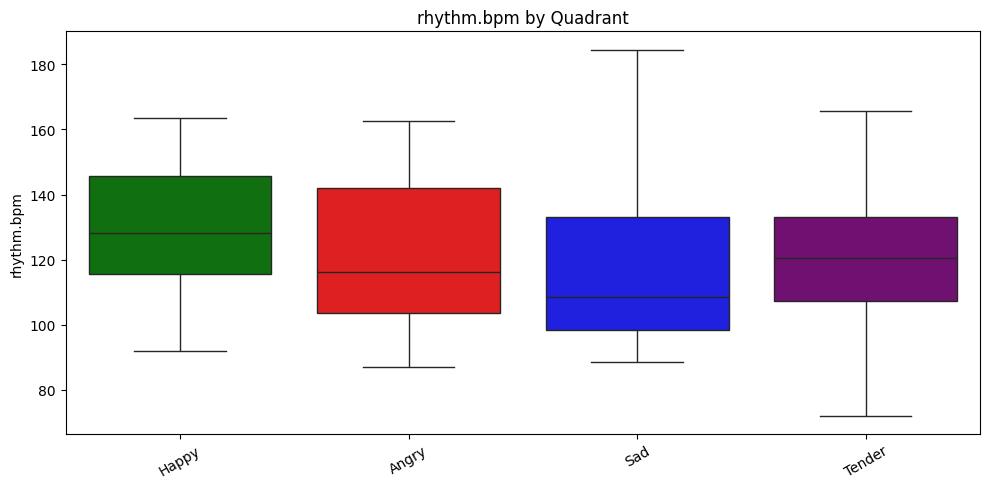


rhythm.bpm - group statistics (mean ± std) and bootstrap 95% CI:
  Happy: n=20, mean=129.3544, std=21.2597, 95%CI_mean=(120.5292, 138.7200)
  Angry: n=20, mean=122.0328, std=23.9372, 95%CI_mean=(112.1494, 132.5060)
  Sad: n=20, mean=117.7860, std=26.6585, 95%CI_mean=(106.5311, 130.0114)
  Tender: n=20, mean=123.1315, std=24.4742, 95%CI_mean=(113.1757, 133.6498)

Assumption checks:
  Shapiro Happy: p=0.6555
  Shapiro Angry: p=0.1092
  Shapiro Sad: p=0.0143
  Shapiro Tender: p=0.3187
  Levene (equal variances) p=0.9567

Kruskal-Wallis: H=3.3572, p=0.33976, (eta² (descr)=0.029)

-> lowlevel.spectral_kurtosis.mean


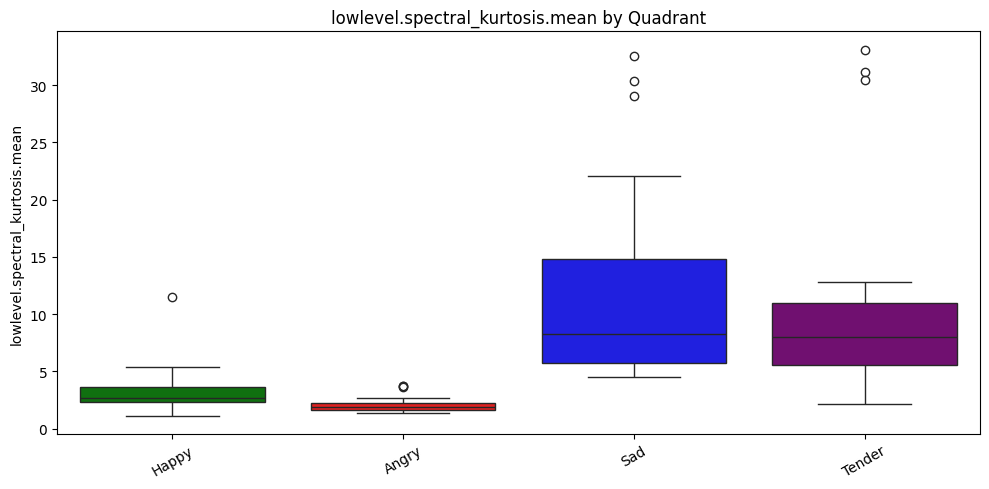


lowlevel.spectral_kurtosis.mean - group statistics (mean ± std) and bootstrap 95% CI:
  Happy: n=20, mean=3.2877, std=2.1535, 95%CI_mean=(2.5031, 4.3735)
  Angry: n=20, mean=2.1223, std=0.7584, 95%CI_mean=(1.7971, 2.4772)
  Sad: n=20, mean=12.3220, std=8.8584, 95%CI_mean=(8.6378, 16.5447)
  Tender: n=20, mean=11.1923, std=8.9286, 95%CI_mean=(7.6840, 15.4554)

Assumption checks:
  Shapiro Happy: p=0.0000
  Shapiro Angry: p=0.0014
  Shapiro Sad: p=0.0005
  Shapiro Tender: p=0.0001
  Levene (equal variances) p=0.0018

Kruskal-Wallis: H=53.2261, p=0.00000, (eta² (descr)=0.338)

-> lowlevel.spectral_kurtosis.stdev


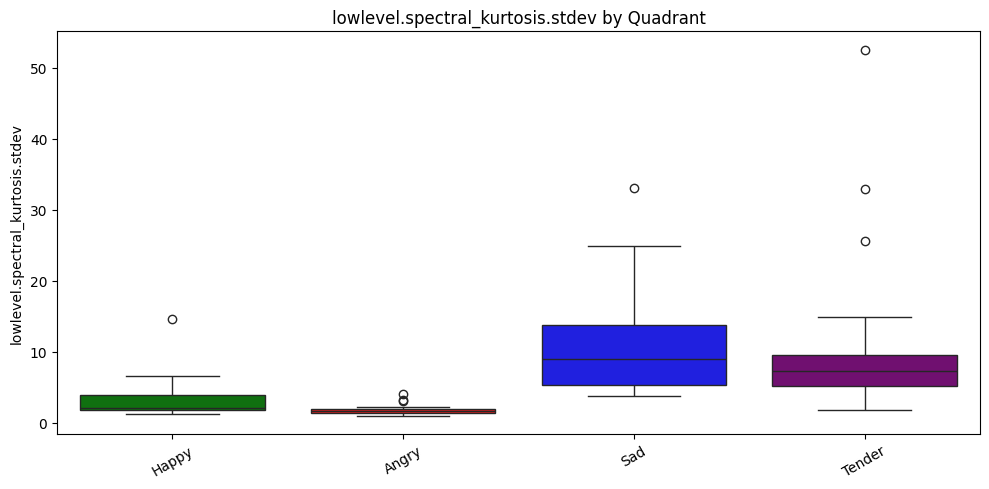


lowlevel.spectral_kurtosis.stdev - group statistics (mean ± std) and bootstrap 95% CI:
  Happy: n=20, mean=3.1999, std=2.9145, 95%CI_mean=(2.1598, 4.7053)
  Angry: n=20, mean=1.8331, std=0.7485, 95%CI_mean=(1.5393, 2.2137)
  Sad: n=20, mean=11.4719, std=7.8236, 95%CI_mean=(8.1729, 15.1847)
  Tender: n=20, mean=11.3410, std=11.9753, 95%CI_mean=(6.9038, 17.5294)

Assumption checks:
  Shapiro Happy: p=0.0000
  Shapiro Angry: p=0.0010
  Shapiro Sad: p=0.0025
  Shapiro Tender: p=0.0000
  Levene (equal variances) p=0.0083

Kruskal-Wallis: H=51.3935, p=0.00000, (eta² (descr)=0.272)

-> tonal.chords_number_rate


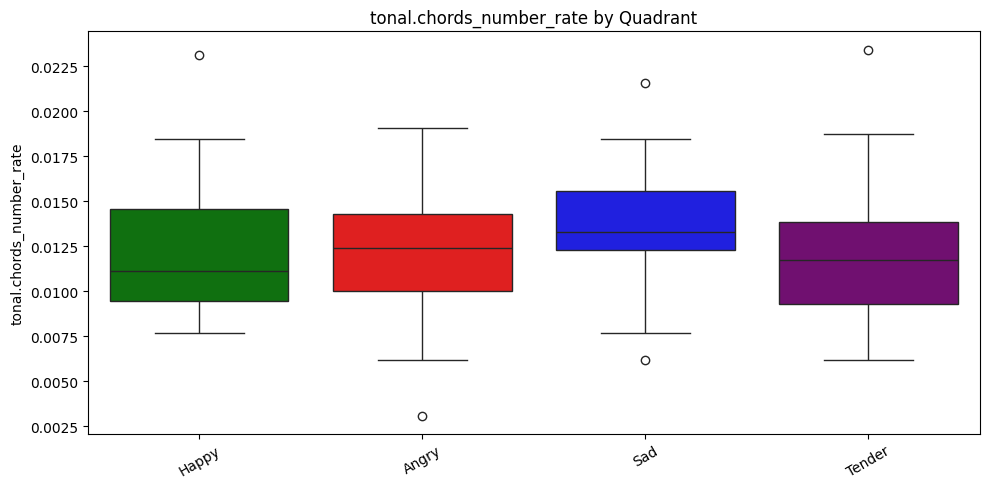


tonal.chords_number_rate - group statistics (mean ± std) and bootstrap 95% CI:
  Happy: n=20, mean=0.0126, std=0.0038, 95%CI_mean=(0.0110, 0.0143)
  Angry: n=20, mean=0.0120, std=0.0042, 95%CI_mean=(0.0102, 0.0138)
  Sad: n=20, mean=0.0134, std=0.0037, 95%CI_mean=(0.0118, 0.0151)
  Tender: n=20, mean=0.0119, std=0.0042, 95%CI_mean=(0.0101, 0.0139)

Assumption checks:
  Shapiro Happy: p=0.0162
  Shapiro Angry: p=0.6912
  Shapiro Sad: p=0.6559
  Shapiro Tender: p=0.1589
  Levene (equal variances) p=0.8854

Kruskal-Wallis: H=2.3342, p=0.50601, (eta² (descr)=0.022)

-> tonal.chords_changes_rate


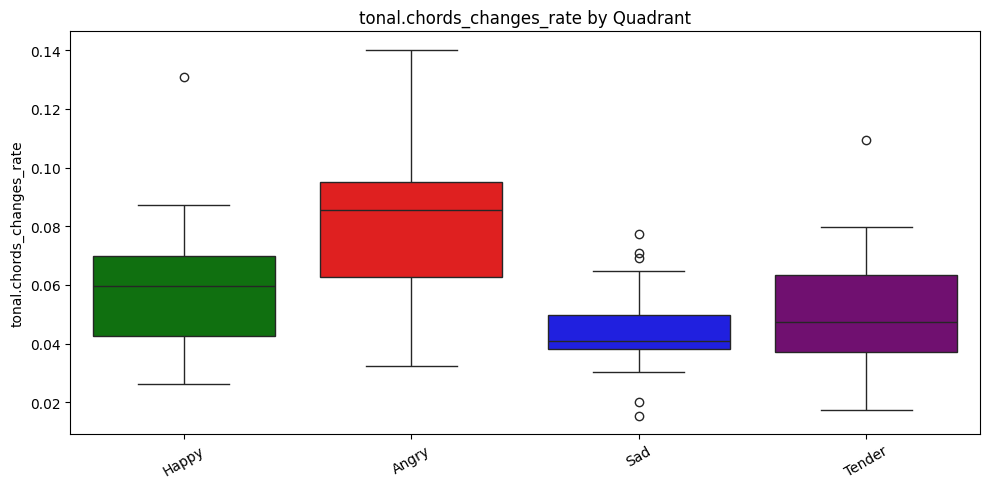


tonal.chords_changes_rate - group statistics (mean ± std) and bootstrap 95% CI:
  Happy: n=20, mean=0.0609, std=0.0237, 95%CI_mean=(0.0503, 0.0720)
  Angry: n=20, mean=0.0853, std=0.0274, 95%CI_mean=(0.0731, 0.0972)
  Sad: n=20, mean=0.0448, std=0.0158, 95%CI_mean=(0.0382, 0.0518)
  Tender: n=20, mean=0.0505, std=0.0214, 95%CI_mean=(0.0413, 0.0599)

Assumption checks:
  Shapiro Happy: p=0.1112
  Shapiro Angry: p=0.7741
  Shapiro Sad: p=0.1181
  Shapiro Tender: p=0.3754
  Levene (equal variances) p=0.2463

ANOVA: F=12.0623, p=0.00000, eta²=0.323

Tukey HSD post-hoc:
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
 Angry  Happy  -0.0243 0.0071 -0.0435 -0.0052   True
 Angry    Sad  -0.0405    0.0 -0.0597 -0.0214   True
 Angry Tender  -0.0348    0.0  -0.054 -0.0157   True
 Happy    Sad  -0.0162 0.1274 -0.0353   0.003  False
 Happy Tender  -0.0105 0.4793 -0.0297  0.0087  False
   

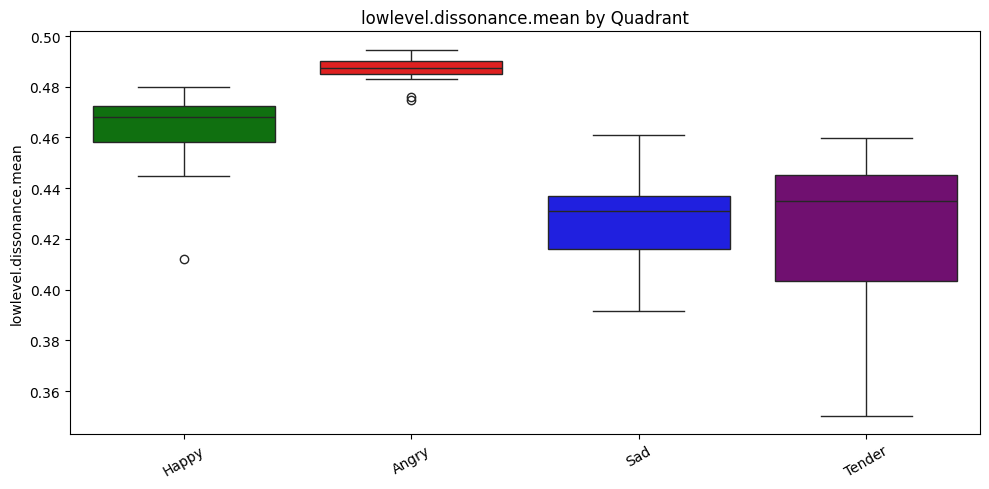


lowlevel.dissonance.mean - group statistics (mean ± std) and bootstrap 95% CI:
  Happy: n=20, mean=0.4631, std=0.0152, 95%CI_mean=(0.4558, 0.4695)
  Angry: n=20, mean=0.4869, std=0.0051, 95%CI_mean=(0.4845, 0.4890)
  Sad: n=20, mean=0.4270, std=0.0176, 95%CI_mean=(0.4190, 0.4344)
  Tender: n=20, mean=0.4240, std=0.0273, 95%CI_mean=(0.4113, 0.4351)

Assumption checks:
  Shapiro Happy: p=0.0012
  Shapiro Angry: p=0.1216
  Shapiro Sad: p=0.7686
  Shapiro Tender: p=0.0645
  Levene (equal variances) p=0.0008

Kruskal-Wallis: H=60.6678, p=0.00000, (eta² (descr)=0.676)

-> lowlevel.dissonance.stdev


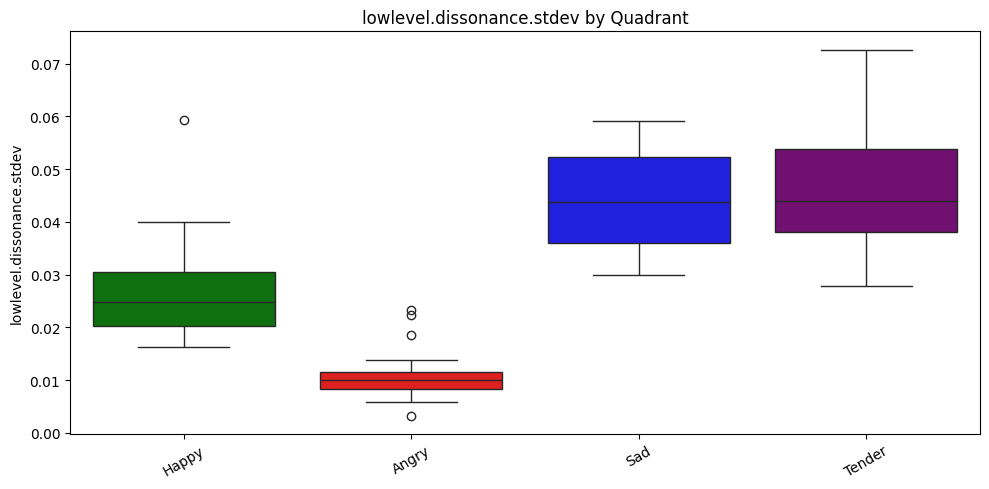


lowlevel.dissonance.stdev - group statistics (mean ± std) and bootstrap 95% CI:
  Happy: n=20, mean=0.0273, std=0.0101, 95%CI_mean=(0.0230, 0.0321)
  Angry: n=20, mean=0.0110, std=0.0050, 95%CI_mean=(0.0090, 0.0135)
  Sad: n=20, mean=0.0440, std=0.0093, 95%CI_mean=(0.0401, 0.0484)
  Tender: n=20, mean=0.0458, std=0.0121, 95%CI_mean=(0.0406, 0.0512)

Assumption checks:
  Shapiro Happy: p=0.0074
  Shapiro Angry: p=0.0071
  Shapiro Sad: p=0.2223
  Shapiro Tender: p=0.3094
  Levene (equal variances) p=0.0147

Kruskal-Wallis: H=56.5994, p=0.00000, (eta² (descr)=0.689)

-> lowlevel.average_loudness


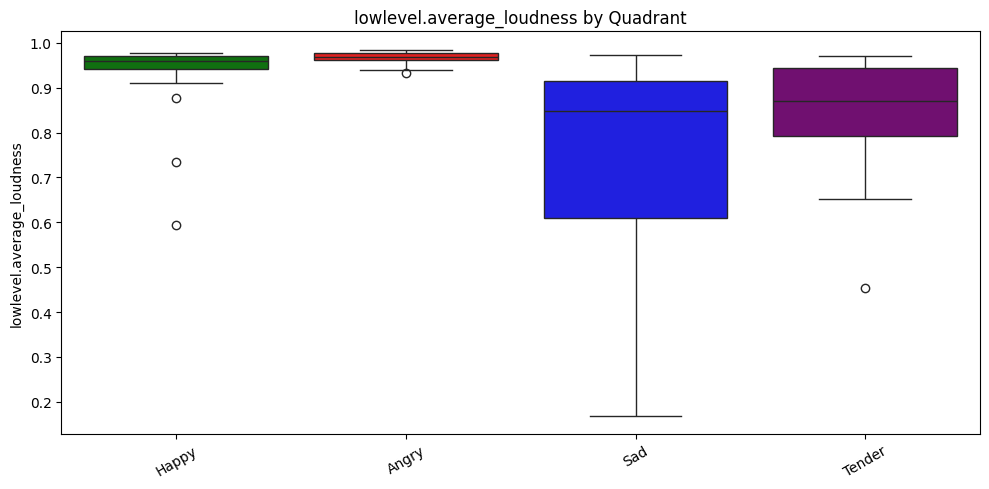


lowlevel.average_loudness - group statistics (mean ± std) and bootstrap 95% CI:
  Happy: n=20, mean=0.9253, std=0.0929, 95%CI_mean=(0.8793, 0.9586)
  Angry: n=20, mean=0.9676, std=0.0132, 95%CI_mean=(0.9613, 0.9729)
  Sad: n=20, mean=0.7466, std=0.2269, 95%CI_mean=(0.6424, 0.8400)
  Tender: n=20, mean=0.8340, std=0.1353, 95%CI_mean=(0.7712, 0.8934)

Assumption checks:
  Shapiro Happy: p=0.0000
  Shapiro Angry: p=0.0254
  Shapiro Sad: p=0.0057
  Shapiro Tender: p=0.0036
  Levene (equal variances) p=0.0001

Kruskal-Wallis: H=35.7246, p=0.00000, (eta² (descr)=0.270)

-> lowlevel.pitch_salience.mean


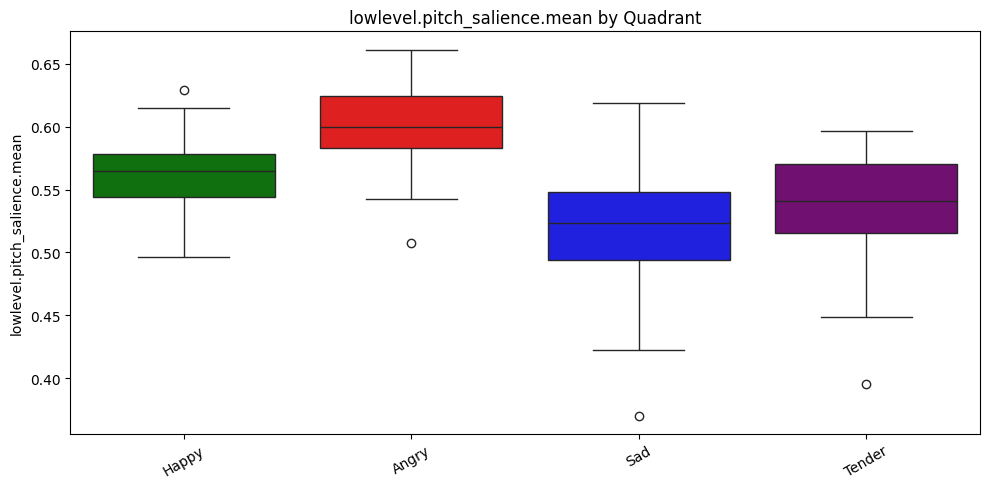


lowlevel.pitch_salience.mean - group statistics (mean ± std) and bootstrap 95% CI:
  Happy: n=20, mean=0.5606, std=0.0334, 95%CI_mean=(0.5461, 0.5752)
  Angry: n=20, mean=0.5991, std=0.0372, 95%CI_mean=(0.5823, 0.6145)
  Sad: n=20, mean=0.5141, std=0.0551, 95%CI_mean=(0.4895, 0.5374)
  Tender: n=20, mean=0.5323, std=0.0473, 95%CI_mean=(0.5093, 0.5503)

Assumption checks:
  Shapiro Happy: p=0.4737
  Shapiro Angry: p=0.7820
  Shapiro Sad: p=0.2158
  Shapiro Tender: p=0.0414
  Levene (equal variances) p=0.4230

Kruskal-Wallis: H=29.4180, p=0.00000, (eta² (descr)=0.347)

-> lowlevel.pitch_salience.stdev


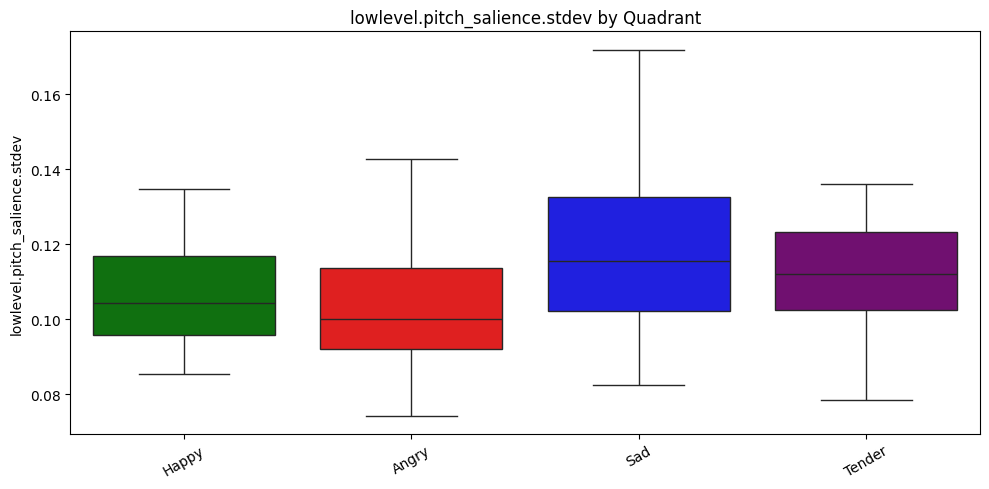


lowlevel.pitch_salience.stdev - group statistics (mean ± std) and bootstrap 95% CI:
  Happy: n=20, mean=0.1071, std=0.0143, 95%CI_mean=(0.1007, 0.1138)
  Angry: n=20, mean=0.1030, std=0.0168, 95%CI_mean=(0.0964, 0.1105)
  Sad: n=20, mean=0.1187, std=0.0240, 95%CI_mean=(0.1087, 0.1300)
  Tender: n=20, mean=0.1113, std=0.0168, 95%CI_mean=(0.1038, 0.1183)

Assumption checks:
  Shapiro Happy: p=0.2277
  Shapiro Angry: p=0.2361
  Shapiro Sad: p=0.2225
  Shapiro Tender: p=0.3112
  Levene (equal variances) p=0.1472

ANOVA: F=2.5596, p=0.06120, eta²=0.092

-> rhythm.onset_rate


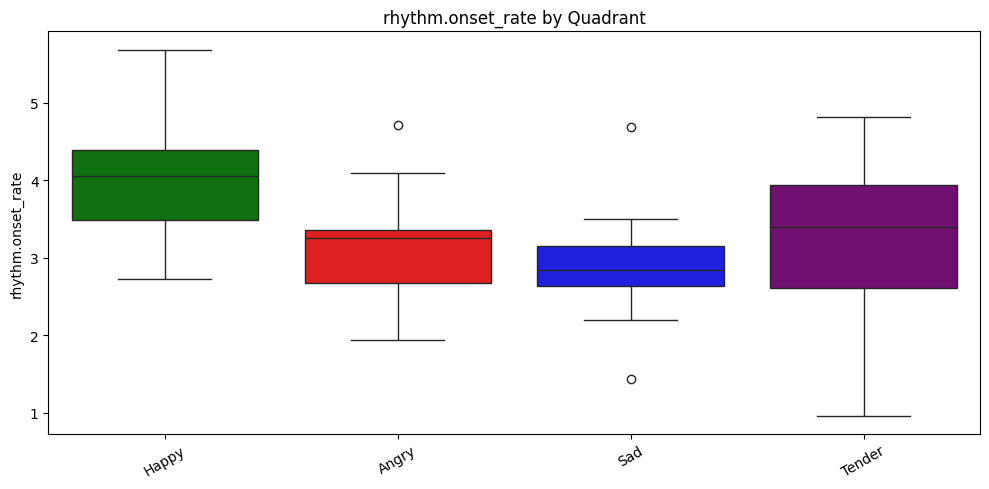


rhythm.onset_rate - group statistics (mean ± std) and bootstrap 95% CI:
  Happy: n=20, mean=4.0760, std=0.7371, 95%CI_mean=(3.7635, 4.3945)
  Angry: n=20, mean=3.1636, std=0.6428, 95%CI_mean=(2.8912, 3.4446)
  Sad: n=20, mean=2.8781, std=0.6159, 95%CI_mean=(2.6114, 3.1532)
  Tender: n=20, mean=3.3124, std=0.9290, 95%CI_mean=(2.8773, 3.7015)

Assumption checks:
  Shapiro Happy: p=0.7978
  Shapiro Angry: p=0.2598
  Shapiro Sad: p=0.0854
  Shapiro Tender: p=0.5523
  Levene (equal variances) p=0.1692

ANOVA: F=9.0523, p=0.00003, eta²=0.263

Tukey HSD post-hoc:
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
 Angry  Happy   0.9124 0.0017  0.2805  1.5443   True
 Angry    Sad  -0.2856 0.6368 -0.9175  0.3463  False
 Angry Tender   0.1488 0.9259 -0.4831  0.7807  False
 Happy    Sad   -1.198    0.0 -1.8299 -0.5661   True
 Happy Tender  -0.7636 0.0114 -1.3955 -0.1317   True
   Sad Tende

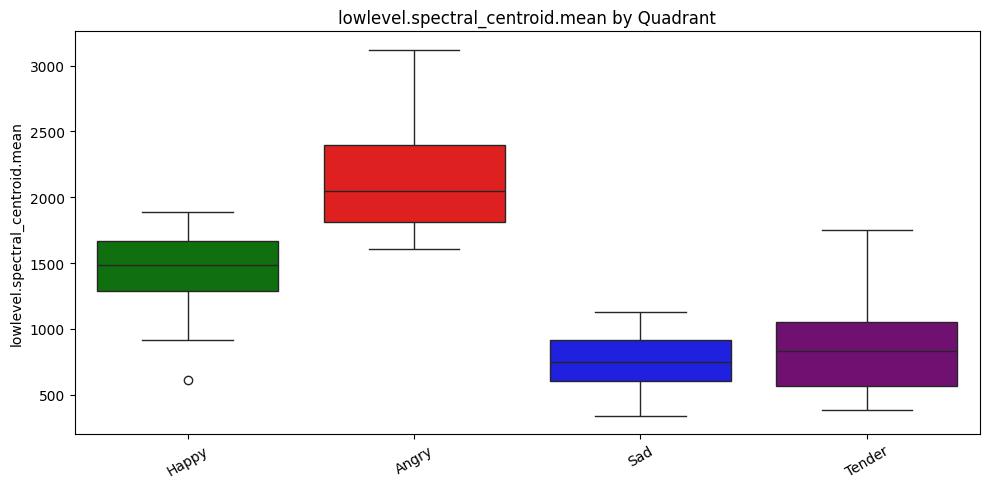


lowlevel.spectral_centroid.mean - group statistics (mean ± std) and bootstrap 95% CI:
  Happy: n=20, mean=1432.6819, std=346.1445, 95%CI_mean=(1272.4369, 1580.5883)
  Angry: n=20, mean=2141.6944, std=416.9924, 95%CI_mean=(1966.9063, 2325.3968)
  Sad: n=20, mean=758.8759, std=194.1389, 95%CI_mean=(667.3752, 844.2511)
  Tender: n=20, mean=844.9171, std=343.7572, 95%CI_mean=(702.8455, 1004.6602)

Assumption checks:
  Shapiro Happy: p=0.1975
  Shapiro Angry: p=0.2041
  Shapiro Sad: p=0.7667
  Shapiro Tender: p=0.2267
  Levene (equal variances) p=0.0686

ANOVA: F=69.0788, p=0.00000, eta²=0.732

Tukey HSD post-hoc:
    Multiple Comparison of Means - Tukey HSD, FWER=0.05     
group1 group2  meandiff  p-adj    lower      upper    reject
------------------------------------------------------------
 Angry  Happy  -709.0125    0.0  -994.7237  -423.3012   True
 Angry    Sad -1382.8185    0.0 -1668.5297 -1097.1072   True
 Angry Tender -1296.7773    0.0 -1582.4885  -1011.066   True
 Happy    Sad   

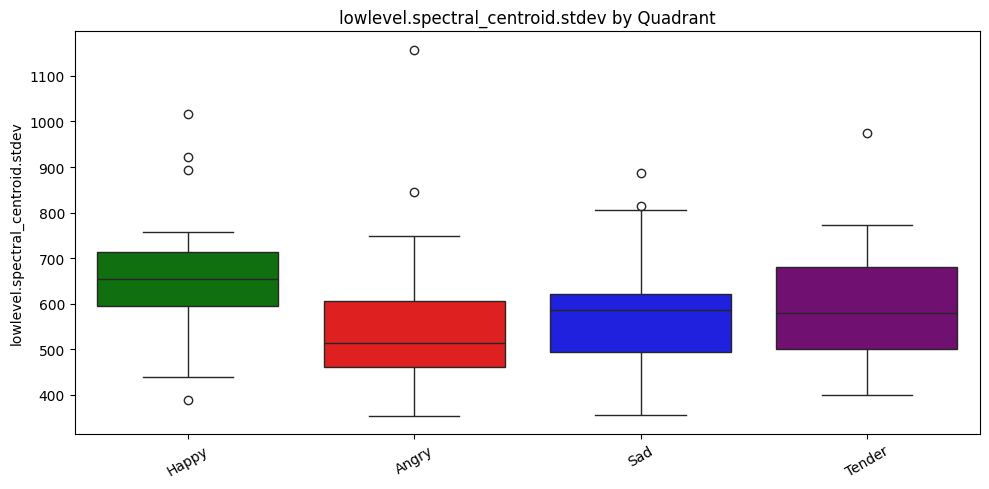


lowlevel.spectral_centroid.stdev - group statistics (mean ± std) and bootstrap 95% CI:
  Happy: n=20, mean=667.2381, std=149.8182, 95%CI_mean=(606.4749, 732.8724)
  Angry: n=20, mean=567.6715, std=178.2872, 95%CI_mean=(500.6592, 659.2371)
  Sad: n=20, mean=579.8673, std=139.9494, 95%CI_mean=(519.4513, 645.6070)
  Tender: n=20, mean=599.8349, std=137.2388, 95%CI_mean=(541.1895, 661.9144)

Assumption checks:
  Shapiro Happy: p=0.4017
  Shapiro Angry: p=0.0018
  Shapiro Sad: p=0.3832
  Shapiro Tender: p=0.3173
  Levene (equal variances) p=0.9807

Kruskal-Wallis: H=7.1237, p=0.06806, (eta² (descr)=0.060)

-> tonal.hpcp_entropy.mean


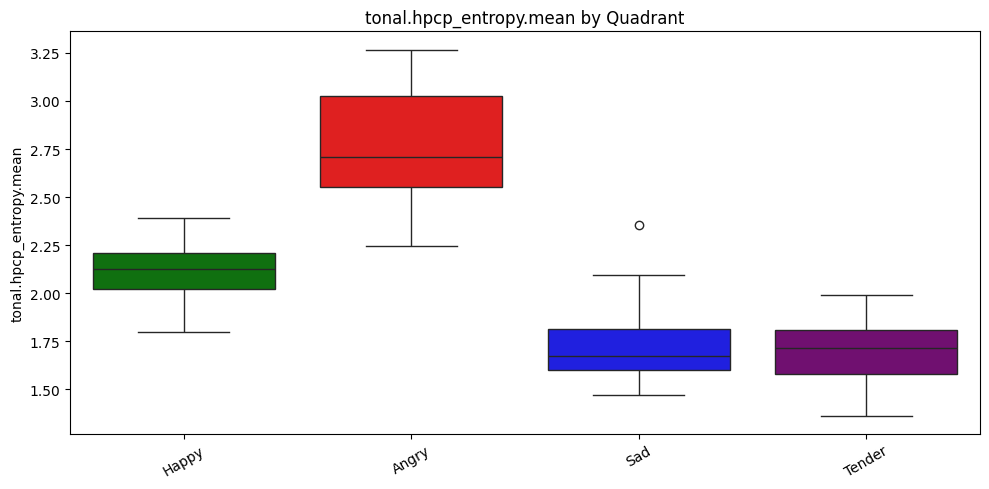


tonal.hpcp_entropy.mean - group statistics (mean ± std) and bootstrap 95% CI:
  Happy: n=20, mean=2.0976, std=0.1582, 95%CI_mean=(2.0273, 2.1653)
  Angry: n=20, mean=2.7461, std=0.2978, 95%CI_mean=(2.6097, 2.8773)
  Sad: n=20, mean=1.7418, std=0.2202, 95%CI_mean=(1.6486, 1.8407)
  Tender: n=20, mean=1.6971, std=0.1565, 95%CI_mean=(1.6292, 1.7626)

Assumption checks:
  Shapiro Happy: p=0.2129
  Shapiro Angry: p=0.3926
  Shapiro Sad: p=0.0111
  Shapiro Tender: p=0.9696
  Levene (equal variances) p=0.0100

Kruskal-Wallis: H=60.2150, p=0.00000, (eta² (descr)=0.791)

-> tonal.hpcp_entropy.stdev


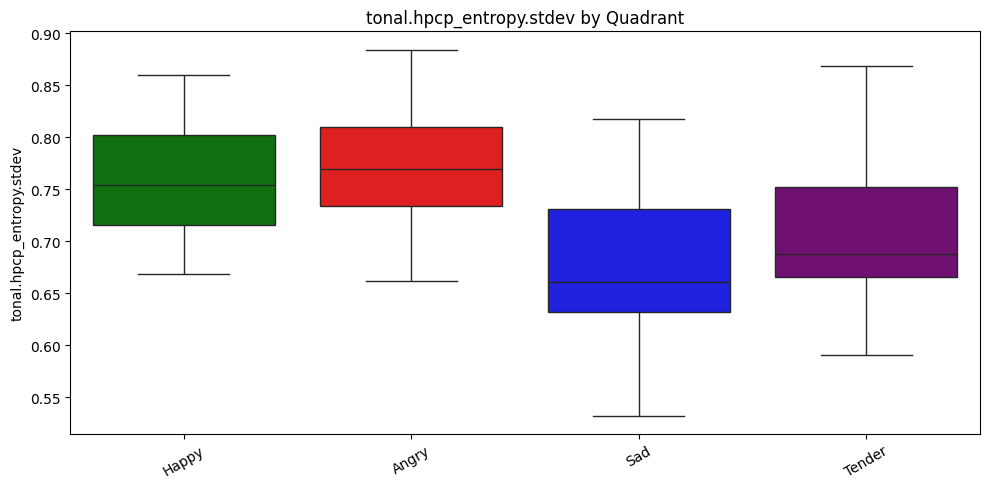


tonal.hpcp_entropy.stdev - group statistics (mean ± std) and bootstrap 95% CI:
  Happy: n=20, mean=0.7597, std=0.0531, 95%CI_mean=(0.7367, 0.7833)
  Angry: n=20, mean=0.7689, std=0.0544, 95%CI_mean=(0.7456, 0.7922)
  Sad: n=20, mean=0.6769, std=0.0700, 95%CI_mean=(0.6478, 0.7080)
  Tender: n=20, mean=0.7029, std=0.0674, 95%CI_mean=(0.6737, 0.7320)

Assumption checks:
  Shapiro Happy: p=0.8004
  Shapiro Angry: p=0.9715
  Shapiro Sad: p=0.7438
  Shapiro Tender: p=0.4444
  Levene (equal variances) p=0.6971

ANOVA: F=9.8465, p=0.00001, eta²=0.280

Tukey HSD post-hoc:
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
 Angry  Happy  -0.0092 0.9675 -0.0618  0.0434  False
 Angry    Sad   -0.092 0.0001 -0.1446 -0.0394   True
 Angry Tender  -0.0659  0.008 -0.1185 -0.0134   True
 Happy    Sad  -0.0828 0.0005 -0.1354 -0.0302   True
 Happy Tender  -0.0567 0.0293 -0.1093 -0.0042   True
   Sa

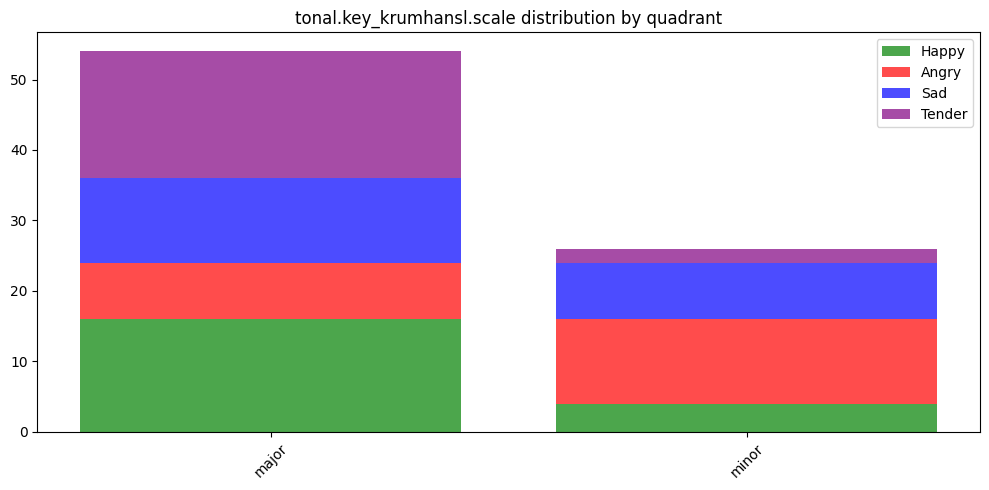

Chi2=13.447, p=0.00376, dof=3
→ Significant association (p < 0.05)

-> tonal.chords_key


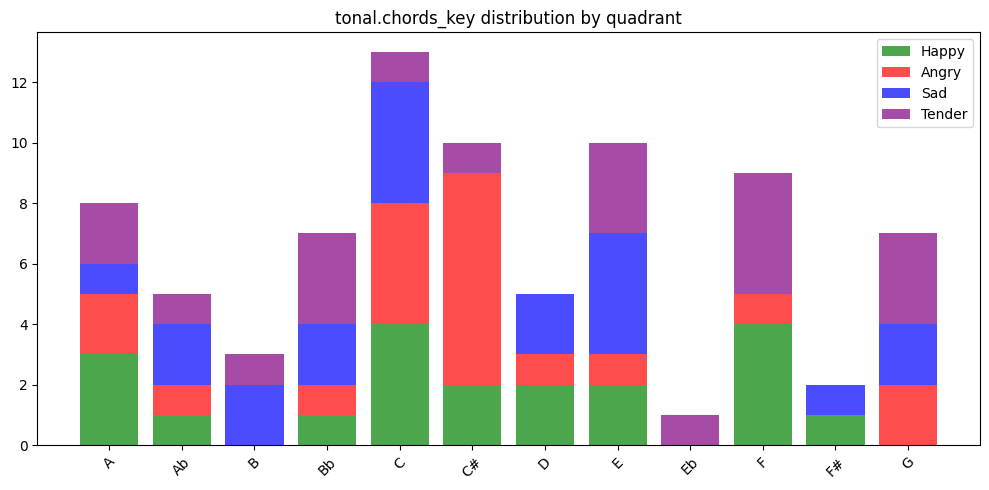

Chi2=38.096, p=0.24864, dof=33
→ No significant association (p >= 0.05)

Applying Benjamini-Hochberg FDR correction across tested features...

FDR results (alpha = 0.050):
  rhythm.bpm: raw_p=0.33976, p_adj=0.36099, significant=False
  lowlevel.spectral_kurtosis.mean: raw_p=0.00000, p_adj=0.00000, significant=True
  lowlevel.spectral_kurtosis.stdev: raw_p=0.00000, p_adj=0.00000, significant=True
  tonal.chords_number_rate: raw_p=0.50601, p_adj=0.50601, significant=False
  tonal.chords_changes_rate: raw_p=0.00000, p_adj=0.00000, significant=True
  lowlevel.dissonance.mean: raw_p=0.00000, p_adj=0.00000, significant=True
  lowlevel.dissonance.stdev: raw_p=0.00000, p_adj=0.00000, significant=True
  lowlevel.average_loudness: raw_p=0.00000, p_adj=0.00000, significant=True
  lowlevel.pitch_salience.mean: raw_p=0.00000, p_adj=0.00000, significant=True
  lowlevel.pitch_salience.stdev: raw_p=0.06120, p_adj=0.08002, significant=False
  rhythm.onset_rate: raw_p=0.00003, p_adj=0.00005, significant

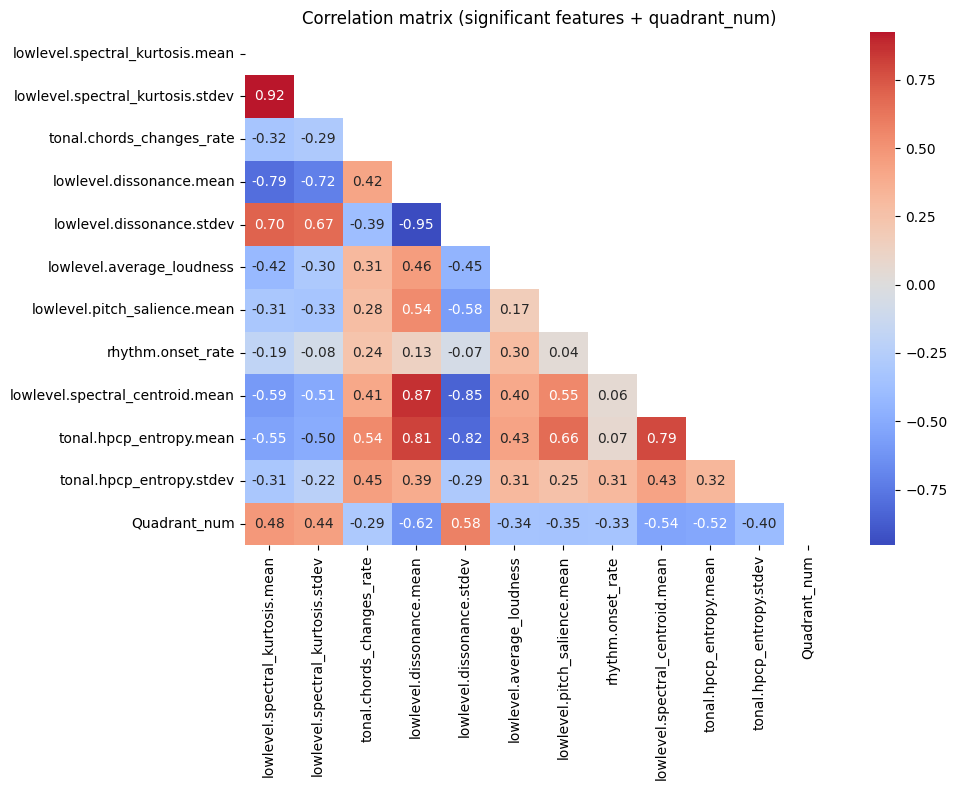


Top correlated features with Quadrant_num:
lowlevel.dissonance.mean            0.622743
lowlevel.dissonance.stdev           0.581922
lowlevel.spectral_centroid.mean     0.543499
tonal.hpcp_entropy.mean             0.522408
lowlevel.spectral_kurtosis.mean     0.482843
lowlevel.spectral_kurtosis.stdev    0.444470
tonal.hpcp_entropy.stdev            0.403399
lowlevel.pitch_salience.mean        0.348704
lowlevel.average_loudness           0.337197
rhythm.onset_rate                   0.333466

Running 4-fold cross-validation on features: ['lowlevel.spectral_kurtosis.mean', 'lowlevel.spectral_kurtosis.stdev', 'tonal.chords_changes_rate', 'lowlevel.dissonance.mean', 'lowlevel.dissonance.stdev', 'lowlevel.average_loudness', 'lowlevel.pitch_salience.mean', 'rhythm.onset_rate', 'lowlevel.spectral_centroid.mean', 'tonal.hpcp_entropy.mean', 'tonal.hpcp_entropy.stdev']
LogisticRegression accuracy: mean=0.650, std=0.050
RandomForest accuracy:       mean=0.700, std=0.071

Classifier results: {'logis

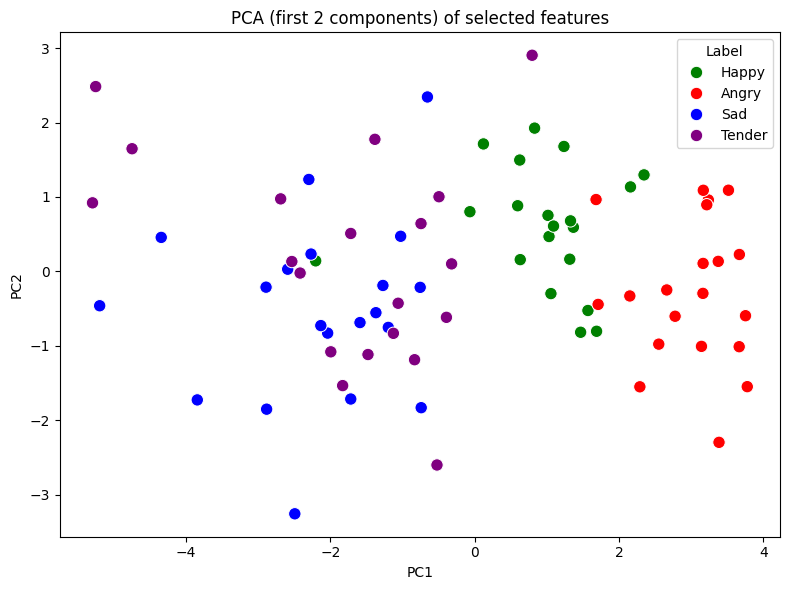

Explained variance ratio (first 2): [0.52645539 0.1262904 ]
Detected 8 outlier rows with |z| > 3.0.

Sample outliers (first 10):
   Quadrant  lowlevel.spectral_kurtosis.mean  lowlevel.spectral_kurtosis.stdev  tonal.chords_changes_rate  lowlevel.dissonance.mean  lowlevel.dissonance.stdev  lowlevel.average_loudness  lowlevel.pitch_salience.mean  rhythm.onset_rate  lowlevel.spectral_centroid.mean  tonal.hpcp_entropy.mean  tonal.hpcp_entropy.stdev
43       Q3                         6.561217                          4.912872                   0.040062                  0.415389                   0.052099                   0.919409                      0.370260           2.692689                       581.223022                 1.529314                  0.633706
45       Q3                        30.366400                         33.046497                   0.038640                  0.391664                   0.052628                   0.606747                      0.501545           2.86664

In [ ]:


import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import chi2_contingency, kruskal, levene, shapiro
from sklearn.utils import resample
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.multitest import multipletests

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.decomposition import PCA

from typing import List, Dict, Tuple


class EmotionalQuadrantAnalyzer:
    """
    Enhanced analyzer for musical features across emotional quadrants.
    Adds assumption checks, Kruskal-Wallis fallback, Benjamini-Hochberg FDR,
    bootstrap CIs, simple classification, PCA visualization, and outlier checks.
    """

    def __init__(self, df: pd.DataFrame, random_state: int = 42):
        self.df = df.copy()
        self.random_state = random_state
        self.balanced_df: pd.DataFrame = None
        self.available_features: List[str] = []
        self.significant_features: List[str] = []
        self.anova_results: Dict[str, float] = {}
        self.kruskal_results: Dict[str, float] = {}
        self.pvals_for_fdr: Dict[str, float] = {}

        # Feature lists (same as your original)
        self.relevant_features = [
            "rhythm.bpm",
            "lowlevel.spectral_kurtosis.mean",
            "lowlevel.spectral_kurtosis.stdev",
            "tonal.chords_number_rate",
            "tonal.chords_changes_rate",
            "lowlevel.dissonance.mean",
            "lowlevel.dissonance.stdev",
            "lowlevel.average_loudness",
            "lowlevel.pitch_salience.mean",
            "lowlevel.pitch_salience.stdev",
            "rhythm.onset_rate",
            "lowlevel.spectral_centroid.mean",
            "lowlevel.spectral_centroid.stdev",
            "tonal.hpcp_entropy.mean",
            "tonal.hpcp_entropy.stdev",
            "tonal.key_krumhansl.scale",
            "tonal.chords_key",
        ]
        self.categorical_features = ["tonal.key_krumhansl.scale", "tonal.chords_key"]

        # Labels + plotting colors
        self.quadrant_labels = {"Q1": "Happy", "Q2": "Angry", "Q3": "Sad", "Q4": "Tender"}
        self.quadrant_colors = {"Q1": "green", "Q2": "red", "Q3": "blue", "Q4": "purple"}

    # ---------------------------
    # Data preparation utilities
    # ---------------------------
    def prepare_balanced_data(self, method: str = "downsample") -> pd.DataFrame:
        """
        Balance the dataset across quadrants.
        method: 'downsample' (default) or 'upsample'
        """
        print("Preparing balanced dataset...")
        quadrant_counts = self.df["Quadrant"].value_counts()
        print("Original sample sizes:")
        for q, c in quadrant_counts.items():
            print(f"  {self.quadrant_labels.get(q, q)} ({q}): {c}")

        min_samples = int(quadrant_counts.min())
        max_samples = int(quadrant_counts.max())
        target = min_samples if method == "downsample" else max_samples
        print(f"\nBalancing using method='{method}' to {target} samples per quadrant")

        balanced_parts = []
        for q in ["Q1", "Q2", "Q3", "Q4"]:
            part = self.df[self.df["Quadrant"] == q]
            if part.empty:
                continue
            if method == "downsample":
                if len(part) > target:
                    part = resample(part, replace=False, n_samples=target, random_state=self.random_state)
            else:  # upsample
                if len(part) < target:
                    part = resample(part, replace=True, n_samples=target, random_state=self.random_state)
            balanced_parts.append(part)

        self.balanced_df = pd.concat(balanced_parts, ignore_index=True)
        print("\nBalanced dataset sample sizes:")
        for q, c in self.balanced_df["Quadrant"].value_counts().items():
            print(f"  {self.quadrant_labels.get(q, q)} ({q}): {c}")
        return self.balanced_df

    def check_available_features(self) -> List[str]:
        self.available_features = [f for f in self.relevant_features if f in self.df.columns]
        print("\nAvailable features for analysis:")
        for f in self.available_features:
            print(f"✓ {f}")
        print(f"\nTotal available: {len(self.available_features)} / {len(self.relevant_features)}")
        return self.available_features

    # ---------------------------
    # Statistical helpers
    # ---------------------------
    @staticmethod
    def _eta_squared(groups: List[pd.Series]) -> float:
        """Compute eta-squared for one-way ANOVA groups (small sample-safe)."""
        all_vals = np.concatenate([g for g in groups])
        grand_mean = np.mean(all_vals)
        ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
        ss_total = sum(np.sum((g - grand_mean) ** 2) for g in groups)
        return float(ss_between / ss_total) if ss_total > 0 else 0.0

    def _bootstrap_ci(self, arr: np.ndarray, n_boot: int = 2000, ci: float = 0.95) -> Tuple[float, float]:
        """Bootstrap percentile CI for the mean."""
        n = len(arr)
        if n == 0:
            return (np.nan, np.nan)
        rng = np.random.RandomState(self.random_state)
        means = []
        for _ in range(n_boot):
            sample = rng.choice(arr, size=n, replace=True)
            means.append(sample.mean())
        alpha = (1 - ci) / 2.0
        lower = np.percentile(means, 100 * alpha)
        upper = np.percentile(means, 100 * (1 - alpha))
        return float(lower), float(upper)

    # ---------------------------
    # Analysis per feature
    # ---------------------------
    def analyze_continuous_feature(self, feature_name: str, data: pd.DataFrame) -> bool:
        """
        Analyze a continuous feature — prints boxplot, group stats, ANOVA or Kruskal,
        normality/homogeneity checks, effect size (eta²), bootstrap CIs, Tukey HSD if applicable.
        Returns True if significant (after per-feature test p < 0.05).
        """
        if feature_name not in data.columns:
            print(f"Feature '{feature_name}' not found.")
            return False

        groups = []
        group_labels = []
        for q in ["Q1", "Q2", "Q3", "Q4"]:
            vals = data[data["Quadrant"] == q][feature_name].dropna().values
            if len(vals) > 0:
                groups.append(np.asarray(vals))
                group_labels.append(self.quadrant_labels.get(q, q))

        if len(groups) < 2:
            print(f"Not enough groups with values for {feature_name}")
            return False

        # Plot
        plt.figure(figsize=(10, 5))
        sns.boxplot(data=[g for g in groups], palette=[self.quadrant_colors[q] for q in ["Q1", "Q2", "Q3", "Q4"][: len(groups)]])
        plt.xticks(ticks=range(len(group_labels)), labels=group_labels, rotation=30)
        plt.title(f"{feature_name} by Quadrant")
        plt.ylabel(feature_name)
        plt.tight_layout()
        plt.show()

        # Basic stats + bootstrap CI
        print(f"\n{feature_name} - group statistics (mean ± std) and bootstrap 95% CI:")
        for lab, arr in zip(group_labels, groups):
            lm, ls = arr.mean(), arr.std(ddof=0)
            lower, upper = self._bootstrap_ci(arr)
            print(f"  {lab}: n={len(arr)}, mean={lm:.4f}, std={ls:.4f}, 95%CI_mean=({lower:.4f}, {upper:.4f})")

        # Assumption checks
        print("\nAssumption checks:")
        # Normality (Shapiro) per group (only when group size >= 3)
        normality_results = {}
        for lab, arr in zip(group_labels, groups):
            if 3 <= len(arr) <= 5000:
                try:
                    stat, p = shapiro(arr)
                    normality_results[lab] = p
                    print(f"  Shapiro {lab}: p={p:.4f}")
                except Exception:
                    normality_results[lab] = np.nan
                    print(f"  Shapiro {lab}: failed")
            else:
                normality_results[lab] = np.nan
                print(f"  Shapiro {lab}: skipped (n={len(arr)})")

        # Homogeneity (Levene)
        try:
            stat_lev, p_lev = levene(*groups, center="median")
            print(f"  Levene (equal variances) p={p_lev:.4f}")
        except Exception:
            stat_lev, p_lev = (np.nan, np.nan)
            print("  Levene: failed")

        # Decide test: ANOVA if groups roughly normal and homoscedastic; else Kruskal
        use_anova = True
        # If any Shapiro p < 0.05 -> non-normal
        if any((p is not np.nan and p < 0.05) for p in normality_results.values()):
            use_anova = False
        if p_lev is not np.nan and p_lev < 0.05:
            use_anova = False

        if use_anova:
            f_stat, p_val = stats.f_oneway(*groups)
            eta2 = self._eta_squared(groups)
            self.anova_results[feature_name] = p_val
            self.pvals_for_fdr[feature_name] = p_val
            print(f"\nANOVA: F={f_stat:.4f}, p={p_val:.5f}, eta²={eta2:.3f}")
            significant = p_val < 0.05
            if significant and len(groups) > 2:
                print("\nTukey HSD post-hoc:")
                # build arrays for tukey
                values = np.concatenate(groups)
                labels = sum([[lab] * len(arr) for lab, arr in zip(group_labels, groups)], [])
                tukey = pairwise_tukeyhsd(values, labels, alpha=0.05)
                print(tukey)
        else:
            # Kruskal-Wallis nonparametric test
            stat_k, p_k = kruskal(*groups)
            self.kruskal_results[feature_name] = p_k
            self.pvals_for_fdr[feature_name] = p_k
            eta2 = self._eta_squared(groups)  # keep as descriptive
            print(f"\nKruskal-Wallis: H={stat_k:.4f}, p={p_k:.5f}, (eta² (descr)={eta2:.3f})")
            significant = p_k < 0.05

        print("=" * 70)
        return bool(significant)

    def analyze_categorical_feature(self, feature_name: str, data: pd.DataFrame) -> bool:
        """Chi-square test, stacked bar, and report (group x category)."""
        if feature_name not in data.columns:
            print(f"Feature '{feature_name}' not found.")
            return False

        quadrant_counts = {}
        for q in ["Q1", "Q2", "Q3", "Q4"]:
            vals = data[data["Quadrant"] == q][feature_name].dropna()
            if len(vals) > 0:
                quadrant_counts[self.quadrant_labels[q]] = vals.value_counts()

        if not quadrant_counts:
            print("No counts to analyze.")
            return False

        # Build contingency table
        categories = sorted({cat for counts in quadrant_counts.values() for cat in counts.index})
        table = []
        for lab in ["Happy", "Angry", "Sad", "Tender"]:
            counts = quadrant_counts.get(lab, pd.Series(dtype=int))
            row = [int(counts.get(cat, 0)) for cat in categories]
            table.append(row)
        table = np.array(table)

        # Plot stacked bar
        plt.figure(figsize=(10, 5))
        bottom = np.zeros(table.shape[1], dtype=int)
        for i, lab in enumerate(["Happy", "Angry", "Sad", "Tender"]):
            row = table[i]
            if row.sum() == 0:
                continue
            plt.bar(categories, row, bottom=bottom, label=lab, alpha=0.7, color=self.quadrant_colors[f"Q{i+1}"])
            bottom += row
        plt.xticks(rotation=45)
        plt.legend()
        plt.title(f"{feature_name} distribution by quadrant")
        plt.tight_layout()
        plt.show()

        # Chi-square
        try:
            chi2, p, dof, expected = chi2_contingency(table)
            print(f"Chi2={chi2:.3f}, p={p:.5f}, dof={dof}")
            self.pvals_for_fdr[feature_name] = p
            significant = p < 0.05
            if not significant:
                print("→ No significant association (p >= 0.05)")
            else:
                print("→ Significant association (p < 0.05)")
        except Exception as e:
            print("Chi-square failed:", e)
            significant = False

        print("=" * 70)
        return bool(significant)

    # ---------------------------
    # Full analysis workflow
    # ---------------------------
    def run_comprehensive_analysis(self, balance_method: str = "downsample", fdr_alpha: float = 0.05) -> List[str]:
        """
        Runs the full analysis:
         - balances data
         - checks features
         - runs per-feature tests (ANOVA/Kruskal) and categorical tests
         - applies Benjamini-Hochberg FDR correction across the tested features
         - stores significant features (after FDR)
         - runs correlation heatmap and reports
        """
        print("\nEMOTIONAL QUADRANT MUSICAL FEATURE ANALYSIS")
        print("=" * 70)

        # Prepare balanced dataset
        self.prepare_balanced_data(method=balance_method)

        # Check available features in original dataframe
        self.check_available_features()

        # Run continuous analyses and collect p-values
        per_feature_significant = []
        tested_features = []
        print("\nANALYZING CONTINUOUS FEATURES")
        for feat in self.available_features:
            if feat in self.categorical_features:
                continue
            print(f"\n-> {feat}")
            tested_features.append(feat)
            sig = self.analyze_continuous_feature(feat, self.balanced_df)
            per_feature_significant.append((feat, sig))

        # Categorical features
        print("\nANALYZING CATEGORICAL FEATURES")
        for feat in self.categorical_features:
            if feat in self.available_features:
                print(f"\n-> {feat}")
                tested_features.append(feat)
                sig = self.analyze_categorical_feature(feat, self.balanced_df)
                per_feature_significant.append((feat, sig))

        # Apply Benjamini-Hochberg FDR to the collected p-values
        print("\nApplying Benjamini-Hochberg FDR correction across tested features...")
        feats = list(self.pvals_for_fdr.keys())
        pvals = [self.pvals_for_fdr[f] for f in feats]
        if len(pvals) > 0:
            reject, pvals_corrected, _, _ = multipletests(pvals, alpha=fdr_alpha, method="fdr_bh")
            self.significant_features = [f for f, rej in zip(feats, reject) if rej]
            print("\nFDR results (alpha = {:.3f}):".format(fdr_alpha))
            for f, p0, p_corr, rej in zip(feats, pvals, pvals_corrected, reject):
                print(f"  {f}: raw_p={p0:.5f}, p_adj={p_corr:.5f}, significant={rej}")
        else:
            print("No p-values collected; nothing to correct.")
            self.significant_features = []

        # Summary
        self._generate_summary()
        self._generate_correlation_analysis()

        return self.significant_features

    # ---------------------------
    # Reporting / visuals / models
    # ---------------------------
    def _generate_summary(self):
        print("\n" + "=" * 70)
        print("SUMMARY OF FINDINGS")
        print("=" * 70)
        print(f"Total features analyzed: {len(self.available_features)}")
        print(f"Significant features after FDR: {len(self.significant_features)}")
        for f in self.significant_features:
            # effect-size reporting
            eta2 = None
            if f in self.anova_results or f in self.kruskal_results:
                # try to recompute description-wise
                groups = []
                for q in ["Q1", "Q2", "Q3", "Q4"]:
                    arr = self.balanced_df[self.balanced_df["Quadrant"] == q][f].dropna().values
                    if len(arr) > 0:
                        groups.append(arr)
                eta2 = self._eta_squared(groups) if groups else None

            eta_str = f"{eta2:.3f}" if eta2 is not None else "n/a"
            print(f"✓ {f} (η²={eta_str} if computed)")

        # Effect size guidance
        print("\nEffect size interpretation (η²): small ~0.01, medium ~0.06, large ~0.14")


    def _generate_correlation_analysis(self):
        if not self.significant_features or len(self.significant_features) < 2:
            print("\nNot enough significant features for correlation analysis.")
            return

        print("\nGenerating correlation heatmap of significant features (incl. Quadrant_num)...")
        corr_data = self.balanced_df[self.significant_features + ["Quadrant"]].copy()
        quad_map = {"Q1": 1, "Q2": 2, "Q3": 3, "Q4": 4}
        corr_data["Quadrant_num"] = corr_data["Quadrant"].map(quad_map)
        corr_data = corr_data.select_dtypes(include=[np.number]).dropna(axis=1, how="all")

        if corr_data.shape[1] < 2:
            print("Not enough numeric columns for correlation.")
            return

        corr = corr_data.corr()
        mask = np.triu(np.ones_like(corr, dtype=bool))
        plt.figure(figsize=(10, 8))
        sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0)
        plt.title("Correlation matrix (significant features + quadrant_num)")
        plt.tight_layout()
        plt.show()

        if "Quadrant_num" in corr.columns:
            quadrant_corrs = corr["Quadrant_num"].drop("Quadrant_num").abs().sort_values(ascending=False)
            print("\nTop correlated features with Quadrant_num:")
            print(quadrant_corrs.head(10).to_string())

    def run_classification(self, features: List[str] = None, cv_folds: int = 5, random_state: int = 42):
        """
        Train and evaluate simple classifiers (LogisticRegression & RandomForest) using cross-validation.
        Uses significant features by default (after FDR); otherwise uses provided features.
        """
        if self.balanced_df is None:
            raise RuntimeError("Run run_comprehensive_analysis() first to create balanced data.")

        if features is None:
            features = self.significant_features.copy()
        features = [f for f in features if f in self.balanced_df.columns and f not in self.categorical_features]

        if not features:
            raise ValueError("No numeric features available for classification. Provide features or check pipeline.")

        X = self.balanced_df[features].select_dtypes(include=[np.number]).fillna(0).values
        y = self.balanced_df["Quadrant"].values
        le = LabelEncoder()
        y_enc = le.fit_transform(y)

        skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=random_state)

        # Pipelines
        pipe_lr = Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression(max_iter=2000, random_state=random_state))])
        pipe_rf = Pipeline([("scaler", StandardScaler()), ("clf", RandomForestClassifier(n_estimators=100, random_state=random_state))])

        print(f"\nRunning {cv_folds}-fold cross-validation on features: {features}")
        scores_lr = cross_val_score(pipe_lr, X, y_enc, cv=skf, scoring="accuracy")
        scores_rf = cross_val_score(pipe_rf, X, y_enc, cv=skf, scoring="accuracy")

        print(f"LogisticRegression accuracy: mean={scores_lr.mean():.3f}, std={scores_lr.std():.3f}")
        print(f"RandomForest accuracy:       mean={scores_rf.mean():.3f}, std={scores_rf.std():.3f}")

        return {"logistic": (scores_lr.mean(), scores_lr.std()), "rf": (scores_rf.mean(), scores_rf.std()), "classes": le.classes_}

    def run_pca_visualization(self, features: List[str] = None, n_components: int = 2):
        """
        Run PCA on standardized significant features and plot components colored by Quadrant.
        """
        if self.balanced_df is None:
            raise RuntimeError("Run run_comprehensive_analysis() first to create balanced data.")

        if features is None:
            features = self.significant_features.copy()
        features = [f for f in features if f in self.balanced_df.columns and f not in self.categorical_features]

        if len(features) < 2:
            print("Need at least 2 numeric features for PCA.")
            return

        X = self.balanced_df[features].select_dtypes(include=[np.number]).fillna(0).values
        scaler = StandardScaler()
        Xs = scaler.fit_transform(X)
        pca = PCA(n_components=n_components, random_state=self.random_state)
        comps = pca.fit_transform(Xs)

        df_pca = pd.DataFrame(comps, columns=[f"PC{i+1}" for i in range(n_components)])
        df_pca["Quadrant"] = self.balanced_df["Quadrant"].values
        df_pca["Label"] = df_pca["Quadrant"].map(self.quadrant_labels)

        plt.figure(figsize=(8, 6))
        sns.scatterplot(x="PC1", y="PC2", hue="Label", data=df_pca, palette=list(self.quadrant_colors.values()), s=80)
        plt.title(f"PCA (first {n_components} components) of selected features")
        plt.tight_layout()
        plt.show()

        explained = pca.explained_variance_ratio_
        print(f"Explained variance ratio (first {n_components}): {explained}")

    def detect_outliers(self, features: List[str] = None, z_thresh: float = 3.0) -> pd.DataFrame:
        """
        Simple z-score outlier detection (per feature). Returns rows flagged as outliers for any of the features.
        """
        if self.balanced_df is None:
            raise RuntimeError("Run run_comprehensive_analysis() first to create balanced data.")

        if features is None:
            features = self.significant_features.copy()
        features = [f for f in features if f in self.balanced_df.columns and f not in self.categorical_features]
        if not features:
            print("No numeric features to check for outliers.")
            return pd.DataFrame()

        df_num = self.balanced_df[features].select_dtypes(include=[np.number]).copy()
        zscores = np.abs((df_num - df_num.mean()) / df_num.std(ddof=0))
        outlier_mask = (zscores > z_thresh).any(axis=1)
        outliers = self.balanced_df.loc[outlier_mask, ["Quadrant"] + features].copy()
        print(f"Detected {len(outliers)} outlier rows with |z| > {z_thresh}.")
        return outliers

# ---------------------------
# Example usage
# ---------------------------
if __name__ == "__main__":
    # Replace 'df' with your actual DataFrame variable.
    # Example:
    # df = pd.read_csv("your_features.csv")
    try:
        df  # type: ignore
    except NameError:
        raise RuntimeError("Please provide a DataFrame named 'df' before running this script (or adapt the example).")

    analyzer = EmotionalQuadrantAnalyzer(df=df, random_state=42)
    analyzer.run_comprehensive_analysis(balance_method="downsample", fdr_alpha=0.05)

    # Run classification using selected (FDR-significant) features
    try:
        clf_results = analyzer.run_classification(cv_folds=4)
        print("\nClassifier results:", clf_results)
    except Exception as e:
        print("Classifier step skipped:", e)

    # PCA visualization
    analyzer.run_pca_visualization()

    # Detect outliers among significant features
    outliers_df = analyzer.detect_outliers()
    if not outliers_df.empty:
        print("\nSample outliers (first 10):")
        print(outliers_df.head(10).to_string())


Creating enhanced visualizations for categorical features...
Creating musical keys heatmap...


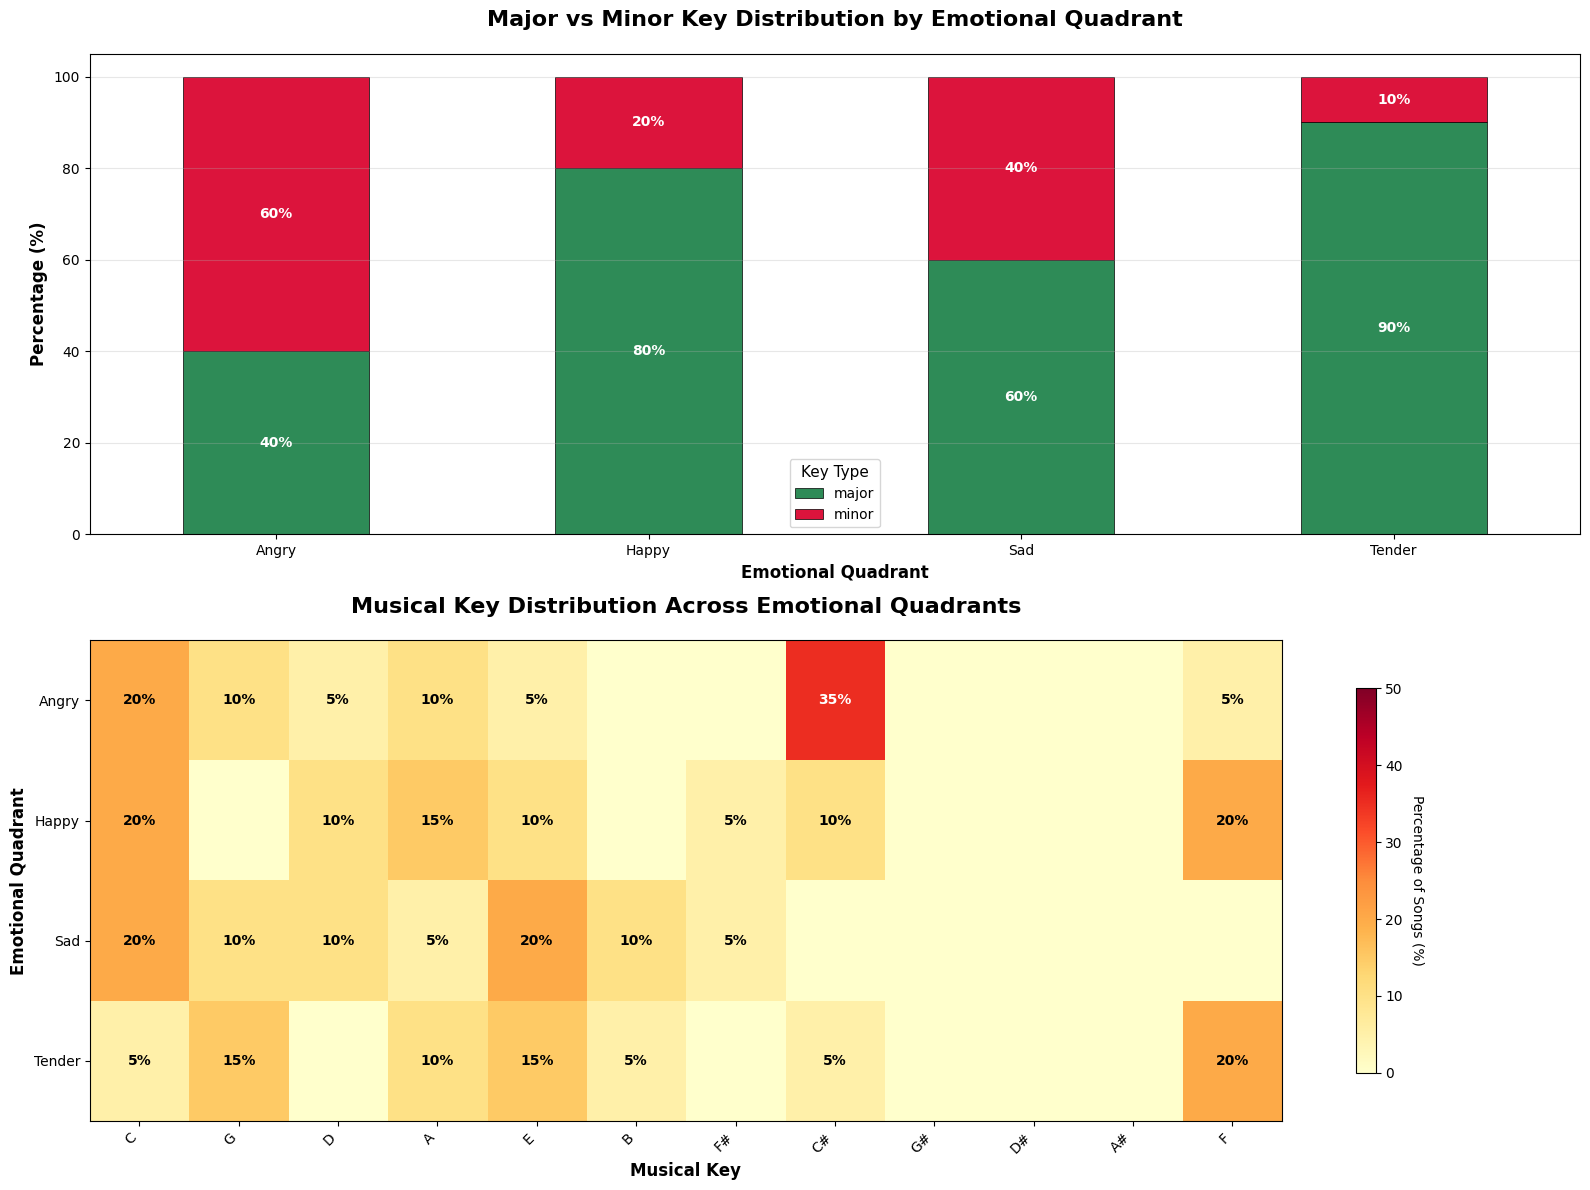

Creating Circle of Fifths visualization...


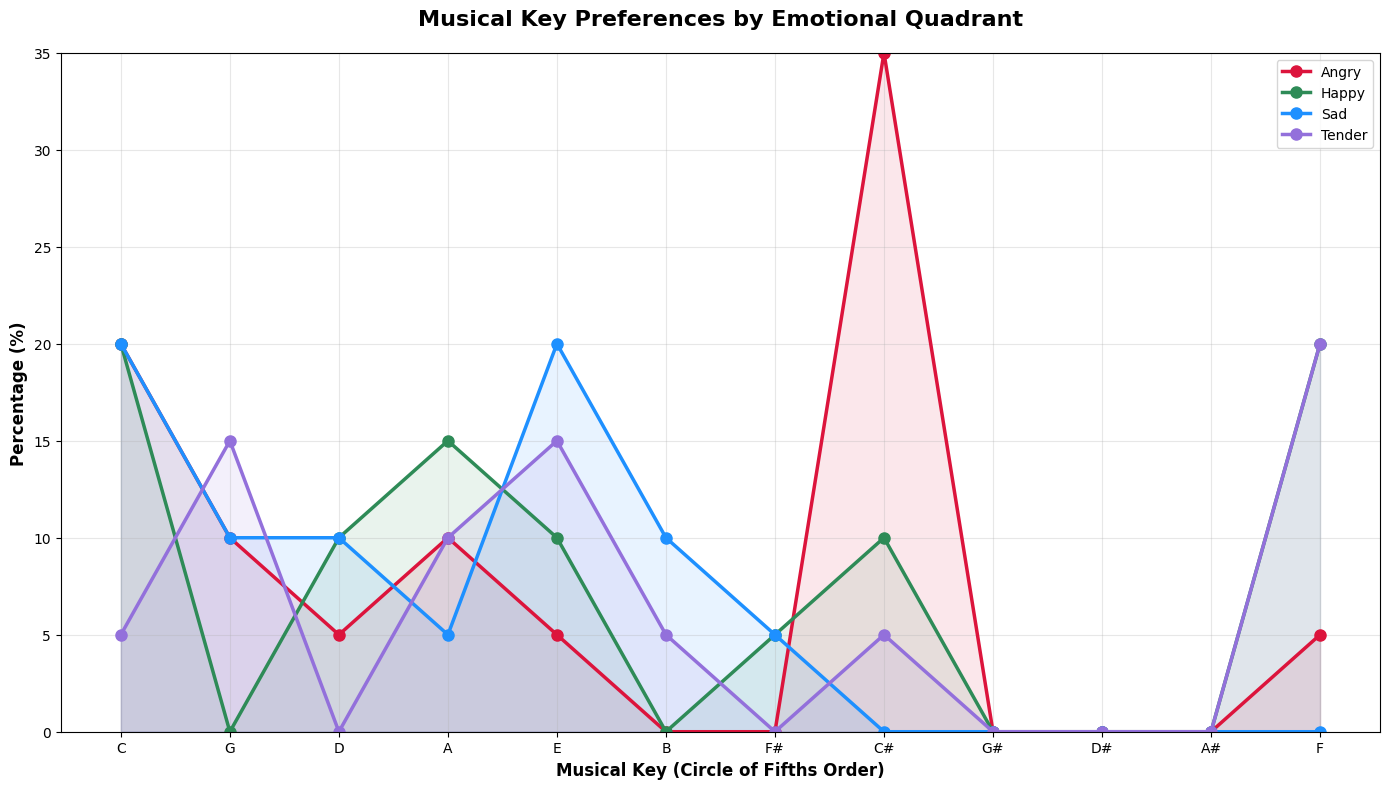


STATISTICAL SUMMARY OF CATEGORICAL FEATURES

1. MAJOR/MINOR DISTRIBUTION (tonal.key_krumhansl.scale):
--------------------------------------------------
 Happy:  80.0% Major,  20.0% Minor
 Angry:  40.0% Major,  60.0% Minor
   Sad:  60.0% Major,  40.0% Minor
Tender:  90.0% Major,  10.0% Minor

Chi-squared test: χ²=13.447, p=0.0038
→ SIGNIFICANT association between emotion and major/minor mode!

2. TOP MUSICAL KEYS BY QUADRANT:
--------------------------------------------------
 Happy: C (20.0%), F (20.0%), A (15.0%)
 Angry: C# (35.0%), C (20.0%), G (10.0%)
   Sad: C (20.0%), E (20.0%), D (10.0%)
Tender: F (20.0%), E (15.0%), G (15.0%)

Chi-squared test: χ²=38.096, p=0.2486
→ No significant association between emotion and specific keys


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from textwrap import wrap

def plot_enhanced_categorical_features(balanced_df):
    """Create enhanced visualizations for categorical features"""

    # Set up the plotting style
    plt.style.use('default')
    sns.set_palette("husl")

    # Create figure with subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12))

    # 1. Enhanced tonal.key_krumhansl.scale plot
    print("Creating enhanced visualizations for categorical features...")

    # Prepare data for scale plot
    scale_data = []
    for quadrant in ['Q1', 'Q2', 'Q3', 'Q4']:
        quadrant_name = {'Q1': 'Happy', 'Q2': 'Angry', 'Q3': 'Sad', 'Q4': 'Tender'}[quadrant]
        scale_counts = balanced_df[balanced_df['Quadrant'] == quadrant]['tonal.key_krumhansl.scale'].value_counts()
        for scale, count in scale_counts.items():
            scale_data.append({
                'Quadrant': quadrant_name,
                'Scale': scale,
                'Count': count,
                'Percentage': (count / len(balanced_df[balanced_df['Quadrant'] == quadrant])) * 100
            })

    scale_df = pd.DataFrame(scale_data)

    # Plot 1: Major/Minor Distribution by Emotional Quadrant
    colors_scale = {'major': '#2E8B57', 'minor': '#DC143C'}  # Green for major, Red for minor

    # Create stacked bar plot with percentages
    pivot_scale = scale_df.pivot_table(index='Quadrant', columns='Scale', values='Percentage', aggfunc='sum').fillna(0)

    bars = pivot_scale.plot(kind='bar', stacked=True, ax=ax1, color=[colors_scale[col] for col in pivot_scale.columns],
                           edgecolor='black', linewidth=0.5)

    # Add percentage labels on bars
    for container in bars.containers:
        ax1.bar_label(container, labels=[f'{v:.0f}%' if v > 5 else '' for v in container.datavalues],
                     label_type='center', fontsize=10, fontweight='bold', color='white')

    ax1.set_title('Major vs Minor Key Distribution by Emotional Quadrant', fontsize=16, fontweight='bold', pad=20)
    ax1.set_xlabel('Emotional Quadrant', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Percentage (%)', fontsize=12, fontweight='bold')
    ax1.legend(title='Key Type', title_fontsize=11, fontsize=10)
    ax1.grid(axis='y', alpha=0.3)
    ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)



    # 2. Enhanced tonal.chords_key plot (Musical Keys Heatmap)
    print("Creating musical keys heatmap...")

    # Prepare chord key data
    chord_data = []
    all_keys = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']

    for quadrant in ['Q1', 'Q2', 'Q3', 'Q4']:
        quadrant_name = {'Q1': 'Happy', 'Q2': 'Angry', 'Q3': 'Sad', 'Q4': 'Tender'}[quadrant]
        key_counts = balanced_df[balanced_df['Quadrant'] == quadrant]['tonal.chords_key'].value_counts()
        total_songs = len(balanced_df[balanced_df['Quadrant'] == quadrant])

        for key in all_keys:
            count = key_counts.get(key, 0)
            chord_data.append({
                'Quadrant': quadrant_name,
                'Key': key,
                'Count': count,
                'Percentage': (count / total_songs) * 100 if total_songs > 0 else 0
            })

    chord_df = pd.DataFrame(chord_data)

    # Create pivot table for heatmap
    heatmap_data = chord_df.pivot_table(index='Quadrant', columns='Key', values='Percentage', aggfunc='sum').fillna(0)

    # Reorder columns to follow circle of fifths for better visualization
    circle_of_fifths_order = ['C', 'G', 'D', 'A', 'E', 'B', 'F#', 'C#', 'G#', 'D#', 'A#', 'F']
    # Use available keys in our data
    available_keys = [key for key in circle_of_fifths_order if key in heatmap_data.columns]
    heatmap_data = heatmap_data[available_keys]

    # Create heatmap
    im = ax2.imshow(heatmap_data.values, cmap='YlOrRd', aspect='auto', vmin=0, vmax=50)

    # Set ticks and labels
    ax2.set_xticks(range(len(available_keys)))
    ax2.set_xticklabels(available_keys, rotation=45, ha='right')
    ax2.set_yticks(range(len(heatmap_data.index)))
    ax2.set_yticklabels(heatmap_data.index)

    # Add text annotations in heatmap cells
    for i in range(len(heatmap_data.index)):
        for j in range(len(available_keys)):
            value = heatmap_data.iloc[i, j]
            if value > 0:
                text_color = 'white' if value > 25 else 'black'
                ax2.text(j, i, f'{value:.0f}%', ha='center', va='center',
                        color=text_color, fontweight='bold', fontsize=10)

    ax2.set_title('Musical Key Distribution Across Emotional Quadrants', fontsize=16, fontweight='bold', pad=20)
    ax2.set_xlabel('Musical Key', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Emotional Quadrant', fontsize=12, fontweight='bold')

    # Add colorbar
    cbar = plt.colorbar(im, ax=ax2, shrink=0.8)
    cbar.set_label('Percentage of Songs (%)', rotation=270, labelpad=15)

    plt.tight_layout()
    plt.show()

    # 3. Fixed Circle of Fifths Visualization using regular plot
    print("Creating Circle of Fifths visualization...")

    fig3, ax3 = plt.subplots(1, 1, figsize=(14, 8))

    # Create a regular line plot for circle of fifths (simplified)
    angles = np.linspace(0, len(available_keys)-1, len(available_keys))

    # Plot each quadrant as a separate line
    quadrant_colors = {'Happy': '#2E8B57', 'Angry': '#DC143C', 'Sad': '#1E90FF', 'Tender': '#9370DB'}

    for quadrant in heatmap_data.index:
        values = heatmap_data.loc[quadrant].values
        ax3.plot(angles, values, 'o-', linewidth=2.5,
                label=quadrant, color=quadrant_colors[quadrant], markersize=8)

        # Fill area under the line
        ax3.fill_between(angles, values, alpha=0.1, color=quadrant_colors[quadrant])

    # Set up the plot
    ax3.set_xticks(angles)
    ax3.set_xticklabels(available_keys)
    ax3.set_ylim(0, 35)
    ax3.set_ylabel('Percentage (%)', fontsize=12, fontweight='bold')
    ax3.set_xlabel('Musical Key (Circle of Fifths Order)', fontsize=12, fontweight='bold')
    ax3.grid(True, alpha=0.3)
    ax3.set_title('Musical Key Preferences by Emotional Quadrant',
                 fontsize=16, fontweight='bold', pad=20)
    ax3.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

    # 4. Statistical Summary Table
    print("\n" + "="*70)
    print("STATISTICAL SUMMARY OF CATEGORICAL FEATURES")
    print("="*70)

    # Major/Minor statistics
    print("\n1. MAJOR/MINOR DISTRIBUTION (tonal.key_krumhansl.scale):")
    print("-" * 50)
    for quadrant in ['Happy', 'Angry', 'Sad', 'Tender']:
        major_pct = scale_df[(scale_df['Quadrant'] == quadrant) & (scale_df['Scale'] == 'major')]['Percentage'].values[0]
        minor_pct = scale_df[(scale_df['Quadrant'] == quadrant) & (scale_df['Scale'] == 'minor')]['Percentage'].values[0]
        print(f"{quadrant:>6}: {major_pct:5.1f}% Major, {minor_pct:5.1f}% Minor")

    print(f"\nChi-squared test: χ²=13.447, p=0.0038")
    print("→ SIGNIFICANT association between emotion and major/minor mode!")

    # Key preferences
    print("\n2. TOP MUSICAL KEYS BY QUADRANT:")
    print("-" * 50)
    for quadrant in ['Happy', 'Angry', 'Sad', 'Tender']:
        quadrant_data = chord_df[chord_df['Quadrant'] == quadrant]
        top_keys = quadrant_data.nlargest(3, 'Percentage')[['Key', 'Percentage']]
        key_list = ", ".join([f"{row['Key']} ({row['Percentage']:.1f}%)" for _, row in top_keys.iterrows()])
        print(f"{quadrant:>6}: {key_list}")

    print(f"\nChi-squared test: χ²=38.096, p=0.2486")
    print("→ No significant association between emotion and specific keys")

# Run the enhanced plotting function
plot_enhanced_categorical_features(balanced_df)

# Additional: Create a compact summary plot
def create_compact_summary(balanced_df):
    """Create a compact summary plot of both categorical features"""

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

    # Color schemes
    emotion_colors = {'Happy': '#2E8B57', 'Angry': '#DC143C', 'Sad': '#1E90FF', 'Tender': '#9370DB'}
    scale_colors = {'major': '#FFD700', 'minor': '#4B0082'}  # Gold for major, Indigo for minor

    # Plot 1: Major/Minor distribution as grouped bar chart
    scale_summary = []
    for quadrant in ['Happy', 'Angry', 'Sad', 'Tender']:
        scale_counts = balanced_df[balanced_df['Quadrant'] == quadrant]['tonal.key_krumhansl.scale'].value_counts()
        total = scale_counts.sum()
        for scale in ['major', 'minor']:
            count = scale_counts.get(scale, 0)
            scale_summary.append({
                'Quadrant': quadrant,
                'Scale': scale,
                'Percentage': (count / total) * 100
            })

    scale_summary_df = pd.DataFrame(scale_summary)

    # Create grouped bar plot
    x = np.arange(len(['Happy', 'Angry', 'Sad', 'Tender']))
    width = 0.35

    major_data = scale_summary_df[scale_summary_df['Scale'] == 'major']['Percentage']
    minor_data = scale_summary_df[scale_summary_df['Scale'] == 'minor']['Percentage']

    bars1 = ax1.bar(x - width/2, major_data, width, label='Major', color=scale_colors['major'], edgecolor='black')
    bars2 = ax1.bar(x + width/2, minor_data, width, label='Minor', color=scale_colors['minor'], edgecolor='black')

    # Add value labels on bars
    for bar in bars1:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{height:.0f}%', ha='center', va='bottom', fontweight='bold')

    for bar in bars2:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{height:.0f}%', ha='center', va='bottom', fontweight='bold')

    ax1.set_xlabel('Emotional Quadrant', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Percentage (%)', fontsize=12, fontweight='bold')
    ax1.set_title('Major vs Minor Distribution by Emotion', fontsize=14, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(['Happy', 'Angry', 'Sad', 'Tender'])
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3)

    # Plot 2: Key preference as horizontal bar plot (top keys per emotion)
    all_keys = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']
    key_data = []

    for quadrant in ['Happy', 'Angry', 'Sad', 'Tender']:
        key_counts = balanced_df[balanced_df['Quadrant'] == quadrant]['tonal.chords_key'].value_counts()
        total = key_counts.sum()
        for key in all_keys:
            if key in key_counts:
                percentage = (key_counts[key] / total) * 100
                if percentage >= 10:  # Only show keys with at least 10% representation
                    key_data.append({'Quadrant': quadrant, 'Key': key, 'Percentage': percentage})

    key_summary_df = pd.DataFrame(key_data)

    # Create horizontal bar plot
    if not key_summary_df.empty:
        # Group by quadrant and get top keys
        top_keys_by_emotion = []
        for quadrant in ['Happy', 'Angry', 'Sad', 'Tender']:
            quadrant_data = key_summary_df[key_summary_df['Quadrant'] == quadrant]
            top_3 = quadrant_data.nlargest(3, 'Percentage')
            for _, row in top_3.iterrows():
                top_keys_by_emotion.append({
                    'Quadrant': row['Quadrant'],
                    'Key': row['Key'],
                    'Percentage': row['Percentage']
                })

        top_keys_df = pd.DataFrame(top_keys_by_emotion)

        # Create horizontal bar plot
        y_pos = np.arange(len(top_keys_df))
        colors = [emotion_colors[row['Quadrant']] for _, row in top_keys_df.iterrows()]

        bars = ax2.barh(y_pos, top_keys_df['Percentage'], color=colors, edgecolor='black')

        # Add value labels
        for i, bar in enumerate(bars):
            width = bar.get_width()
            ax2.text(width + 1, bar.get_y() + bar.get_height()/2,
                    f'{width:.1f}%', ha='left', va='center', fontweight='bold')

        ax2.set_yticks(y_pos)
        # Create labels with emotion and key
        y_labels = [f"{row['Quadrant']} - {row['Key']}" for _, row in top_keys_df.iterrows()]
        ax2.set_yticklabels(y_labels)
        ax2.set_xlabel('Percentage (%)', fontsize=12, fontweight='bold')
        ax2.set_title('Top Musical Keys by Emotional Quadrant\n(Keys with ≥10% representation)',
                     fontsize=14, fontweight='bold')
        ax2.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()

